# Customer Churn Prediction

## Notebook workflow

1. Setup and extract
2. Raw data exploration
3. Data-quality validation
4. Transformations and early data split
5. ETL validation and decisions
6. Development-only exploration
7. Development-only charts
8. Analysis and modeling design
9. Training-only churn-driver analysis
10. Training-only treatment, feature, and timing-risk tests
11. Training-CV model comparison
12. Final holdout evaluation, operations, fairness, and leakage audit
13. Post-selection model explanation
14. Customer prioritization
15. Campaign economics and randomized intervention pilot
16. Win-back and campaign measurement
17. Interpretation and limits

## 1. Setup and extract

### 1.1 Imports and constants

In [2]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

DATA_FILE = "credit-card_customers.xlsx"
SHEET_NAME = "List"
DERIVED_VALUE_TOLERANCE = 0.01
UTILIZATION_TOLERANCE = 0.0011
from scipy.stats import chi2_contingency, norm, ttest_ind
from sklearn.base import clone
from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    PrecisionRecallDisplay, RocCurveDisplay, average_precision_score,
    accuracy_score, brier_score_loss, confusion_matrix, f1_score, log_loss,
    precision_score, recall_score, roc_auc_score,
)
from sklearn.model_selection import (
    StratifiedKFold, cross_val_predict, cross_validate, train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RANDOM_STATE = 42
TEST_SIZE = 0.20
CAMPAIGN_CAPACITY = 0.10


### 1.2 Load the source workbook

In [3]:
excel_file = pd.ExcelFile("credit-card_customers.xlsx")
assert SHEET_NAME in excel_file.sheet_names, (
    f"Expected sheet '{SHEET_NAME}' but found {excel_file.sheet_names}"
)

raw = pd.read_excel(
    "credit-card_customers.xlsx",
    sheet_name=SHEET_NAME,
    dtype={"Customer_Number": "string"},
    na_values=["N/A"],
)
raw_snapshot = raw.copy(deep=True)

print(f"Sheets: {excel_file.sheet_names}")
print(f"Raw shape: {raw.shape[0]:,} rows x {raw.shape[1]:,} columns")
display(raw.head())

Sheets: ['List']
Raw shape: 12,126 rows x 22 columns


,Customer_Number,Attrition_Flag,Age,Date_of_birth,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,...,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,3708092208,Existing Customer,45,1979-06-09,F,3,High School,Married,Less than $40K,Blue,...,3,3,3544.0,1661,1883.0,0.831,15149,111,0.734,0.469
1,3708093408,Attrited Customer,58,1966-05-28,M,0,Unknown,Single,$40K - $60K,Blue,...,1,3,3421.0,2517,904.0,0.992,992,21,0.400,0.736
2,3708094683,Attrited Customer,46,1978-06-29,M,3,Doctorate,Divorced,$80K - $120K,Blue,...,3,3,8258.0,1771,6487.0,0.000,1447,23,0.000,0.214
3,3708095583,Existing Customer,34,1990-06-23,F,2,Uneducated,Single,Less than $40K,Blue,...,2,2,1438.3,0,1438.3,0.827,3940,82,0.952,0.000
4,3708097083,Existing Customer,49,1975-03-12,F,2,Uneducated,Married,Unknown,Blue,...,5,2,3128.0,749,2379.0,0.598,4369,59,0.735,0.239


## 2. Raw data exploration

### 2.1 Schema and completeness

In [4]:
EXPECTED_COLUMNS = [
    "Customer_Number", "Attrition_Flag", "Age", "Date_of_birth", "Gender",
    "Dependent_count", "Education_Level", "Marital_Status", "Income_Category",
    "Card_Category", "Months_on_book", "Total_Relationship_Count",
    "Months_Inactive_12_mon", "Contacts_Count_12_mon", "Credit_Limit",
    "Total_Revolving_Bal", "Avg_Open_To_Buy", "Total_Amt_Chng_Q4_Q1",
    "Total_Trans_Amt", "Total_Trans_Ct", "Total_Ct_Chng_Q4_Q1",
    "Avg_Utilization_Ratio",
]

schema_profile = pd.DataFrame({
    "dtype": raw.dtypes.astype(str),
    "non_null": raw.notna().sum(),
    "missing": raw.isna().sum(),
    "unique_including_missing": raw.nunique(dropna=False),
}).sort_index()
display(schema_profile)

,dtype,non_null,missing,unique_including_missing
Age,int64,12126,0,70
Attrition_Flag,str,12026,100,4
Avg_Open_To_Buy,float64,12126,0,6813
Avg_Utilization_Ratio,float64,12126,0,964
Card_Category,str,11924,202,5
Contacts_Count_12_mon,int64,12126,0,7
Credit_Limit,float64,12126,0,6206
Customer_Number,string,12126,0,11725
Date_of_birth,datetime64[us],12126,0,5741
Dependent_count,int64,12126,0,6


### 2.2 Missing values

In [5]:
CATEGORICAL_COLUMNS = [
    "Attrition_Flag", "Gender", "Education_Level",
    "Marital_Status", "Income_Category", "Card_Category",
]

missing_profile = pd.DataFrame({
    "missing_count": raw.isna().sum(),
    "missing_pct": raw.isna().mean(),
}).query("missing_count > 0").sort_values("missing_count", ascending=False)



### 2.3 Source `Unknown` categories

In [6]:
unknown_profile = pd.DataFrame({
    "unknown_count": {
        column: raw[column].astype("string").str.strip().str.casefold().eq("unknown").sum()
        for column in CATEGORICAL_COLUMNS
    }
})
unknown_profile["unknown_pct"] = unknown_profile["unknown_count"] / len(raw)
unknown_profile = unknown_profile.query("unknown_count > 0").sort_values("unknown_count", ascending=False)

display(missing_profile.assign(missing_pct=missing_profile["missing_pct"].map(lambda x: f"{x:.2%}")))
display(unknown_profile.assign(unknown_pct=unknown_profile["unknown_pct"].map(lambda x: f"{x:.2%}")))

,missing_count,missing_pct
Card_Category,202,1.67%
Gender,200,1.65%
Education_Level,200,1.65%
Attrition_Flag,100,0.82%


,unknown_count,unknown_pct
Education_Level,1747,14.41%
Income_Category,1337,11.03%
Marital_Status,888,7.32%
Attrition_Flag,100,0.82%


### 2.4 Duplicates and repeated IDs

In [7]:
exact_duplicate_mask = raw.duplicated(keep=False)
duplicate_id_mask = raw.duplicated(subset=["Customer_Number"], keep=False)
duplicate_surplus = int(raw.duplicated().sum())
duplicate_customer_ids = int(raw.loc[duplicate_id_mask, "Customer_Number"].nunique())

duplicate_groups = (
    raw.loc[duplicate_id_mask]
       .groupby("Customer_Number", dropna=False)
       .size()
       .rename("row_count")
       .sort_values(ascending=False)
)

print(f"Rows participating in an exact-duplicate pair/group: {exact_duplicate_mask.sum():,}")
print(f"Surplus exact duplicate rows to remove: {duplicate_surplus:,}")
print(f"Customer numbers appearing more than once: {duplicate_customer_ids:,}")
display(duplicate_groups.head(10).to_frame())

Rows participating in an exact-duplicate pair/group: 802
Surplus exact duplicate rows to remove: 401
Customer numbers appearing more than once: 401


,row_count
Customer_Number,
3708164958,2
3708222783,2
3708313233,2
3708352083,2
3708394158,2
3708400758,2
3708409983,2
3708460158,2
3708604008,2


## 3. Data-quality validation

### 3.1 Remove exact duplicates

In [8]:
deduped = raw.drop_duplicates().copy()
for column in CATEGORICAL_COLUMNS:
    deduped[column] = deduped[column].astype("string").str.strip()



### 3.2 Valid category values

In [9]:
ALLOWED_CATEGORIES = {
    "Attrition_Flag": {"Existing Customer", "Attrited Customer", "Unknown"},
    "Gender": {"F", "M"},
    "Education_Level": {"Uneducated", "High School", "College", "Graduate",
                          "Post-Graduate", "Doctorate", "Unknown"},
    "Marital_Status": {"Single", "Married", "Divorced", "Unknown"},
    "Income_Category": {"Less than $40K", "$40K - $60K", "$60K - $80K",
                        "$80K - $120K", "$120K +", "Unknown"},
    "Card_Category": {"Blue", "Silver", "Gold", "Platinum"},
}



### 3.3 Validate the churn target

In [10]:
dq = pd.DataFrame(index=deduped.index)
dq["invalid_target"] = deduped["Attrition_Flag"].isna() | ~deduped["Attrition_Flag"].isin(
    ["Existing Customer", "Attrited Customer"]
)


### 3.4 Validate reported age

In [11]:
dq["age_out_of_range"] = deduped["Age"].notna() & ~deduped["Age"].between(18, 100)


### Age vs. date of birth

In [12]:
def age_reference_interval(date_of_birth, reported_age):
    """Half-open [start, end) range of reference dates consistent with
    reported_age == floor_years(date_of_birth, reference_date)."""
    if pd.isna(date_of_birth) or pd.isna(reported_age):
        return None
    dob = pd.Timestamp(date_of_birth).date()
    reported_age = int(reported_age)
    try:
        start = dob.replace(year=dob.year + reported_age)
    except ValueError:
        start = dob.replace(year=dob.year + reported_age, day=28)
    try:
        end = dob.replace(year=dob.year + reported_age + 1)
    except ValueError:
        end = dob.replace(year=dob.year + reported_age + 1, day=28)
    return start, end


plausible_age_index = deduped.index[~dq["age_out_of_range"]]
age_reference_intervals = {
    index: age_reference_interval(deduped.at[index, "Date_of_birth"], deduped.at[index, "Age"])
    for index in plausible_age_index
}
age_reference_intervals = {
    index: interval for index, interval in age_reference_intervals.items() if interval is not None
}


raw_events = [
    (bound, delta)
    for interval in age_reference_intervals.values()
    for bound, delta in ((interval[0], 1), (interval[1], -1))
]
sorted_events = sorted(raw_events, key=lambda event: (event[0], -event[1]))

running_count = 0
best_agreement = 0
for _, delta in sorted_events:
    running_count += delta
    best_agreement = max(best_agreement, running_count)

best_windows = []
running_count = 0
window_start = None
for date, delta in sorted_events:
    previous_count = running_count
    running_count += delta
    if running_count == best_agreement and previous_count != best_agreement:
        window_start = date
    if previous_count == best_agreement and running_count != best_agreement:
        best_windows.append((window_start, date))

AGE_DOB_CHECKED_ROWS = len(age_reference_intervals)
AGE_DOB_BEST_AGREEMENT = best_agreement
AGE_DOB_INFERRED_WINDOW = best_windows[0] if len(best_windows) == 1 else None

print(f"Plausible-age records checked: {AGE_DOB_CHECKED_ROWS:,}")
print(
    "Records consistent with the single best-supported reference-date window: "
    f"{AGE_DOB_BEST_AGREEMENT:,} ({AGE_DOB_BEST_AGREEMENT / AGE_DOB_CHECKED_ROWS:.1%})"
)
if AGE_DOB_INFERRED_WINDOW:
    print(
        "Inferred window - an internal inference, not a confirmed source-system field: "
        f"{AGE_DOB_INFERRED_WINDOW[0]} to {AGE_DOB_INFERRED_WINDOW[1]} (exclusive)"
    )
else:
    print(f"No single unambiguous window; {len(best_windows)} tied windows found: {best_windows}")

Plausible-age records checked: 11,329
Records consistent with the single best-supported reference-date window: 11,129 (98.2%)
Inferred window - an internal inference, not a confirmed source-system field: 2024-08-31 to 2025-01-01 (exclusive)


In [13]:
dq["age_dob_disagreement"] = False
if AGE_DOB_INFERRED_WINDOW is not None:
    window_start, window_end = AGE_DOB_INFERRED_WINDOW
    disagreement_index = [
        index
        for index, (start, end) in age_reference_intervals.items()
        if not (start < window_end and end > window_start)
    ]
    dq.loc[disagreement_index, "age_dob_disagreement"] = True

print(
    "Plausible-age records disagreeing with the inferred window "
    "(previously undetected by the 18-100 range check alone): "
    f"{int(dq['age_dob_disagreement'].sum()):,}"
)
print("Diagnostic only: Age_clean and DOB exclusion from modeling are unchanged by this check.")

Plausible-age records disagreeing with the inferred window (previously undetected by the 18-100 range check alone): 200
Diagnostic only: Age_clean and DOB exclusion from modeling are unchanged by this check.


### Root cause: age or DOB?

In [14]:
if AGE_DOB_INFERRED_WINDOW is not None:
    dob_reference_date = AGE_DOB_INFERRED_WINDOW[0]
    implied_age_from_dob = deduped["Date_of_birth"].apply(
        lambda dob: dob_reference_date.year - dob.year
        - ((dob_reference_date.month, dob_reference_date.day) < (dob.month, dob.day))
    )
    dob_implausible = ~implied_age_from_dob.between(18, 100)

    overlap_with_flag = int((dob_implausible & dq["age_out_of_range"]).sum())
    print(f"Records where Date_of_birth alone implies an age outside 18-100: {int(dob_implausible.sum()):,}")
    print(
        f"Overlap with the existing age_out_of_range flag: {overlap_with_flag:,}/"
        f"{int(dq['age_out_of_range'].sum()):,} "
        f"({overlap_with_flag / dq['age_out_of_range'].sum():.1%}) - the defect traces to "
        "Date_of_birth, not an independently corrupted Age value."
    )

    recent_dob_cluster = dq["age_out_of_range"] & deduped["Date_of_birth"].dt.year.ge(2000)
    early_dob_cluster = dq["age_out_of_range"] & deduped["Date_of_birth"].dt.year.lt(2000)
    if recent_dob_cluster.any():
        years = deduped.loc[recent_dob_cluster, "Date_of_birth"].dt.year
        print(f"Cluster A - Date_of_birth implies a child ({years.min()}-{years.max()}): {int(recent_dob_cluster.sum()):,} records")
    if early_dob_cluster.any():
        years = deduped.loc[early_dob_cluster, "Date_of_birth"].dt.year
        print(f"Cluster B - Date_of_birth implies a centenarian ({years.min()}-{years.max()}): {int(early_dob_cluster.sum()):,} records")
    print(
        "Both clusters follow a clean, deterministic pattern relative to Date_of_birth rather than a "
        "random spread, consistent with deliberately injected test records rather than organic noise."
    )
else:
    print("No inferred reference window is available; the Date_of_birth root-cause check was skipped.")

Records where Date_of_birth alone implies an age outside 18-100: 396
Overlap with the existing age_out_of_range flag: 396/396 (100.0%) - the defect traces to Date_of_birth, not an independently corrupted Age value.
Cluster A - Date_of_birth implies a child (2009-2014): 200 records
Cluster B - Date_of_birth implies a centenarian (1904-1923): 196 records
Both clusters follow a clean, deterministic pattern relative to Date_of_birth rather than a random spread, consistent with deliberately injected test records rather than organic noise.


### 3.5 Credit-limit relationships

In [15]:
dq["nonpositive_credit_limit"] = deduped["Credit_Limit"].notna() & deduped["Credit_Limit"].le(0)
dq["open_to_buy_mismatch"] = (
    deduped[["Credit_Limit", "Total_Revolving_Bal", "Avg_Open_To_Buy"]].notna().all(axis=1)
    & (
        deduped["Avg_Open_To_Buy"]
        - (deduped["Credit_Limit"] - deduped["Total_Revolving_Bal"])
    ).abs().gt(DERIVED_VALUE_TOLERANCE)
)
expected_utilization = deduped["Total_Revolving_Bal"].div(deduped["Credit_Limit"].replace(0, np.nan))
dq["utilization_mismatch"] = (
    expected_utilization.notna()
    & deduped["Avg_Utilization_Ratio"].sub(expected_utilization).abs().gt(UTILIZATION_TOLERANCE)
)


### Credit-limit floor and ceiling

In [16]:
positive_credit_limit = deduped.loc[deduped["Credit_Limit"].gt(0), "Credit_Limit"]
credit_limit_floor = positive_credit_limit.min()
credit_limit_ceiling = positive_credit_limit.max()
credit_limit_floor_count = int(positive_credit_limit.eq(credit_limit_floor).sum())
credit_limit_ceiling_count = int(positive_credit_limit.eq(credit_limit_ceiling).sum())

print(
    f"Records at the observed Credit_Limit floor ({credit_limit_floor:,.1f}): "
    f"{credit_limit_floor_count:,} ({credit_limit_floor_count / len(deduped):.1%})"
)
print(
    f"Records at the observed Credit_Limit ceiling ({credit_limit_ceiling:,.1f}): "
    f"{credit_limit_ceiling_count:,} ({credit_limit_ceiling_count / len(deduped):.1%})"
)
display(
    deduped.loc[deduped["Credit_Limit"].eq(credit_limit_ceiling)]
    .groupby("Card_Category", observed=True)["Credit_Limit"]
    .size()
    .rename("customers_at_ceiling")
    .to_frame()
)

Records at the observed Credit_Limit floor (1,438.3): 581 (5.0%)
Records at the observed Credit_Limit ceiling (34,516.0): 562 (4.8%)


,customers_at_ceiling
Card_Category,
Blue,226
Gold,82
Platinum,15
Silver,235


### 3.6 Validate customer IDs

In [17]:
dq["missing_customer_id"] = deduped["Customer_Number"].isna()
dq["duplicate_customer_id_after_dedup"] = deduped.duplicated("Customer_Number", keep=False)



### 3.7 Missing and `Unknown` categories

In [18]:
for column in ["Gender", "Education_Level", "Card_Category"]:
    dq[f"missing_{column}"] = deduped[column].isna()

for column in ["Education_Level", "Marital_Status", "Income_Category"]:
    dq[f"unknown_{column}"] = deduped[column].eq("Unknown")



### 3.8 Unexpected category values

In [19]:
for column, allowed_values in ALLOWED_CATEGORIES.items():
    dq[f"unexpected_{column}"] = deduped[column].notna() & ~deduped[column].isin(allowed_values)



### 3.9 Summarize record-level issues

In [20]:
dq["issue_count"] = dq.sum(axis=1).astype(int)
dq["has_any_issue"] = dq["issue_count"].gt(0)

rule_counts = dq.drop(columns=["issue_count", "has_any_issue"]).sum().sort_values(ascending=False)
display(rule_counts.rename("affected_records_after_dedup").to_frame())
print(f"Rows with at least one validation issue: {dq['has_any_issue'].sum():,} / {len(deduped):,}")

,affected_records_after_dedup
unknown_Education_Level,1691
unknown_Income_Category,1304
unknown_Marital_Status,867
age_out_of_range,396
missing_Card_Category,202
nonpositive_credit_limit,200
invalid_target,200
age_dob_disagreement,200
missing_Gender,200
missing_Education_Level,200


Rows with at least one validation issue: 4,644 / 11,725


### 3.10 Data-quality register

In [21]:
def issue_row(issue, affected_rows, severity, recommended_action):
    return {
        "issue": issue,
        "affected_rows": int(affected_rows),
        "pct_of_relevant_base": affected_rows / len(deduped),
        "severity": severity,
        "recommended_action": recommended_action,
    }



**Build the register**

In [22]:
quality_register = pd.DataFrame([
    issue_row("Surplus exact duplicate records", duplicate_surplus, "High",
              "Remove exact copies before analysis; retain one record per customer."),
    issue_row("Missing target label", deduped["Attrition_Flag"].isna().sum(), "High",
              "Exclude from supervised training; retain separately for possible scoring."),
    issue_row("Unknown target label", deduped["Attrition_Flag"].eq("Unknown").sum(), "High",
              "Treat as an unavailable outcome; exclude from training and retain for later scoring."),
    issue_row("Age outside plausible adult range", dq["age_out_of_range"].sum(), "High",
              "Set Age_clean to missing and retain an invalid-age flag. Root cause traces to Date_of_birth, "
              "not an independently corrupted Age value (see the Date_of_birth root-cause check); DOB is "
              "excluded from reconstruction because no confirmed extract timestamp exists."),
    issue_row("Age disagrees with Date_of_birth under the inferred reference window", dq["age_dob_disagreement"].sum(), "Medium",
              "Retain as a diagnostic flag only; do not alter Age_clean or any modeled feature. Confirm the "
              "extract-as-of date with data governance to resolve these disagreements."),
    issue_row("Non-positive credit limit", dq["nonpositive_credit_limit"].sum(), "High",
              "Reconstruct Credit_Limit_clean as Avg_Open_To_Buy + Total_Revolving_Bal and retain a reconstruction flag."),
    issue_row("Avg open-to-buy formula mismatch", dq["open_to_buy_mismatch"].sum(), "High",
              "Retain open-to-buy and resolve the mismatch through the validated credit-limit reconstruction."),
    *[
        issue_row(f"Missing {column}", deduped[column].isna().sum(), "Medium",
                  "Represent nulls as an explicit Missing category; do not infer the source value.")
        for column in ["Gender", "Education_Level", "Card_Category"]
    ],
    *[
        issue_row(f"Unknown {column}", deduped[column].eq("Unknown").sum(), "Medium",
                  "Preserve Unknown as an explicit category; do not mode-impute or impose an order.")
        for column in ["Education_Level", "Marital_Status", "Income_Category"]
    ],
    issue_row(
        "Credit_Limit floor/ceiling censoring",
        credit_limit_floor_count + credit_limit_ceiling_count,
        "Low",
        f"Document as a source-system floor ({credit_limit_floor:,.1f}) and ceiling "
        f"({credit_limit_ceiling:,.1f}); do not attempt to recover true values beyond the caps; "
        "interpret Credit_Limit as censored, especially for Gold/Platinum tiers.",
    ),
]).sort_values(["severity", "affected_rows"], ascending=[True, False])

display(quality_register.assign(
    pct_of_relevant_base=quality_register["pct_of_relevant_base"].map(lambda x: f"{x:.2%}")
))

,issue,affected_rows,pct_of_relevant_base,severity,recommended_action
0,Surplus exact duplicate records,401,3.42%,High,Remove exact copies before analysis; retain on...
3,Age outside plausible adult range,396,3.38%,High,Set Age_clean to missing and retain an invalid...
5,Non-positive credit limit,200,1.71%,High,Reconstruct Credit_Limit_clean as Avg_Open_To_...
6,Avg open-to-buy formula mismatch,200,1.71%,High,Retain open-to-buy and resolve the mismatch th...
1,Missing target label,100,0.85%,High,Exclude from supervised training; retain separ...
2,Unknown target label,100,0.85%,High,Treat as an unavailable outcome; exclude from ...
13,Credit_Limit floor/ceiling censoring,1143,9.75%,Low,"Document as a source-system floor (1,438.3) an..."
10,Unknown Education_Level,1691,14.42%,Medium,Preserve Unknown as an explicit category; do n...
12,Unknown Income_Category,1304,11.12%,Medium,Preserve Unknown as an explicit category; do n...
11,Unknown Marital_Status,867,7.39%,Medium,Preserve Unknown as an explicit category; do n...


### 3.11 Are issues concentrated in the same records?

In [23]:
OVERLAP_CHECK_COLUMNS = [
    "invalid_target", "nonpositive_credit_limit", "missing_Gender",
    "missing_Education_Level", "missing_Card_Category",
]
overlap_matrix = pd.DataFrame(
    {a: {b: int((dq[a] & dq[b]).sum()) for b in OVERLAP_CHECK_COLUMNS} for a in OVERLAP_CHECK_COLUMNS}
)
display(overlap_matrix)

off_diagonal_overlap = int(sum(
    overlap_matrix.loc[a, b]
    for a in OVERLAP_CHECK_COLUMNS
    for b in OVERLAP_CHECK_COLUMNS
    if a != b
))
print(f"Total off-diagonal overlap across these flags: {off_diagonal_overlap:,} records affected by more than one at once.")
if off_diagonal_overlap == 0:
    print(
        "These issues are fully disjoint: each affects a separate group of records. This rules out a "
        "single corrupted batch or source system spanning multiple fields, and is consistent with each "
        "field defect being introduced independently."
    )

,invalid_target,nonpositive_credit_limit,missing_Gender,missing_Education_Level,missing_Card_Category
invalid_target,200,0,0,0,0
nonpositive_credit_limit,0,200,0,0,0
missing_Gender,0,0,200,0,0
missing_Education_Level,0,0,0,200,0
missing_Card_Category,0,0,0,0,202


Total off-diagonal overlap across these flags: 0 records affected by more than one at once.
These issues are fully disjoint: each affects a separate group of records. This rules out a single corrupted batch or source system spanning multiple fields, and is consistent with each field defect being introduced independently.


## 4. Transformations

### 4.1 Initialize the customer base

In [24]:
customer_base = deduped.copy()
customer_base = customer_base.join(dq.add_prefix("DQ_"))


### 4.2 Create the binary churn target

In [25]:
customer_base["Attrition_Flag_clean"] = customer_base["Attrition_Flag"].where(
    customer_base["Attrition_Flag"].isin(["Existing Customer", "Attrited Customer"])
)
customer_base["Churned"] = customer_base["Attrition_Flag_clean"].map({
    "Existing Customer": 0,
    "Attrited Customer": 1,
}).astype("Int64")



### 4.3 Clean age

In [26]:
customer_base["Age_invalid"] = customer_base["DQ_age_out_of_range"]
customer_base["Age_clean"] = customer_base["Age"].mask(customer_base["Age_invalid"])

### 4.4 Reconstruct credit limits

In [27]:
customer_base["Credit_Limit_reconstructed"] = customer_base["DQ_nonpositive_credit_limit"]
customer_base["Credit_Limit_clean"] = customer_base["Credit_Limit"].copy()
customer_base.loc[customer_base["Credit_Limit_reconstructed"], "Credit_Limit_clean"] = (
    customer_base["Avg_Open_To_Buy"] + customer_base["Total_Revolving_Bal"]
)



### 4.5 Validate reconstructed limits

In [28]:
reconstructed_rows = customer_base["Credit_Limit_reconstructed"]
reconstructed_utilization = customer_base["Total_Revolving_Bal"].div(
    customer_base["Credit_Limit_clean"]
)
customer_base["Credit_reconstruction_valid"] = False
customer_base.loc[reconstructed_rows, "Credit_reconstruction_valid"] = (
    customer_base.loc[reconstructed_rows, "Avg_Open_To_Buy"]
    .sub(
        customer_base.loc[reconstructed_rows, "Credit_Limit_clean"]
        - customer_base.loc[reconstructed_rows, "Total_Revolving_Bal"]
    ).abs().le(DERIVED_VALUE_TOLERANCE)
    & customer_base.loc[reconstructed_rows, "Avg_Utilization_Ratio"]
      .sub(reconstructed_utilization.loc[reconstructed_rows]).abs().le(UTILIZATION_TOLERANCE)
)



### 4.6 Preserve categorical values

In [29]:
PREDICTOR_CATEGORICAL_COLUMNS = [
    "Gender", "Education_Level", "Marital_Status", "Income_Category", "Card_Category"
]
for column in PREDICTOR_CATEGORICAL_COLUMNS:
    clean_column = f"{column}_clean"
    customer_base[clean_column] = customer_base[column].fillna("Missing").astype("category")



### 4.7 Separate labeled and unlabeled customers

In [30]:
modeling_base = customer_base.loc[customer_base["Churned"].notna()].copy()
unlabeled_base = customer_base.loc[customer_base["Churned"].isna()].copy()

print(f"Unique customer base: {len(customer_base):,}")
print(f"Labeled modeling base: {len(modeling_base):,}")
print(f"Unlabeled/unknown outcome base: {len(unlabeled_base):,}")

Unique customer base: 11,725
Labeled modeling base: 11,525
Unlabeled/unknown outcome base: 200


### 4.8 Freeze development and holdout sets

In [31]:
development_base, holdout_base = train_test_split(
    modeling_base,
    test_size=TEST_SIZE,
    stratify=modeling_base["Churned"],
    random_state=RANDOM_STATE,
)
development_base = development_base.copy()
holdout_base = holdout_base.copy()

assert development_base.index.is_unique
assert holdout_base.index.is_unique
assert development_base.index.intersection(holdout_base.index).empty
assert len(development_base) + len(holdout_base) == len(modeling_base)
assert set(development_base.index).union(holdout_base.index) == set(modeling_base.index)

print(f"Development rows: {len(development_base):,}")
print(f"Sealed holdout rows: {len(holdout_base):,}")


Development rows: 9,220
Sealed holdout rows: 2,305


## 5. ETL validation and decisions

### 5.1 Reconcile row counts

In [32]:
reconciliation = pd.DataFrame([
    {"stage": "Raw extract", "rows": len(raw), "removed_from_previous": 0},
    {"stage": "After exact duplicate removal", "rows": len(customer_base),
     "removed_from_previous": len(raw) - len(customer_base)},
    {"stage": "Labeled modeling base", "rows": len(modeling_base),
     "removed_from_previous": len(customer_base) - len(modeling_base)},
])

assert raw.equals(raw_snapshot), "Raw dataframe was unexpectedly modified."
assert customer_base["Customer_Number"].is_unique, "Customer base is not unique by Customer_Number."
assert len(raw) == len(customer_base) + duplicate_surplus
assert len(customer_base) == len(modeling_base) + len(unlabeled_base)
assert modeling_base["Churned"].isin([0, 1]).all()
assert customer_base.loc[customer_base["Credit_Limit_reconstructed"], "Credit_reconstruction_valid"].all()
assert customer_base.loc[customer_base["Credit_Limit_reconstructed"], "Credit_Limit_clean"].gt(0).all()
assert customer_base.loc[customer_base["Age_invalid"], "Age_clean"].isna().all()

display(reconciliation)
print("ETL reconciliation checks passed.")

,stage,rows,removed_from_previous
0,Raw extract,12126,0
1,After exact duplicate removal,11725,401
2,Labeled modeling base,11525,200


ETL reconciliation checks passed.


### 5.2 Decisions carried into modeling

1. **Age:** no observation date, so DOB isn't used to reconstruct it. Mask ages outside 18-100, keep `Age_invalid`, exclude DOB.
2. **Credit limit:** reconstruct non-positive values from `Avg_Open_To_Buy + Total_Revolving_Bal`, validated against utilization.
3. **Targets:** null/`Unknown` outcomes are excluded from training, retained for later scoring.
4. **Categorical predictors:** keep `Unknown`/`Missing` as their own categories, no mode imputation.
5. **Gender:** kept for descriptive analysis, excluded from the model.
6. **Leakage prevention:** imputation and encoding fit only inside the training pipeline.
7. **Evaluation:** ROC-AUC, PR-AUC, recall/precision, calibration, and lift at outreach capacity.
8. **Validation design:** stratified holdout plus CV, since no time-aware split is possible.
9. **Business activation:** churn prediction, win-back prioritization, and a randomized pilot are kept separate.

## 6. Development-only exploration

### 6.1 Development target balance

In [33]:
target_summary = (
    development_base["Attrition_Flag_clean"]
    .value_counts()
    .rename_axis("customer_status")
    .to_frame("customers")
)
target_summary["share"] = target_summary["customers"] / target_summary["customers"].sum()
churn_rate = development_base["Churned"].mean()

display(target_summary.assign(share=target_summary["share"].map(lambda x: f"{x:.2%}")))
print(f"Observed churn rate in labeled, deduplicated data: {churn_rate:.2%}")



,customers,share
customer_status,,
Existing Customer,7680,83.30%
Attrited Customer,1540,16.70%


Observed churn rate in labeled, deduplicated data: 16.70%


### 6.2 Numerical distributions

In [34]:
NUMERIC_FEATURES = [
    "Age_clean", "Dependent_count", "Months_on_book", "Total_Relationship_Count",
    "Months_Inactive_12_mon", "Contacts_Count_12_mon", "Credit_Limit_clean",
    "Total_Revolving_Bal", "Avg_Open_To_Buy", "Total_Amt_Chng_Q4_Q1",
    "Total_Trans_Amt", "Total_Trans_Ct", "Total_Ct_Chng_Q4_Q1",
    "Avg_Utilization_Ratio",
]

numeric_summary = development_base[NUMERIC_FEATURES].describe().T
numeric_summary["missing"] = development_base[NUMERIC_FEATURES].isna().sum()
display(numeric_summary[["count", "missing", "mean", "std", "min", "25%", "50%", "75%", "max"]])



,count,missing,mean,std,min,25%,50%,75%,max
Age_clean,8907.0,313,46.325138,8.044386,26.0,41.000,46.000,52.000,73.000
Dependent_count,9220.0,0,2.349892,1.288734,0.0,1.000,2.000,3.000,5.000
Months_on_book,9220.0,0,35.884599,7.940439,13.0,31.000,36.000,40.000,56.000
Total_Relationship_Count,9220.0,0,3.788720,1.557044,1.0,3.000,4.000,5.000,6.000
Months_Inactive_12_mon,9220.0,0,2.345228,1.011601,0.0,2.000,2.000,3.000,6.000
Contacts_Count_12_mon,9220.0,0,2.445336,1.103075,0.0,2.000,2.000,3.000,6.000
Credit_Limit_clean,9220.0,0,8625.787072,9106.558703,1438.3,2550.000,4525.000,11115.500,34516.000
Total_Revolving_Bal,9220.0,0,1152.687202,818.374535,0.0,198.750,1267.000,1776.250,2517.000
Avg_Open_To_Buy,9220.0,0,7473.099870,9113.000377,3.0,1329.750,3440.000,9916.750,34516.000
Total_Amt_Chng_Q4_Q1,9220.0,0,0.756082,0.219431,0.0,0.626,0.734,0.857,3.397


### 6.3 Medians by customer status

In [35]:
median_by_status = (
    development_base.groupby("Attrition_Flag_clean", observed=True)[NUMERIC_FEATURES]
    .median()
    .T
)
median_by_status["attrited_minus_existing"] = (
    median_by_status.get("Attrited Customer") - median_by_status.get("Existing Customer")
)
display(median_by_status.sort_values("attrited_minus_existing"))

Attrition_Flag_clean,Attrited Customer,Existing Customer,attrited_minus_existing
Total_Trans_Amt,2297.500,4105.000,-1807.500
Total_Revolving_Bal,0.000,1356.000,-1356.000
Credit_Limit_clean,4097.000,4622.000,-525.000
Avg_Open_To_Buy,3418.500,3450.000,-31.500
Total_Trans_Ct,43.000,71.000,-28.000
Total_Relationship_Count,3.000,4.000,-1.000
Avg_Utilization_Ratio,0.000,0.206,-0.206
Total_Ct_Chng_Q4_Q1,0.519,0.722,-0.203
Total_Amt_Chng_Q4_Q1,0.690,0.740,-0.050
Age_clean,46.000,46.000,0.000


### 6.4 Categorical churn rates

In [36]:
def categorical_churn_table(data: pd.DataFrame, column: str) -> pd.DataFrame:
    return (
        data.groupby(column, observed=True, dropna=False)["Churned"]
            .agg(customers="size", churners="sum", churn_rate="mean")
            .reset_index()
            .assign(feature=column)
            .rename(columns={column: "segment"})
            [["feature", "segment", "customers", "churners", "churn_rate"]]
    )



**Combine segment tables**

In [37]:
categorical_tables = pd.concat(
    [categorical_churn_table(development_base, f"{column}_clean") for column in PREDICTOR_CATEGORICAL_COLUMNS],
    ignore_index=True,
)

categorical_display = categorical_tables.sort_values(
    ["feature", "churn_rate"], ascending=[True, False]
).copy()
categorical_display["churn_rate"] = categorical_display["churn_rate"].map(lambda x: f"{x:.2%}")
display(categorical_display)

,feature,segment,customers,churners,churn_rate
24,Card_Category_clean,Platinum,17,4,23.53%
22,Card_Category_clean,Gold,106,21,19.81%
23,Card_Category_clean,Missing,170,29,17.06%
21,Card_Category_clean,Blue,8434,1418,16.81%
25,Card_Category_clean,Silver,493,68,13.79%
4,Education_Level_clean,Doctorate,412,103,25.00%
8,Education_Level_clean,Post-Graduate,483,93,19.25%
7,Education_Level_clean,Missing,159,29,18.24%
10,Education_Level_clean,Unknown,1315,236,17.95%
3,Education_Level_clean,College,899,146,16.24%


### 6.5 ETL handoff summary

In [38]:
etl_handoff = {
    "raw_rows": len(raw),
    "unique_customer_rows": len(customer_base),
    "modeling_rows": len(modeling_base),
    "unlabeled_rows": len(unlabeled_base),
    "churn_rate": float(churn_rate),
    "duplicate_surplus_removed": duplicate_surplus,
    "rows_with_any_validation_issue": int(dq["has_any_issue"].sum()),
}

display(pd.Series(etl_handoff, name="value").to_frame())
print("Stage 1 complete: ETL objects are ready for feature engineering and model design.")

,value
raw_rows,12126.000000
unique_customer_rows,11725.000000
modeling_rows,11525.000000
unlabeled_rows,200.000000
churn_rate,0.167028
duplicate_surplus_removed,401.000000
rows_with_any_validation_issue,4644.000000


Stage 1 complete: ETL objects are ready for feature engineering and model design.


## 7. Development-only charts

### 7.1 Status and data-quality overview

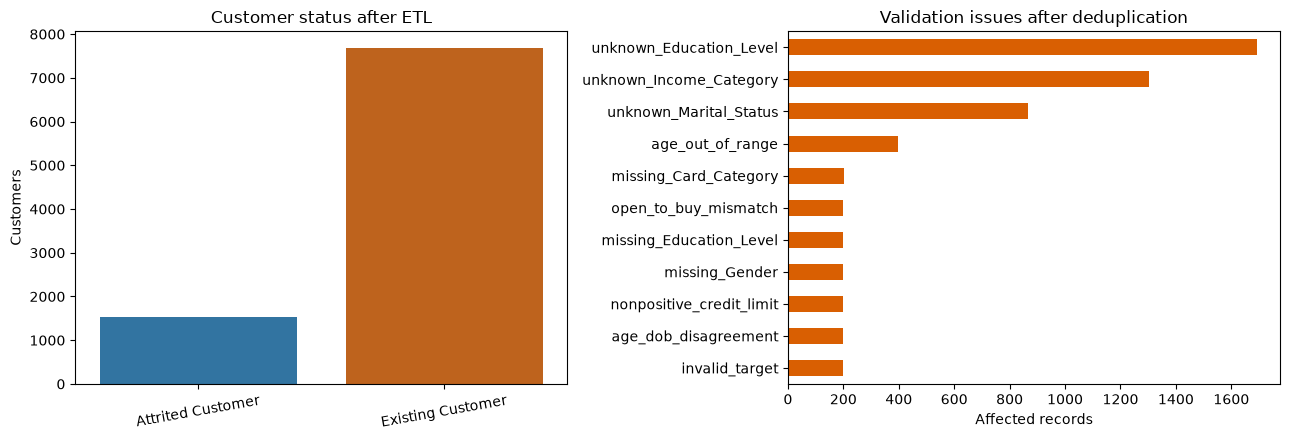

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.countplot(
    data=development_base, x="Attrition_Flag_clean", hue="Attrition_Flag_clean",
    ax=axes[0], palette=["#1f77b4", "#d95f02"], legend=False,
)
axes[0].set(title="Customer status after ETL", xlabel="", ylabel="Customers")
axes[0].tick_params(axis="x", rotation=10)

issue_plot = rule_counts[rule_counts.gt(0)].sort_values()
issue_plot.plot.barh(ax=axes[1], color="#d95f02")
axes[1].set(title="Validation issues after deduplication", xlabel="Affected records", ylabel="")
plt.tight_layout()
plt.show()

### 7.2 Behavioral and financial distributions

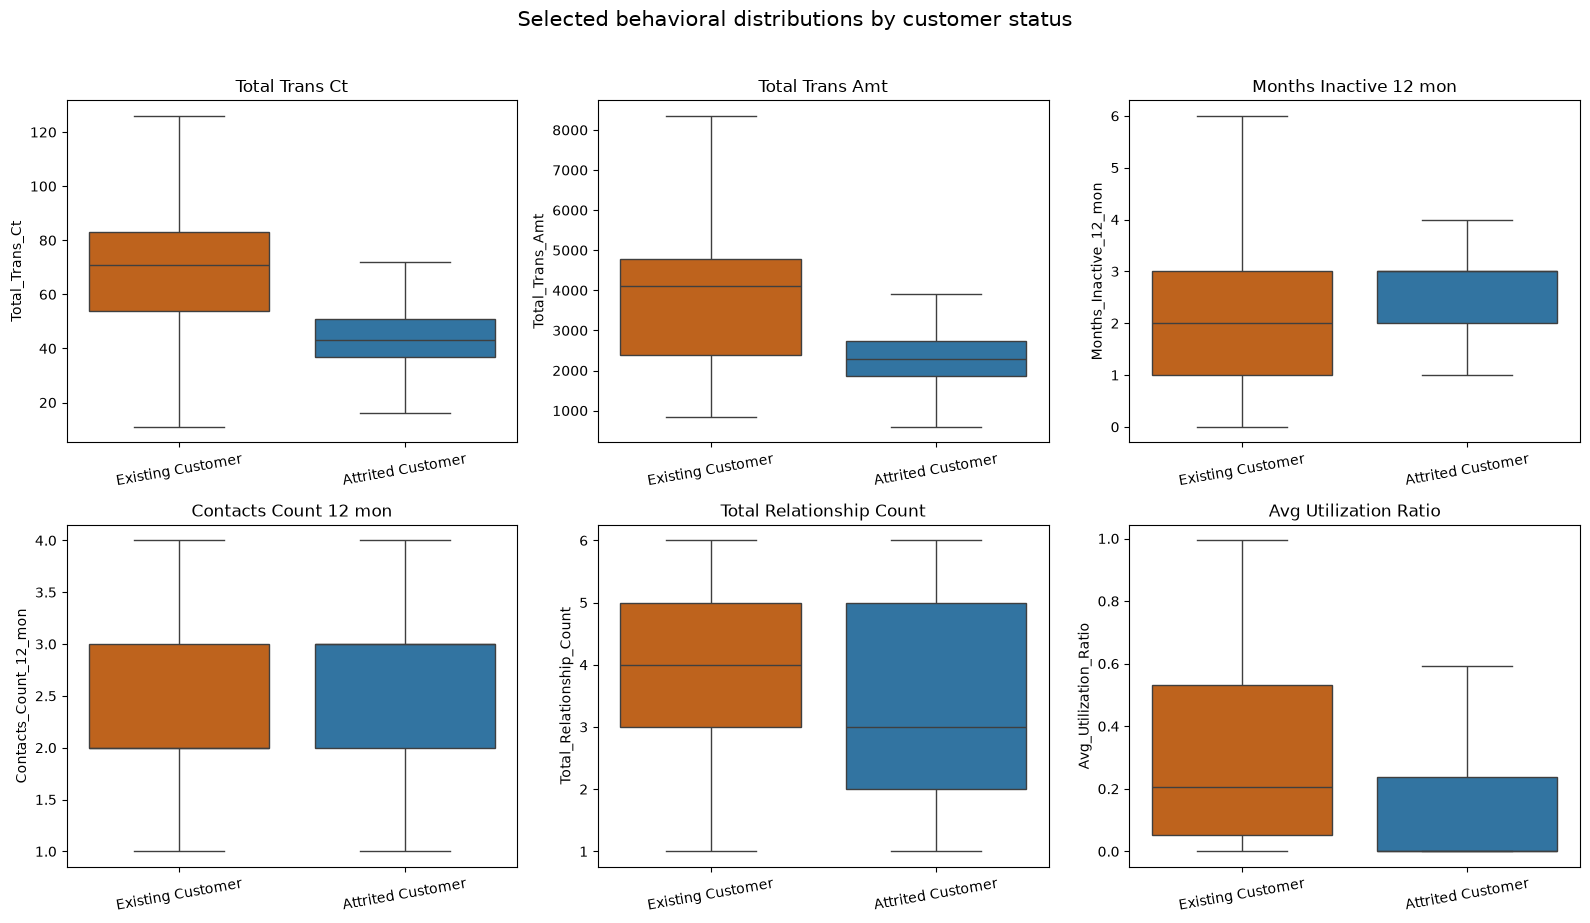

In [40]:
PLOT_FEATURES = [
    "Total_Trans_Ct", "Total_Trans_Amt", "Months_Inactive_12_mon",
    "Contacts_Count_12_mon", "Total_Relationship_Count", "Avg_Utilization_Ratio",
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for feature, axis in zip(PLOT_FEATURES, axes.flat):
    sns.boxplot(
        data=development_base, x="Attrition_Flag_clean", y=feature, hue="Attrition_Flag_clean",
        order=["Existing Customer", "Attrited Customer"],
        showfliers=False, ax=axis, palette=["#1f77b4", "#d95f02"], legend=False,
    )
    axis.set(xlabel="", title=feature.replace("_", " "))
    axis.tick_params(axis="x", rotation=10)
fig.suptitle("Selected behavioral distributions by customer status", y=1.02, fontsize=15)
plt.tight_layout()
plt.show()

## 8. Analysis and modeling design

- **Driver analysis:** association with churn, on the training sample only.
- **Prediction:** compare models, select on training CV, evaluate once on holdout.

### 8.2 Feature domains

In [41]:
FEATURE_GROUPS = {
    "Demographic": [
        "Age_clean", "Gender_clean", "Dependent_count",
        "Education_Level_clean", "Marital_Status_clean",
    ],
    "Financial": [
        "Income_Category_clean", "Card_Category_clean", "Credit_Limit_clean",
        "Total_Revolving_Bal", "Avg_Utilization_Ratio",
        "Total_Amt_Chng_Q4_Q1", "Total_Trans_Amt",
        "Total_Trans_Ct", "Total_Ct_Chng_Q4_Q1",
    ],
    "Behavioral": [
        "Months_on_book", "Total_Relationship_Count",
        "Months_Inactive_12_mon", "Contacts_Count_12_mon",
    ],
}



### 8.3 Final model inputs

In [42]:
MODEL_NUMERIC_FEATURES = [
    "Age_clean", "Dependent_count",
    "Total_Relationship_Count", "Months_Inactive_12_mon",
    "Contacts_Count_12_mon", "Credit_Limit_clean",
    "Total_Revolving_Bal", "Avg_Utilization_Ratio",
    "Total_Amt_Chng_Q4_Q1", "Total_Trans_Amt",
    "Total_Trans_Ct", "Total_Ct_Chng_Q4_Q1",
]
MODEL_CATEGORICAL_FEATURES = [
    "Education_Level_clean", "Marital_Status_clean",
    "Income_Category_clean", "Card_Category_clean",
]
DRIVER_NUMERIC_FEATURES = ["Months_on_book"] + MODEL_NUMERIC_FEATURES
DRIVER_CATEGORICAL_FEATURES = ["Gender_clean"] + MODEL_CATEGORICAL_FEATURES
MODEL_FEATURES = MODEL_NUMERIC_FEATURES + MODEL_CATEGORICAL_FEATURES
DOMAIN_BY_FEATURE = {feature: domain for domain, features in FEATURE_GROUPS.items() for feature in features}

FORBIDDEN_DIRECT_LEAKAGE = {
    "Customer_Number", "Attrition_Flag", "Attrition_Flag_clean",
    "Churned", "Date_of_birth",
}
assert set(MODEL_FEATURES).isdisjoint(FORBIDDEN_DIRECT_LEAKAGE)
assert not set(MODEL_FEATURES) & {"Gender_clean", "Months_on_book", "Avg_Open_To_Buy"}



### 8.4 Feature-timing risk register

In [43]:
HIGH_TIMING_RISK_FEATURES = {
    "Total_Relationship_Count", "Months_Inactive_12_mon", "Contacts_Count_12_mon",
    "Total_Revolving_Bal", "Avg_Utilization_Ratio", "Total_Amt_Chng_Q4_Q1",
    "Total_Trans_Amt", "Total_Trans_Ct", "Total_Ct_Chng_Q4_Q1",
}
SNAPSHOT_DATE_REQUIRED_FEATURES = {
    "Months_on_book", "Credit_Limit_clean", "Income_Category_clean", "Card_Category_clean",
}
REDUCED_RISK_NUMERIC_FEATURES = [
    "Age_clean", "Dependent_count", "Credit_Limit_clean",
]
REDUCED_RISK_CATEGORICAL_FEATURES = [
    "Education_Level_clean", "Marital_Status_clean",
    "Income_Category_clean", "Card_Category_clean",
]
REDUCED_RISK_FEATURES = REDUCED_RISK_NUMERIC_FEATURES + REDUCED_RISK_CATEGORICAL_FEATURES

assert set(HIGH_TIMING_RISK_FEATURES).issubset(MODEL_FEATURES)
assert set(REDUCED_RISK_FEATURES).issubset(MODEL_FEATURES)
assert set(REDUCED_RISK_FEATURES).isdisjoint(HIGH_TIMING_RISK_FEATURES)


**Timing-risk register**

In [44]:
feature_timing_rows = []
for feature in DRIVER_NUMERIC_FEATURES + DRIVER_CATEGORICAL_FEATURES:
    if feature in HIGH_TIMING_RISK_FEATURES:
        timing_status = "High timing risk"
        rationale = "The measurement window could overlap or follow attrition."
    elif feature in SNAPSHOT_DATE_REQUIRED_FEATURES:
        timing_status = "Snapshot date required"
        rationale = "Likely available at scoring, but its as-of date is not documented."
    elif feature == "Gender_clean":
        timing_status = "Sensitive - analysis only"
        rationale = "Excluded from prediction; retained for drivers and fairness monitoring."
    else:
        timing_status = "Lower timing risk"
        rationale = "Relatively stable profile information, subject to source-date confirmation."
    feature_timing_rows.append({
        "feature": feature,
        "domain": DOMAIN_BY_FEATURE[feature],
        "timing_status": timing_status,
        "rationale": rationale,
        "in_primary_model": feature in MODEL_FEATURES,
        "in_reduced_risk_benchmark": feature in REDUCED_RISK_FEATURES,
    })

feature_timing_register = pd.DataFrame(feature_timing_rows)
display(feature_timing_register)


,feature,domain,timing_status,rationale,in_primary_model,in_reduced_risk_benchmark
0,Months_on_book,Behavioral,Snapshot date required,"Likely available at scoring, but its as-of dat...",False,False
1,Age_clean,Demographic,Lower timing risk,"Relatively stable profile information, subject...",True,True
2,Dependent_count,Demographic,Lower timing risk,"Relatively stable profile information, subject...",True,True
3,Total_Relationship_Count,Behavioral,High timing risk,The measurement window could overlap or follow...,True,False
4,Months_Inactive_12_mon,Behavioral,High timing risk,The measurement window could overlap or follow...,True,False
5,Contacts_Count_12_mon,Behavioral,High timing risk,The measurement window could overlap or follow...,True,False
6,Credit_Limit_clean,Financial,Snapshot date required,"Likely available at scoring, but its as-of dat...",True,True
7,Total_Revolving_Bal,Financial,High timing risk,The measurement window could overlap or follow...,True,False
8,Avg_Utilization_Ratio,Financial,High timing risk,The measurement window could overlap or follow...,True,False
9,Total_Amt_Chng_Q4_Q1,Financial,High timing risk,The measurement window could overlap or follow...,True,False


### 8.5 Build the model matrices

In [45]:
X = modeling_base[MODEL_FEATURES].copy()
y = modeling_base["Churned"].astype(int).copy()
X_train = development_base[MODEL_FEATURES].copy()
y_train = development_base["Churned"].astype(int).copy()
X_test = holdout_base[MODEL_FEATURES].copy()
y_test = holdout_base["Churned"].astype(int).copy()

assert X_train.index.equals(y_train.index)
assert X_test.index.equals(y_test.index)
assert X_train.index.intersection(X_test.index).empty
assert set(X_train.index).union(X_test.index) == set(X.index)

split_summary = pd.DataFrame({
    "rows": [len(y_train), len(y_test)],
    "churners": [int(y_train.sum()), int(y_test.sum())],
    "churn_rate": [y_train.mean(), y_test.mean()],
}, index=["Development", "Sealed holdout"])
split_display = split_summary.copy()
split_display["churn_rate"] = split_display["churn_rate"].map(lambda value: f"{value:.2%}")
display(pd.Series({
    domain: sum(feature in MODEL_FEATURES for feature in features)
    for domain, features in FEATURE_GROUPS.items()
}, name="model_feature_count").to_frame())
display(split_display)


,model_feature_count
Demographic,4
Financial,9
Behavioral,3


,rows,churners,churn_rate
Development,9220,1540,16.70%
Sealed holdout,2305,385,16.70%


### 8.6 Holdout policy

## 9. Key drivers of churn

### 9.1 Numerical correlation screen

In [46]:
CORRELATION_REVIEW_THRESHOLD = 0.75
correlation_data = modeling_base.loc[X_train.index, DRIVER_NUMERIC_FEATURES].copy()
correlation_data["Churned"] = y_train
spearman_correlation = correlation_data.corr(method="spearman")



**Correlated numeric pairs**

In [47]:
correlated_pairs = []
numeric_feature_correlation = spearman_correlation.loc[DRIVER_NUMERIC_FEATURES, DRIVER_NUMERIC_FEATURES]
for left_index, left_feature in enumerate(DRIVER_NUMERIC_FEATURES):
    for right_feature in DRIVER_NUMERIC_FEATURES[left_index + 1:]:
        correlation = numeric_feature_correlation.loc[left_feature, right_feature]
        if abs(correlation) >= CORRELATION_REVIEW_THRESHOLD:
            correlated_pairs.append({
                "feature_1": left_feature, "feature_2": right_feature,
                "spearman_correlation": correlation,
            })
high_correlation_pairs = pd.DataFrame(
    correlated_pairs, columns=["feature_1", "feature_2", "spearman_correlation"]
)
if high_correlation_pairs.empty:
    print(f"No numerical feature pairs have |Spearman correlation| >= {CORRELATION_REVIEW_THRESHOLD:.2f}.")
else:
    high_correlation_pairs["absolute_correlation"] = high_correlation_pairs["spearman_correlation"].abs()
    high_correlation_pairs = high_correlation_pairs.sort_values("absolute_correlation", ascending=False)
    display(high_correlation_pairs.drop(columns="absolute_correlation").round(3))



,feature_1,feature_2,spearman_correlation
1,Total_Trans_Amt,Total_Trans_Ct,0.884
0,Months_on_book,Age_clean,0.765


**Correlation with churn**

In [48]:
target_correlations = (
    spearman_correlation["Churned"].drop("Churned").rename("spearman_with_churn").to_frame()
)
target_correlations["absolute_correlation"] = target_correlations["spearman_with_churn"].abs()
display(target_correlations.sort_values("absolute_correlation", ascending=False).round(3))


,spearman_with_churn,absolute_correlation
Total_Trans_Ct,-0.388,0.388
Total_Ct_Chng_Q4_Q1,-0.333,0.333
Total_Revolving_Bal,-0.243,0.243
Avg_Utilization_Ratio,-0.239,0.239
Total_Trans_Amt,-0.238,0.238
Contacts_Count_12_mon,0.178,0.178
Months_Inactive_12_mon,0.177,0.177
Total_Relationship_Count,-0.158,0.158
Total_Amt_Chng_Q4_Q1,-0.114,0.114
Credit_Limit_clean,-0.056,0.056


### 9.2 Correlation heatmap

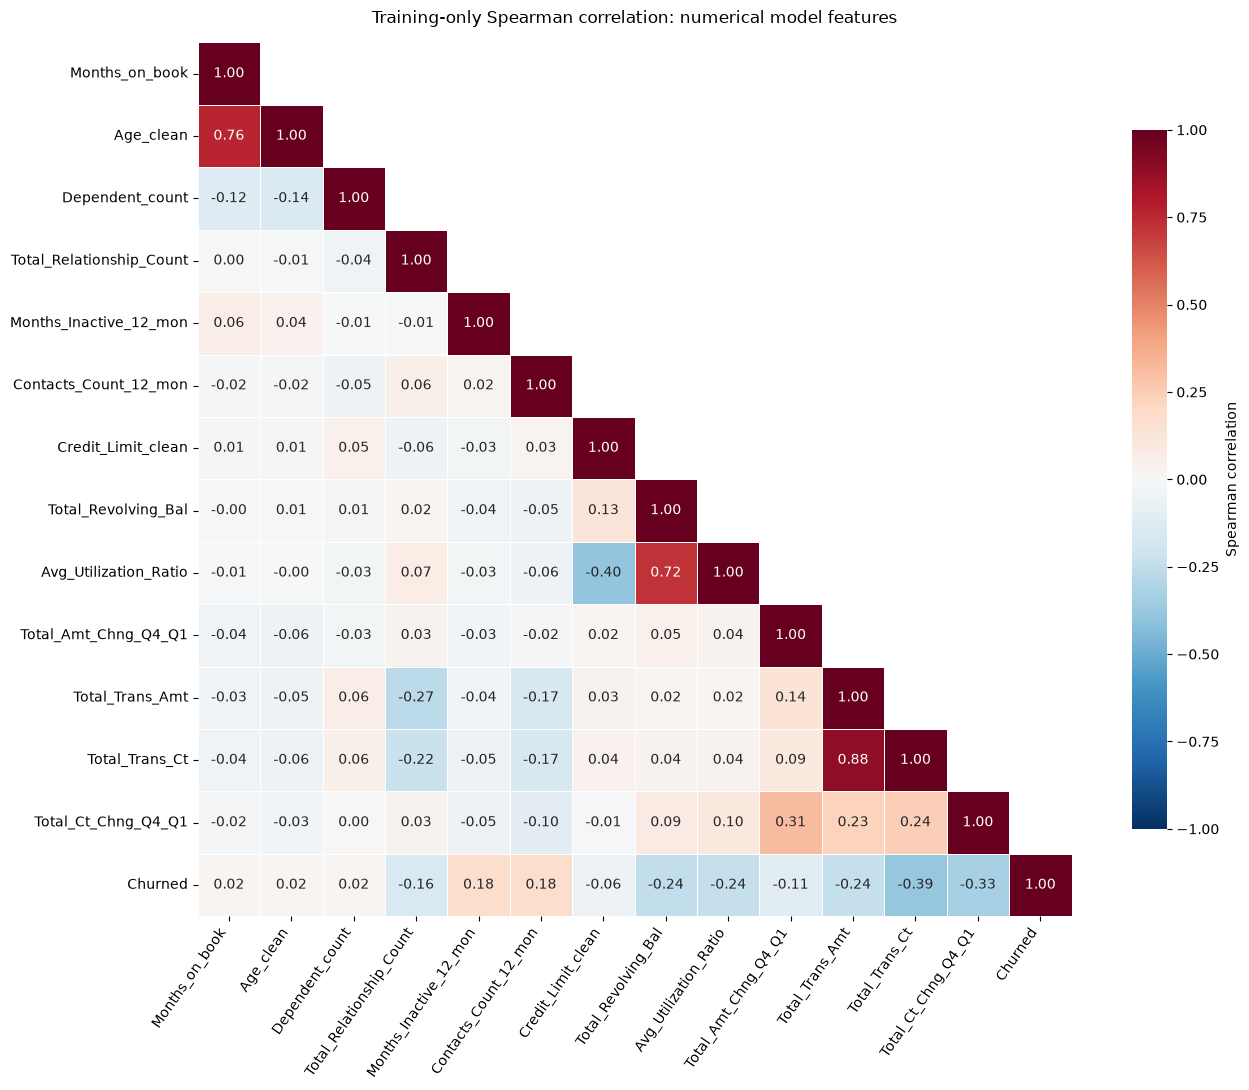

In [49]:
mask = np.triu(np.ones_like(spearman_correlation, dtype=bool), k=1)
plt.figure(figsize=(14, 11))
sns.heatmap(
    spearman_correlation, mask=mask, cmap="RdBu_r", center=0,
    vmin=-1, vmax=1, annot=True, fmt=".2f", square=True,
    linewidths=0.4, cbar_kws={"shrink": 0.8, "label": "Spearman correlation"},
)
plt.title("Training-only Spearman correlation: numerical model features", pad=14)
plt.xticks(rotation=55, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()



### Feature-selection notes

- **Filter:** drop redundant numeric pairs, keep the clearer/earlier-available feature.
- **Embedded:** compare a correlation-pruned model against the full random forest.
- **Wrapper:** RFECV is lower priority here, with only 17 features.

### 9.3 Statistical driver summaries

In [50]:
def benjamini_hochberg(p_values):
    p_values = np.asarray(p_values, dtype=float)
    order = np.argsort(p_values)
    ranked = p_values[order]
    adjusted = ranked * len(ranked) / np.arange(1, len(ranked) + 1)
    adjusted = np.minimum.accumulate(adjusted[::-1])[::-1]
    result = np.empty_like(adjusted)
    result[order] = np.clip(adjusted, 0, 1)
    return result




**Numerical driver stats**

In [51]:
def numeric_driver_summary(data, features, target="Churned"):
    rows = []
    for feature in features:
        existing = data.loc[data[target].eq(0), feature].dropna().astype(float)
        attrited = data.loc[data[target].eq(1), feature].dropna().astype(float)
        pooled_variance = (
            ((len(existing) - 1) * existing.var(ddof=1))
            + ((len(attrited) - 1) * attrited.var(ddof=1))
        ) / (len(existing) + len(attrited) - 2)
        pooled_sd = np.sqrt(pooled_variance)
        _, p_value = ttest_ind(attrited, existing, equal_var=False, nan_policy="omit")
        rows.append({
            "feature": feature,
            "domain": DOMAIN_BY_FEATURE[feature],
            "existing_median": existing.median(),
            "attrited_median": attrited.median(),
            "mean_difference": attrited.mean() - existing.mean(),
            "standardized_mean_difference": (attrited.mean() - existing.mean()) / pooled_sd if pooled_sd else np.nan,
            "missing_pct": data[feature].isna().mean(),
            "p_value": p_value,
        })
    result = pd.DataFrame(rows)
    result["p_value_adj"] = benjamini_hochberg(result["p_value"])
    result["abs_effect"] = result["standardized_mean_difference"].abs()
    return result.sort_values("abs_effect", ascending=False).reset_index(drop=True)




**Confidence intervals**

In [52]:
def wilson_interval(successes, total, z=1.96):
    rate = successes / total
    denominator = 1 + z**2 / total
    centre = (rate + z**2 / (2 * total)) / denominator
    half_width = z * np.sqrt((rate * (1 - rate) + z**2 / (4 * total)) / total) / denominator
    return centre - half_width, centre + half_width




**Categorical driver stats**

In [53]:
def categorical_driver_summary(data, features, target="Churned"):
    feature_rows = []
    segment_rows = []
    for feature in features:
        contingency = pd.crosstab(data[feature], data[target], dropna=False).reindex(columns=[0, 1], fill_value=0)
        chi_square, p_value, _, _ = chi2_contingency(contingency)
        n = contingency.to_numpy().sum()
        denominator = min(contingency.shape[0] - 1, contingency.shape[1] - 1)
        cramers_v = np.sqrt((chi_square / n) / denominator) if denominator > 0 else np.nan
        feature_rows.append({
            "feature": feature,
            "domain": DOMAIN_BY_FEATURE[feature],
            "cramers_v": cramers_v,
            "p_value": p_value,
        })
        for segment, counts in contingency.iterrows():
            customers = int(counts.sum())
            churners = int(counts[1])
            ci_low, ci_high = wilson_interval(churners, customers)
            segment_rows.append({
                "feature": feature, "segment": str(segment),
                "customers": customers, "churners": churners,
                "churn_rate": churners / customers,
                "ci_95_low": ci_low, "ci_95_high": ci_high,
            })
    feature_result = pd.DataFrame(feature_rows)
    feature_result["p_value_adj"] = benjamini_hochberg(feature_result["p_value"])
    return (
        feature_result.sort_values("cramers_v", ascending=False).reset_index(drop=True),
        pd.DataFrame(segment_rows),
    )




**Development-only driver tables**

In [54]:
driver_train = modeling_base.loc[X_train.index].copy()
numeric_drivers = numeric_driver_summary(driver_train, DRIVER_NUMERIC_FEATURES)
categorical_drivers, categorical_segment_rates = categorical_driver_summary(
    driver_train, DRIVER_CATEGORICAL_FEATURES
)



**Format driver output**

In [55]:
numeric_driver_display = numeric_drivers.drop(columns="abs_effect").copy()
for column in ["missing_pct", "p_value", "p_value_adj"]:
    numeric_driver_display[column] = numeric_driver_display[column].map(lambda value: f"{value:.4f}")
categorical_driver_display = categorical_drivers.copy()
for column in ["cramers_v", "p_value", "p_value_adj"]:
    categorical_driver_display[column] = categorical_driver_display[column].map(lambda value: f"{value:.4f}")
display(numeric_driver_display)
display(categorical_driver_display)


,feature,domain,existing_median,attrited_median,mean_difference,standardized_mean_difference,missing_pct,p_value,p_value_adj
0,Total_Trans_Ct,Financial,71.000,43.000,-24.358690,-1.114811,0.0000,0.0000,0.0000
1,Total_Ct_Chng_Q4_Q1,Financial,0.722,0.519,-0.199254,-0.872374,0.0000,0.0000,0.0000
2,Total_Revolving_Bal,Financial,1356.000,0.000,-576.227619,-0.729693,0.0000,0.0000,0.0000
3,Contacts_Count_12_mon,Behavioral,2.000,3.000,0.571559,0.528080,0.0000,0.0000,0.0000
4,Total_Trans_Amt,Financial,4105.000,2297.500,-1630.736561,-0.484220,0.0000,0.0000,0.0000
5,Avg_Utilization_Ratio,Financial,0.206,0.000,-0.130978,-0.480357,0.0000,0.0000,0.0000
6,Total_Relationship_Count,Behavioral,4.000,3.000,-0.659997,-0.429255,0.0000,0.0000,0.0000
7,Months_Inactive_12_mon,Behavioral,2.000,3.000,0.427471,0.427895,0.0000,0.0000,0.0000
8,Total_Amt_Chng_Q4_Q1,Financial,0.740,0.690,-0.082780,-0.381016,0.0000,0.0000,0.0000
9,Credit_Limit_clean,Financial,4622.000,4097.000,-676.393075,-0.074300,0.0000,0.0072,0.0094


,feature,domain,cramers_v,p_value,p_value_adj
0,Education_Level_clean,Demographic,0.0572,0.0001,0.0004
1,Income_Category_clean,Financial,0.0431,0.0043,0.0071
2,Gender_clean,Demographic,0.0411,0.0004,0.0010
3,Marital_Status_clean,Demographic,0.0260,0.1012,0.1265
4,Card_Category_clean,Financial,0.0218,0.3552,0.3552


### 9.4 Segment churn rates

In [56]:
segment_rate_display = categorical_segment_rates.sort_values(
    ["feature", "churn_rate"], ascending=[True, False]
).copy()
for column in ["churn_rate", "ci_95_low", "ci_95_high"]:
    segment_rate_display[column] = segment_rate_display[column].map(lambda value: f"{value:.2%}")
display(segment_rate_display)



,feature,segment,customers,churners,churn_rate,ci_95_low,ci_95_high
24,Card_Category_clean,Platinum,17,4,23.53%,9.55%,47.26%
22,Card_Category_clean,Gold,106,21,19.81%,13.34%,28.40%
23,Card_Category_clean,Missing,170,29,17.06%,12.15%,23.43%
21,Card_Category_clean,Blue,8434,1418,16.81%,16.03%,17.63%
25,Card_Category_clean,Silver,493,68,13.79%,11.03%,17.12%
4,Education_Level_clean,Doctorate,412,103,25.00%,21.06%,29.40%
8,Education_Level_clean,Post-Graduate,483,93,19.25%,15.99%,23.01%
7,Education_Level_clean,Missing,159,29,18.24%,13.01%,24.97%
10,Education_Level_clean,Unknown,1315,236,17.95%,15.97%,20.11%
3,Education_Level_clean,College,899,146,16.24%,13.97%,18.79%


### 9.5 Driver charts

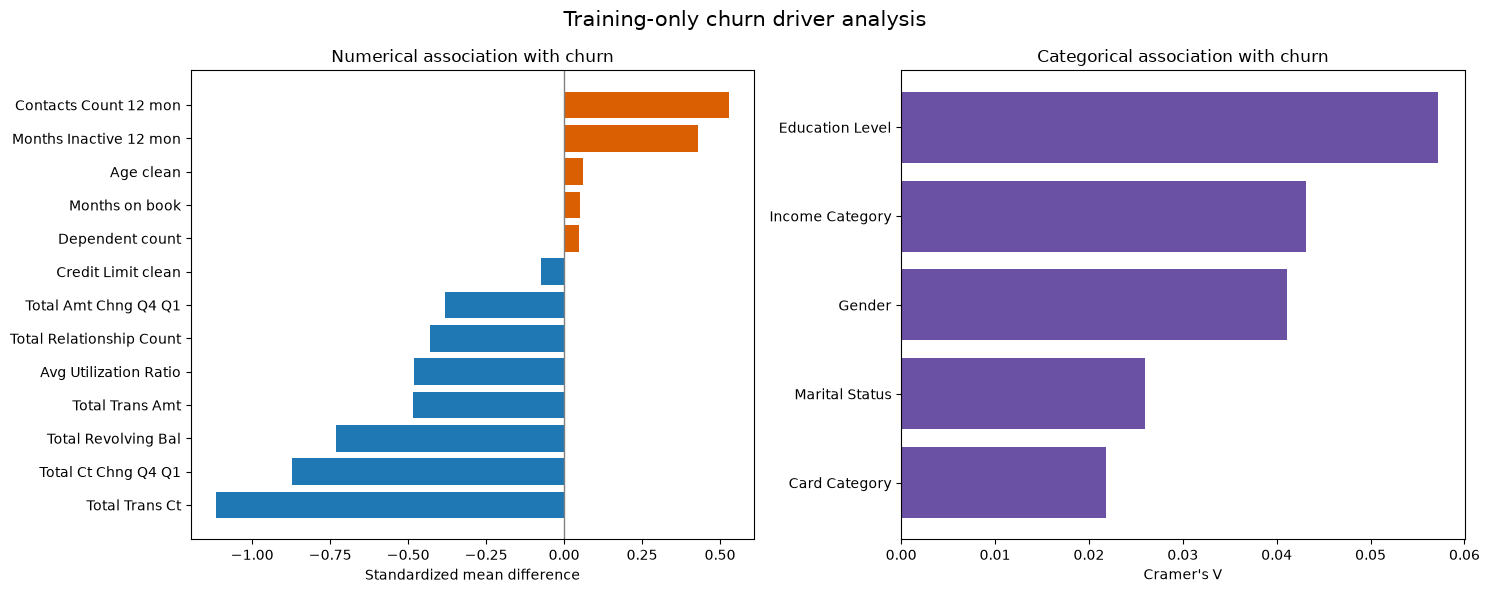

In [57]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
numeric_plot = numeric_drivers.sort_values("standardized_mean_difference")
axes[0].barh(
    numeric_plot["feature"].str.replace("_", " ", regex=False),
    numeric_plot["standardized_mean_difference"],
    color=np.where(numeric_plot["standardized_mean_difference"].ge(0), "#d95f02", "#1f77b4"),
)
axes[0].axvline(0, color="grey", linewidth=1)
axes[0].set(title="Numerical association with churn", xlabel="Standardized mean difference")
categorical_plot = categorical_drivers.sort_values("cramers_v")
axes[1].barh(
    categorical_plot["feature"].str.replace("_clean", "", regex=False).str.replace("_", " ", regex=False),
    categorical_plot["cramers_v"], color="#6a51a3",
)
axes[1].set(title="Categorical association with churn", xlabel="Cramer's V")
fig.suptitle("Training-only churn driver analysis", fontsize=15)
plt.tight_layout()
plt.show()


### 9.6 Closed-account signature

In [58]:
closed_account_signature = pd.DataFrame({
    column: driver_train.groupby("Churned", observed=True)[column].apply(lambda s: s.eq(0).mean())
    for column in ["Total_Revolving_Bal", "Avg_Utilization_Ratio"]
})
closed_account_signature["both_zero"] = (
    driver_train.assign(
        both_zero=driver_train["Total_Revolving_Bal"].eq(0) & driver_train["Avg_Utilization_Ratio"].eq(0)
    ).groupby("Churned", observed=True)["both_zero"].mean()
)
closed_account_signature.index = closed_account_signature.index.map({0: "Existing", 1: "Attrited"})
display(closed_account_signature.map(lambda value: f"{value:.1%}"))

gap = (
    closed_account_signature.loc["Attrited", "both_zero"]
    - closed_account_signature.loc["Existing", "both_zero"]
)
print(
    f"{closed_account_signature.loc['Attrited', 'both_zero']:.1%} of attrited training customers show "
    f"both zero revolving balance and zero utilization, versus "
    f"{closed_account_signature.loc['Existing', 'both_zero']:.1%} of existing customers "
    f"({gap:+.1%} gap). This is training-only, descriptive evidence, not a data-quality flag: it does "
    "not change any ETL treatment, and it does not by itself prove temporal leakage - but it is "
    "consistent with the same mechanism the reduced-risk benchmark (10.8) quantifies."
)

,Total_Revolving_Bal,Avg_Utilization_Ratio,both_zero
Churned,,,
Existing,18.9%,18.9%,18.9%
Attrited,54.7%,54.7%,54.7%


54.7% of attrited training customers show both zero revolving balance and zero utilization, versus 18.9% of existing customers (+35.7% gap). This is training-only, descriptive evidence, not a data-quality flag: it does not change any ETL treatment, and it does not by itself prove temporal leakage - but it is consistent with the same mechanism the reduced-risk benchmark (10.8) quantifies.


## 10. Alternative data treatments

### 10.1 Leakage-safe preprocessing

In [59]:
def build_preprocessor(numeric_features, categorical_features, dense_output=False):
    numeric_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
        ("scaler", StandardScaler()),
    ])
    try:
        encoder = OneHotEncoder(
            handle_unknown="ignore", sparse_output=not dense_output
        )
    except TypeError:
        encoder = OneHotEncoder(
            handle_unknown="ignore", sparse=not dense_output
        )
    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", encoder),
    ])
    return ColumnTransformer(
        [
            ("numeric", numeric_pipeline, numeric_features),
            ("categorical", categorical_pipeline, categorical_features),
        ],
        sparse_threshold=0.0 if dense_output else 0.3,
    )


### 10.2 Alternative treatment fields

In [60]:
sensitivity_data = modeling_base.copy()
sensitivity_data["Credit_Limit_missing_alt"] = sensitivity_data["Credit_Limit"].mask(
    sensitivity_data["Credit_Limit_reconstructed"]
)
sensitivity_data["Education_availability_alt"] = sensitivity_data["Education_Level_clean"].astype("string").replace({
    "Missing": "Unavailable", "Unknown": "Unavailable"
})



### 10.3 Treatment variants

In [61]:
credit_missing_numeric = [
    "Credit_Limit_missing_alt" if feature == "Credit_Limit_clean" else feature
    for feature in MODEL_NUMERIC_FEATURES
]
education_combined_categorical = [
    "Education_availability_alt" if feature == "Education_Level_clean" else feature
    for feature in MODEL_CATEGORICAL_FEATURES
]
sensitivity_specs = [
    ("Primary treatment", MODEL_NUMERIC_FEATURES, MODEL_CATEGORICAL_FEATURES),
    ("Exclude age", [f for f in MODEL_NUMERIC_FEATURES if f != "Age_clean"], MODEL_CATEGORICAL_FEATURES),
    ("Credit limit as missing", credit_missing_numeric, MODEL_CATEGORICAL_FEATURES),
    ("Combine missing/unknown education", MODEL_NUMERIC_FEATURES, education_combined_categorical),
    ("Include gender", MODEL_NUMERIC_FEATURES, MODEL_CATEGORICAL_FEATURES + ["Gender_clean"]),
]



### 10.4 Compare variants in CV

In [62]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
sensitivity_rows = []
for treatment, numeric_features, categorical_features in sensitivity_specs:
    variant_features = numeric_features + categorical_features
    variant_pipeline = Pipeline([
        ("preprocess", build_preprocessor(numeric_features, categorical_features)),
        ("model", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
    ])
    scores = cross_validate(
        variant_pipeline, sensitivity_data.loc[X_train.index, variant_features], y_train,
        cv=cv, scoring={"roc_auc": "roc_auc", "pr_auc": "average_precision"},
        n_jobs=1, error_score="raise",
    )
    sensitivity_rows.append({
        "treatment": treatment,
        "cv_roc_auc_mean": scores["test_roc_auc"].mean(),
        "cv_pr_auc_mean": scores["test_pr_auc"].mean(),
        "cv_pr_auc_sd": scores["test_pr_auc"].std(ddof=1),
    })

sensitivity_results = pd.DataFrame(sensitivity_rows)


**Compare treatments**

In [63]:
primary_pr_auc = sensitivity_results.loc[
    sensitivity_results["treatment"].eq("Primary treatment"), "cv_pr_auc_mean"
].iloc[0]
sensitivity_results["pr_auc_change_vs_primary"] = sensitivity_results["cv_pr_auc_mean"] - primary_pr_auc
display(sensitivity_results.round(4))


,treatment,cv_roc_auc_mean,cv_pr_auc_mean,cv_pr_auc_sd,pr_auc_change_vs_primary
0,Primary treatment,0.9262,0.7740,0.0091,0.0000
1,Exclude age,0.9261,0.7745,0.0101,0.0005
2,Credit limit as missing,0.9261,0.7741,0.0091,0.0001
3,Combine missing/unknown education,0.9265,0.7746,0.0090,0.0006
4,Include gender,0.9273,0.7779,0.0106,0.0039


### 10.5 Campaign-capacity metric

In [64]:
def top_capacity_metrics(y_true, probabilities, capacity):
    y_array = np.asarray(y_true)
    probability_array = np.asarray(probabilities)
    target_count = max(1, int(np.ceil(len(y_array) * capacity)))
    selected = np.argsort(-probability_array, kind="stable")[:target_count]
    selected_churners = y_array[selected].sum()
    precision = selected_churners / target_count
    recall = selected_churners / y_array.sum()
    lift = precision / y_array.mean()
    return precision, recall, lift




### 10.6 Age and gender ablation

In [65]:
rf_ablation_specs = [
    ("Final model: exclude gender", MODEL_NUMERIC_FEATURES, MODEL_CATEGORICAL_FEATURES),
    ("Include gender", MODEL_NUMERIC_FEATURES, MODEL_CATEGORICAL_FEATURES + ["Gender_clean"]),
    (
        "Exclude age and gender",
        [f for f in MODEL_NUMERIC_FEATURES if f != "Age_clean"],
        MODEL_CATEGORICAL_FEATURES,
    ),
    (
        "Exclude age, include gender",
        [f for f in MODEL_NUMERIC_FEATURES if f != "Age_clean"],
        MODEL_CATEGORICAL_FEATURES + ["Gender_clean"],
    ),
]



**Run the ablation**

In [66]:
rf_ablation_rows = []
rf_ablation_fold_scores = {}
for treatment, numeric_features, categorical_features in rf_ablation_specs:
    variant_features = numeric_features + categorical_features
    rf_pipeline = Pipeline([
        ("preprocess", build_preprocessor(numeric_features, categorical_features)),
        ("model", RandomForestClassifier(
            n_estimators=300, min_samples_leaf=5, max_features="sqrt",
            class_weight="balanced_subsample", random_state=RANDOM_STATE, n_jobs=-1,
        )),
    ])
    scores = cross_validate(
        rf_pipeline, modeling_base.loc[X_train.index, variant_features], y_train,
        cv=cv,
        scoring={"roc_auc": "roc_auc", "pr_auc": "average_precision", "neg_brier": "neg_brier_score"},
        n_jobs=1, error_score="raise",
    )
    rf_ablation_fold_scores[treatment] = scores
    rf_ablation_rows.append({
        "treatment": treatment,
        "cv_pr_auc": scores["test_pr_auc"].mean(),
        "pr_auc_sd": scores["test_pr_auc"].std(ddof=1),
        "cv_roc_auc": scores["test_roc_auc"].mean(),
        "cv_brier": -scores["test_neg_brier"].mean(),
    })



**Summarize the ablation**

In [67]:
rf_ablation_results = pd.DataFrame(rf_ablation_rows)
baseline_pr = rf_ablation_results.loc[
    rf_ablation_results["treatment"].eq("Final model: exclude gender"), "cv_pr_auc"
].iloc[0]
baseline_brier = rf_ablation_results.loc[
    rf_ablation_results["treatment"].eq("Final model: exclude gender"), "cv_brier"
].iloc[0]
baseline_fold_pr = rf_ablation_fold_scores["Final model: exclude gender"]["test_pr_auc"]
rf_ablation_results["pr_auc_change"] = rf_ablation_results["cv_pr_auc"] - baseline_pr
rf_ablation_results["brier_change"] = rf_ablation_results["cv_brier"] - baseline_brier
rf_ablation_results["paired_pr_change_sd"] = [
    (rf_ablation_fold_scores[name]["test_pr_auc"] - baseline_fold_pr).std(ddof=1)
    for name in rf_ablation_results["treatment"]
]
rf_ablation_results = rf_ablation_results.sort_values("cv_pr_auc", ascending=False).reset_index(drop=True)
display(rf_ablation_results.round(4))
print("Best variant by training CV PR-AUC:", rf_ablation_results.iloc[0]["treatment"])



,treatment,cv_pr_auc,pr_auc_sd,cv_roc_auc,cv_brier,pr_auc_change,brier_change,paired_pr_change_sd
0,Final model: exclude gender,0.9468,0.0101,0.9884,0.0389,0.0000,0.0000,0.0000
1,Include gender,0.9433,0.0100,0.9875,0.0402,-0.0035,0.0014,0.0006
2,"Exclude age, include gender",0.9360,0.0125,0.9864,0.0414,-0.0107,0.0026,0.0059
3,Exclude age and gender,0.9324,0.0136,0.9857,0.0430,-0.0144,0.0041,0.0089


Best variant by training CV PR-AUC: Final model: exclude gender


### 10.7 Correlated-feature ablation

In [68]:
def cv_top_10pct_precision(estimator, X_fold, y_fold):
    probabilities = estimator.predict_proba(X_fold)[:, 1]
    return top_capacity_metrics(y_fold, probabilities, CAMPAIGN_CAPACITY)[0]


def cv_top_10pct_recall(estimator, X_fold, y_fold):
    probabilities = estimator.predict_proba(X_fold)[:, 1]
    return top_capacity_metrics(y_fold, probabilities, CAMPAIGN_CAPACITY)[1]


def cv_top_10pct_lift(estimator, X_fold, y_fold):
    probabilities = estimator.predict_proba(X_fold)[:, 1]
    return top_capacity_metrics(y_fold, probabilities, CAMPAIGN_CAPACITY)[2]




**Define variants**

In [69]:
correlation_ablation_specs = [
    ("Final model: exclude months on book", [], []),
    ("Include months on book", [], ["Months_on_book"]),
    ("Exclude transaction amount", ["Total_Trans_Amt"], []),
    ("Exclude transaction count", ["Total_Trans_Ct"], []),
    ("Exclude transaction amount, include months on book", ["Total_Trans_Amt"], ["Months_on_book"]),
]
correlation_ablation_scoring = {
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision",
    "neg_brier": "neg_brier_score",
    "top_10pct_precision": cv_top_10pct_precision,
    "top_10pct_recall": cv_top_10pct_recall,
    "top_10pct_lift": cv_top_10pct_lift,
}


**Evaluate variants**

In [70]:
correlation_ablation_rows = []
correlation_ablation_fold_scores = {}
for treatment, excluded_features, included_features in correlation_ablation_specs:
    numeric_features = [feature for feature in MODEL_NUMERIC_FEATURES if feature not in excluded_features]
    for included_feature in included_features:
        if included_feature == "Months_on_book" and included_feature not in numeric_features:
            numeric_features.insert(2, included_feature)
    variant_features = numeric_features + MODEL_CATEGORICAL_FEATURES
    variant_pipeline = Pipeline([
        ("preprocess", build_preprocessor(numeric_features, MODEL_CATEGORICAL_FEATURES)),
        ("model", RandomForestClassifier(
            n_estimators=300, min_samples_leaf=5, max_features="sqrt",
            class_weight="balanced_subsample", random_state=RANDOM_STATE, n_jobs=-1,
        )),
    ])
    scores = cross_validate(
        variant_pipeline, modeling_base.loc[X_train.index, variant_features], y_train,
        cv=cv, scoring=correlation_ablation_scoring, n_jobs=1, error_score="raise",
    )
    correlation_ablation_fold_scores[treatment] = scores
    correlation_ablation_rows.append({
        "treatment": treatment,
        "input_features": len(variant_features),
        "cv_pr_auc": scores["test_pr_auc"].mean(),
        "pr_auc_sd": scores["test_pr_auc"].std(ddof=1),
        "cv_roc_auc": scores["test_roc_auc"].mean(),
        "cv_brier": -scores["test_neg_brier"].mean(),
        "top_10pct_precision": scores["test_top_10pct_precision"].mean(),
        "top_10pct_recall": scores["test_top_10pct_recall"].mean(),
        "top_10pct_lift": scores["test_top_10pct_lift"].mean(),
    })



**Compare results**

In [71]:
correlation_ablation_results = pd.DataFrame(correlation_ablation_rows)
baseline_row = correlation_ablation_results.loc[
    correlation_ablation_results["treatment"].eq("Final model: exclude months on book")
].iloc[0]
baseline_fold_pr = correlation_ablation_fold_scores["Final model: exclude months on book"]["test_pr_auc"]
correlation_ablation_results["pr_auc_change"] = correlation_ablation_results["cv_pr_auc"] - baseline_row["cv_pr_auc"]
correlation_ablation_results["brier_change"] = correlation_ablation_results["cv_brier"] - baseline_row["cv_brier"]
correlation_ablation_results["top_recall_change"] = correlation_ablation_results["top_10pct_recall"] - baseline_row["top_10pct_recall"]
correlation_ablation_results["top_lift_change"] = correlation_ablation_results["top_10pct_lift"] - baseline_row["top_10pct_lift"]
correlation_ablation_results["paired_pr_change_sd"] = [
    (correlation_ablation_fold_scores[name]["test_pr_auc"] - baseline_fold_pr).std(ddof=1)
    for name in correlation_ablation_results["treatment"]
]
correlation_ablation_results = correlation_ablation_results.sort_values("cv_pr_auc", ascending=False).reset_index(drop=True)
display(correlation_ablation_results.round(4))
print("Best correlated-feature variant by training CV PR-AUC:", correlation_ablation_results.iloc[0]["treatment"])



,treatment,input_features,cv_pr_auc,pr_auc_sd,cv_roc_auc,cv_brier,top_10pct_precision,top_10pct_recall,top_10pct_lift,pr_auc_change,brier_change,top_recall_change,top_lift_change,paired_pr_change_sd
0,Final model: exclude months on book,16,0.9468,0.0101,0.9884,0.0389,0.9708,0.5831,5.8123,0.0000,0.0000,0.0000,0.0000,0.0000
1,Include months on book,17,0.9460,0.0113,0.9884,0.0388,0.9708,0.5831,5.8123,-0.0007,-0.0000,0.0000,0.0000,0.0012
2,Exclude transaction count,15,0.9033,0.0107,0.9755,0.0536,0.9373,0.5630,5.6116,-0.0435,0.0148,-0.0201,-0.2006,0.0037
3,"Exclude transaction amount, include months on ...",16,0.8827,0.0185,0.9678,0.0557,0.9319,0.5597,5.5792,-0.0641,0.0168,-0.0234,-0.2330,0.0096
4,Exclude transaction amount,15,0.8784,0.0190,0.9655,0.0588,0.9243,0.5552,5.5339,-0.0684,0.0200,-0.0279,-0.2783,0.0108


Best correlated-feature variant by training CV PR-AUC: Final model: exclude months on book


### 10.8 Timing-risk benchmark

In [72]:
timing_sensitivity_specs = [
    ("Primary feature set", MODEL_NUMERIC_FEATURES, MODEL_CATEGORICAL_FEATURES),
    ("Reduced-risk profile/static set", REDUCED_RISK_NUMERIC_FEATURES, REDUCED_RISK_CATEGORICAL_FEATURES),
]
timing_sensitivity_rows = []
for treatment, numeric_features, categorical_features in timing_sensitivity_specs:
    variant_features = numeric_features + categorical_features
    timing_pipeline = Pipeline([
        ("preprocess", build_preprocessor(numeric_features, categorical_features)),
        ("model", RandomForestClassifier(
            n_estimators=300, min_samples_leaf=5, max_features="sqrt",
            class_weight=None, random_state=RANDOM_STATE, n_jobs=-1,
        )),
    ])
    scores = cross_validate(
        timing_pipeline, development_base[variant_features], y_train,
        cv=cv,
        scoring={
            "roc_auc": "roc_auc", "pr_auc": "average_precision",
            "neg_brier": "neg_brier_score",
        },
        n_jobs=1, error_score="raise",
    )
    timing_sensitivity_rows.append({
        "treatment": treatment,
        "input_features": len(variant_features),
        "cv_roc_auc": scores["test_roc_auc"].mean(),
        "cv_pr_auc": scores["test_pr_auc"].mean(),
        "cv_pr_auc_sd": scores["test_pr_auc"].std(ddof=1),
        "cv_brier": -scores["test_neg_brier"].mean(),
    })

timing_sensitivity_results = pd.DataFrame(timing_sensitivity_rows)
primary_timing_pr_auc = timing_sensitivity_results.loc[
    timing_sensitivity_results["treatment"].eq("Primary feature set"), "cv_pr_auc"
].iloc[0]
timing_sensitivity_results["pr_auc_change_vs_primary"] = (
    timing_sensitivity_results["cv_pr_auc"] - primary_timing_pr_auc
)
display(timing_sensitivity_results.round(4))


,treatment,input_features,cv_roc_auc,cv_pr_auc,cv_pr_auc_sd,cv_brier,pr_auc_change_vs_primary
0,Primary feature set,16,0.9885,0.9504,0.0106,0.0370,0.0000
1,Reduced-risk profile/static set,7,0.6339,0.3025,0.0242,0.1328,-0.6479


**Plot timing sensitivity**

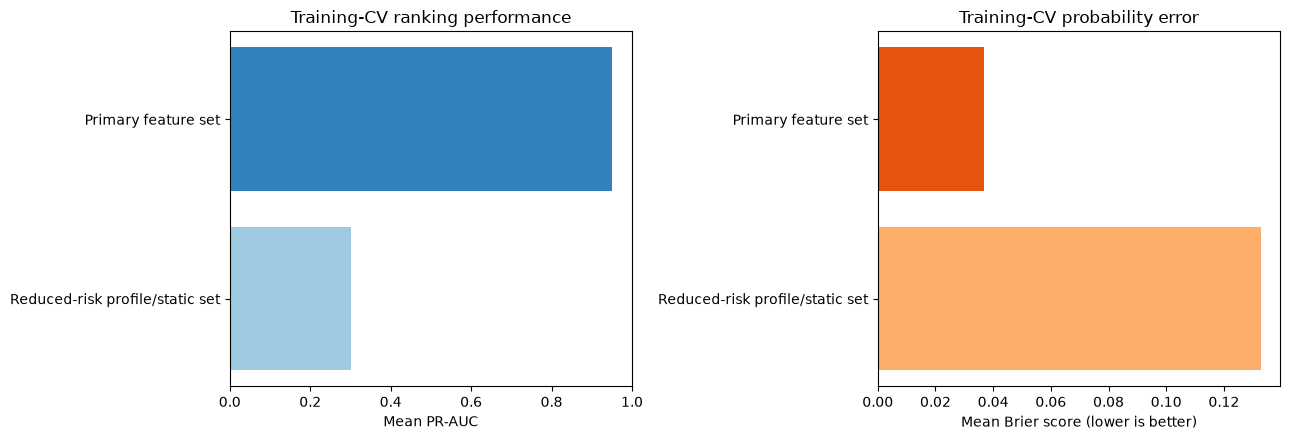

In [73]:
timing_plot = timing_sensitivity_results.sort_values("cv_pr_auc")
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].barh(timing_plot["treatment"], timing_plot["cv_pr_auc"], color=["#9ecae1", "#3182bd"])
axes[0].set(title="Training-CV ranking performance", xlabel="Mean PR-AUC", xlim=(0, 1))
axes[1].barh(timing_plot["treatment"], timing_plot["cv_brier"], color=["#fdae6b", "#e6550d"])
axes[1].set(title="Training-CV probability error", xlabel="Mean Brier score (lower is better)")
plt.tight_layout()
plt.show()


## 11. Train and compare models

### 11.1 Final preprocessing pipeline

In [74]:
preprocessor = build_preprocessor(MODEL_NUMERIC_FEATURES, MODEL_CATEGORICAL_FEATURES)


### 11.2 Candidate models

In [75]:
candidate_models = {
    "Dummy baseline": DummyClassifier(strategy="prior"),
    "Logistic regression": LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    "Random forest": RandomForestClassifier(
        n_estimators=300, min_samples_leaf=5, max_features="sqrt",
        class_weight="balanced_subsample", random_state=RANDOM_STATE, n_jobs=-1,
    ),
    "Histogram gradient boosting": HistGradientBoostingClassifier(
        learning_rate=0.05, max_iter=300, max_leaf_nodes=31,
        min_samples_leaf=20, l2_regularization=1.0,
        early_stopping=True, validation_fraction=0.15,
        n_iter_no_change=20, random_state=RANDOM_STATE,
    ),
}


### 11.3 Compare candidates in CV

In [76]:
model_rows = []
for model_name, estimator in candidate_models.items():
    use_dense_preprocessing = model_name == "Histogram gradient boosting"
    model_preprocessor = build_preprocessor(
        MODEL_NUMERIC_FEATURES,
        MODEL_CATEGORICAL_FEATURES,
        dense_output=use_dense_preprocessing,
    )
    pipeline = Pipeline([
        ("preprocess", model_preprocessor),
        ("model", clone(estimator)),
    ])
    scores = cross_validate(
        pipeline, X_train, y_train, cv=cv,
        scoring={
            "roc_auc": "roc_auc", "pr_auc": "average_precision",
            "neg_brier": "neg_brier_score",
        },
        n_jobs=1, error_score="raise",
    )
    model_rows.append({
        "model": model_name,
        "cv_roc_auc": scores["test_roc_auc"].mean(),
        "cv_pr_auc": scores["test_pr_auc"].mean(),
        "cv_pr_auc_sd": scores["test_pr_auc"].std(ddof=1),
        "cv_brier": -scores["test_neg_brier"].mean(),
    })


**Select the best family**

In [77]:
model_results = pd.DataFrame(model_rows).sort_values("cv_pr_auc", ascending=False).reset_index(drop=True)
eligible_models = model_results.loc[model_results["model"].ne("Dummy baseline")]
best_model_name = eligible_models.sort_values("cv_pr_auc", ascending=False).iloc[0]["model"]

display(model_results.round(4))
print(f"Selected model family by mean development CV PR-AUC: {best_model_name}")
print("The sealed holdout has not been used for this selection.")


,model,cv_roc_auc,cv_pr_auc,cv_pr_auc_sd,cv_brier
0,Histogram gradient boosting,0.9937,0.9738,0.0068,0.0207
1,Random forest,0.9884,0.9468,0.0101,0.0389
2,Logistic regression,0.9262,0.7740,0.0091,0.0704
3,Dummy baseline,0.5000,0.1670,0.0000,0.1391


Selected model family by mean development CV PR-AUC: Histogram gradient boosting
The sealed holdout has not been used for this selection.


### 11.4 Model comparison charts

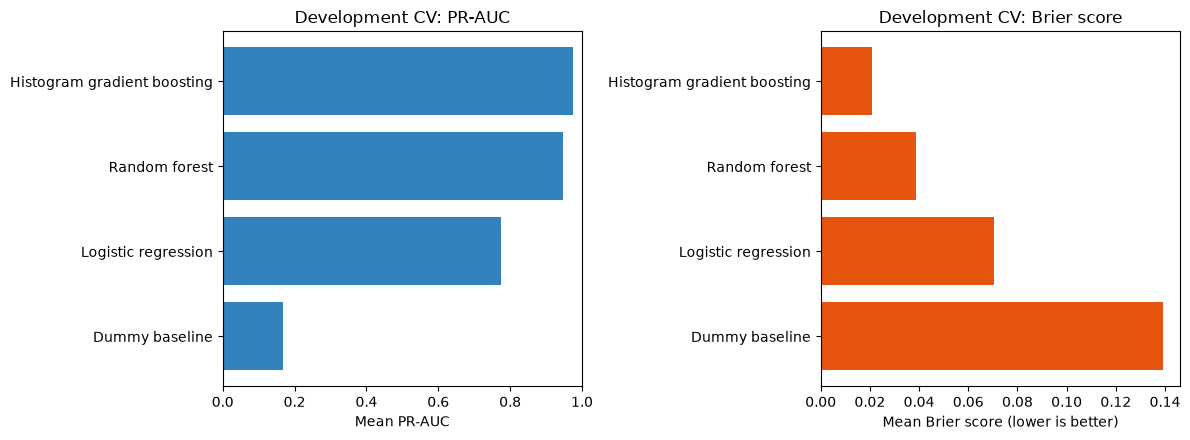

In [78]:
model_plot = model_results.sort_values("cv_pr_auc")
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].barh(model_plot["model"], model_plot["cv_pr_auc"], color="#3182bd")
axes[0].set(title="Development CV: PR-AUC", xlabel="Mean PR-AUC", xlim=(0, 1))
axes[1].barh(model_plot["model"], model_plot["cv_brier"], color="#e6550d")
axes[1].set(title="Development CV: Brier score", xlabel="Mean Brier score (lower is better)")
plt.tight_layout()
plt.show()


## 12. Probability, fairness, and leakage

### 12.1 Select the probability model

**Selection guardrails**

In [79]:
CALIBRATION_INNER_FOLDS = 3
CALIBRATION_PR_TOLERANCE = 0.01
CHALLENGER_MIN_PR_GAIN = 0.005
CHALLENGER_MAX_BRIER_INCREASE = 0.001
CHALLENGER_MAX_TOP_LIFT_LOSS = 0.05


**Random forest pipeline**

In [80]:
def random_forest_pipeline(class_weight, numeric_features=None, categorical_features=None):
    numeric_features = numeric_features or MODEL_NUMERIC_FEATURES
    categorical_features = categorical_features or MODEL_CATEGORICAL_FEATURES
    return Pipeline([
        ("preprocess", build_preprocessor(numeric_features, categorical_features)),
        ("model", RandomForestClassifier(
            n_estimators=300, min_samples_leaf=5, max_features="sqrt",
            class_weight=class_weight, random_state=RANDOM_STATE, n_jobs=-1,
        )),
    ])


**HGB challenger pipeline**

In [81]:
def histogram_gradient_pipeline(numeric_features=None, categorical_features=None):
    numeric_features = numeric_features or MODEL_NUMERIC_FEATURES
    categorical_features = categorical_features or MODEL_CATEGORICAL_FEATURES
    return Pipeline([
        ("preprocess", build_preprocessor(
            numeric_features, categorical_features, dense_output=True
        )),
        ("model", HistGradientBoostingClassifier(
            learning_rate=0.05, max_iter=300, max_leaf_nodes=31,
            min_samples_leaf=20, l2_regularization=1.0,
            early_stopping=True, validation_fraction=0.15,
            n_iter_no_change=20, random_state=RANDOM_STATE,
        )),
    ])


**Candidate factory**

In [82]:
def build_probability_candidate(candidate_name, numeric_features=None, categorical_features=None):
    if candidate_name.startswith("Weighted RF"):
        base_pipeline = random_forest_pipeline(
            "balanced_subsample", numeric_features, categorical_features
        )
    elif candidate_name.startswith("Unweighted RF"):
        base_pipeline = random_forest_pipeline(
            None, numeric_features, categorical_features
        )
    elif candidate_name.startswith("Histogram GB"):
        base_pipeline = histogram_gradient_pipeline(
            numeric_features, categorical_features
        )
    else:
        raise ValueError(f"Unsupported probability candidate: {candidate_name}")

    if candidate_name.endswith("sigmoid"):
        return CalibratedClassifierCV(
            estimator=base_pipeline, method="sigmoid", cv=CALIBRATION_INNER_FOLDS
        )
    if candidate_name.endswith("isotonic"):
        return CalibratedClassifierCV(
            estimator=base_pipeline, method="isotonic", cv=CALIBRATION_INNER_FOLDS
        )
    return base_pipeline


**Instantiate candidates**

In [83]:
calibration_candidate_names = [
    "Weighted RF - uncalibrated",
    "Unweighted RF - uncalibrated",
    "Unweighted RF - sigmoid",
    "Unweighted RF - isotonic",
    "Histogram GB - uncalibrated",
    "Histogram GB - sigmoid",
]
calibration_candidates = {
    candidate_name: build_probability_candidate(candidate_name)
    for candidate_name in calibration_candidate_names
}


**Capacity-based scorers**

In [84]:
def calibration_top_precision(estimator, X_fold, y_fold):
    return top_capacity_metrics(y_fold, estimator.predict_proba(X_fold)[:, 1], CAMPAIGN_CAPACITY)[0]


def calibration_top_recall(estimator, X_fold, y_fold):
    return top_capacity_metrics(y_fold, estimator.predict_proba(X_fold)[:, 1], CAMPAIGN_CAPACITY)[1]


def calibration_top_lift(estimator, X_fold, y_fold):
    return top_capacity_metrics(y_fold, estimator.predict_proba(X_fold)[:, 1], CAMPAIGN_CAPACITY)[2]




**Selection metrics**

In [85]:
calibration_scoring = {
    "roc_auc": "roc_auc", "pr_auc": "average_precision",
    "neg_brier": "neg_brier_score", "neg_log_loss": "neg_log_loss",
    "top_precision": calibration_top_precision,
    "top_recall": calibration_top_recall,
    "top_lift": calibration_top_lift,
}


**Evaluate candidates**

In [86]:
calibration_rows = []
for candidate_name, candidate in calibration_candidates.items():
    scores = cross_validate(
        clone(candidate), X_train, y_train, cv=cv, scoring=calibration_scoring,
        n_jobs=1, error_score="raise",
    )
    calibration_rows.append({
        "candidate": candidate_name,
        "cv_pr_auc": scores["test_pr_auc"].mean(),
        "cv_pr_auc_sd": scores["test_pr_auc"].std(ddof=1),
        "cv_roc_auc": scores["test_roc_auc"].mean(),
        "cv_brier": -scores["test_neg_brier"].mean(),
        "cv_log_loss": -scores["test_neg_log_loss"].mean(),
        "cv_top_10pct_precision": scores["test_top_precision"].mean(),
        "cv_top_10pct_recall": scores["test_top_recall"].mean(),
        "cv_top_10pct_lift": scores["test_top_lift"].mean(),
    })


**Select the RF incumbent**

In [87]:
calibration_results = pd.DataFrame(calibration_rows)

rf_probability_results = calibration_results.loc[
    calibration_results["candidate"].str.contains("RF")
].copy()
best_rf_pr_auc = rf_probability_results["cv_pr_auc"].max()
rf_probability_results["within_pr_tolerance"] = rf_probability_results[
    "cv_pr_auc"
].ge(best_rf_pr_auc - CALIBRATION_PR_TOLERANCE)
incumbent_probability_model_name = rf_probability_results.loc[
    rf_probability_results["within_pr_tolerance"]
].sort_values(["cv_brier", "cv_log_loss"]).iloc[0]["candidate"]


**Select the HGB challenger**

In [88]:
challenger_results = calibration_results.loc[
    calibration_results["candidate"].str.startswith("Histogram GB")
].sort_values(["cv_pr_auc", "cv_brier"], ascending=[False, True])
best_challenger_name = challenger_results.iloc[0]["candidate"]


**Apply adoption guardrails**

In [89]:
incumbent_row = calibration_results.set_index("candidate").loc[
    incumbent_probability_model_name
]
challenger_row = calibration_results.set_index("candidate").loc[
    best_challenger_name
]
challenger_adopted = bool(
    challenger_row["cv_pr_auc"] >= incumbent_row["cv_pr_auc"] + CHALLENGER_MIN_PR_GAIN
    and challenger_row["cv_brier"] <= incumbent_row["cv_brier"] + CHALLENGER_MAX_BRIER_INCREASE
    and challenger_row["cv_top_10pct_lift"]
    >= incumbent_row["cv_top_10pct_lift"] - CHALLENGER_MAX_TOP_LIFT_LOSS
)
selected_probability_model_name = (
    best_challenger_name if challenger_adopted
    else incumbent_probability_model_name
)
selected_probability_pipeline = clone(
    calibration_candidates[selected_probability_model_name]
)


**Record the decision**

In [90]:
challenger_decision = pd.Series({
    "incumbent": incumbent_probability_model_name,
    "challenger": best_challenger_name,
    "challenger_pr_auc_gain": (
        challenger_row["cv_pr_auc"] - incumbent_row["cv_pr_auc"]
    ),
    "challenger_brier_change": (
        challenger_row["cv_brier"] - incumbent_row["cv_brier"]
    ),
    "challenger_top_lift_change": (
        challenger_row["cv_top_10pct_lift"]
        - incumbent_row["cv_top_10pct_lift"]
    ),
    "challenger_adopted": challenger_adopted,
    "selected_probability_model": selected_probability_model_name,
}, name="development_only_decision")


**Development OOF probabilities**

In [91]:
development_oof_probabilities = cross_val_predict(
    clone(selected_probability_pipeline), X_train, y_train,
    cv=cv, method="predict_proba", n_jobs=1,
)[:, 1]


**Show the decision**

In [92]:
display(calibration_results.sort_values("cv_brier").round(4))
display(challenger_decision.to_frame())
print("Selected probability model by development CV:", selected_probability_model_name)
print("The sealed holdout has not been used for model or challenger selection.")


,candidate,cv_pr_auc,cv_pr_auc_sd,cv_roc_auc,cv_brier,cv_log_loss,cv_top_10pct_precision,cv_top_10pct_recall,cv_top_10pct_lift
4,Histogram GB - uncalibrated,0.9738,0.0068,0.9937,0.0207,0.0738,0.9935,0.5968,5.9482
5,Histogram GB - sigmoid,0.9731,0.0059,0.9937,0.0210,0.0748,0.9924,0.5961,5.9417
3,Unweighted RF - isotonic,0.9393,0.0127,0.9862,0.0326,0.1197,0.9697,0.5825,5.8058
2,Unweighted RF - sigmoid,0.9412,0.0105,0.9866,0.0331,0.1155,0.9697,0.5825,5.8058
1,Unweighted RF - uncalibrated,0.9504,0.0106,0.9885,0.0370,0.1389,0.9795,0.5883,5.8640
0,Weighted RF - uncalibrated,0.9468,0.0101,0.9884,0.0389,0.1545,0.9708,0.5831,5.8123


,development_only_decision
incumbent,Unweighted RF - sigmoid
challenger,Histogram GB - uncalibrated
challenger_pr_auc_gain,0.032643
challenger_brier_change,-0.012342
challenger_top_lift_change,0.142394
challenger_adopted,True
selected_probability_model,Histogram GB - uncalibrated


Selected probability model by development CV: Histogram GB - uncalibrated
The sealed holdout has not been used for model or challenger selection.


### 12.2 Repeated CV and list stability

**Initialize repeated OOF**

In [93]:
STABILITY_REPEATS = 3
repeated_oof_scores = pd.DataFrame(index=X_train.index)
repeated_oof_metric_rows = []
development_existing_index = development_base.index[
    development_base["Attrition_Flag_clean"].eq("Existing Customer")
]
repeated_high_priority_sets = []


**Generate repeated OOF scores**

In [94]:
for repeat_number in range(STABILITY_REPEATS):
    if repeat_number == 0:
        repeat_probabilities = development_oof_probabilities
    else:
        repeat_cv = StratifiedKFold(
            n_splits=5, shuffle=True,
            random_state=RANDOM_STATE + repeat_number,
        )
        repeat_probabilities = cross_val_predict(
            clone(selected_probability_pipeline), X_train, y_train,
            cv=repeat_cv, method="predict_proba", n_jobs=1,
        )[:, 1]

    score_column = f"repeat_{repeat_number + 1}"
    repeated_oof_scores[score_column] = repeat_probabilities
    repeat_top_precision, repeat_top_recall, repeat_top_lift = top_capacity_metrics(
        y_train, repeat_probabilities, CAMPAIGN_CAPACITY
    )
    repeated_oof_metric_rows.append({
        "repeat": repeat_number + 1,
        "roc_auc": roc_auc_score(y_train, repeat_probabilities),
        "pr_auc": average_precision_score(y_train, repeat_probabilities),
        "brier": brier_score_loss(y_train, repeat_probabilities),
        "log_loss": log_loss(y_train, repeat_probabilities),
        "top_10pct_precision": repeat_top_precision,
        "top_10pct_recall": repeat_top_recall,
        "top_10pct_lift": repeat_top_lift,
    })

    existing_repeat_scores = repeated_oof_scores.loc[
        development_existing_index, score_column
    ]
    high_count = max(1, int(np.ceil(len(existing_repeat_scores) * 0.10)))
    repeated_high_priority_sets.append(set(
        existing_repeat_scores.nlargest(high_count).index
    ))


**Summarize repeated performance**

In [95]:
repeated_oof_metrics = pd.DataFrame(repeated_oof_metric_rows)
repeated_oof_summary = repeated_oof_metrics.drop(columns="repeat").agg(
    ["mean", "std", "min", "max"]
).T
development_policy_probabilities = repeated_oof_scores.mean(axis=1).to_numpy()


**Count high-risk selections**

In [96]:
high_priority_frequency = pd.Series(
    0.0, index=development_existing_index, name="high_priority_frequency"
)
for selected_set in repeated_high_priority_sets:
    high_priority_frequency.loc[list(selected_set)] += 1 / STABILITY_REPEATS


**Compare top-risk lists**

In [97]:
pairwise_jaccards = []
for left in range(STABILITY_REPEATS):
    for right in range(left + 1, STABILITY_REPEATS):
        intersection = len(
            repeated_high_priority_sets[left] & repeated_high_priority_sets[right]
        )
        union = len(
            repeated_high_priority_sets[left] | repeated_high_priority_sets[right]
        )
        pairwise_jaccards.append(intersection / union)


**Build the stability summary**

In [98]:
priority_stability_summary = pd.Series({
    "development_existing_customers": len(development_existing_index),
    "top_10pct_customers_per_repeat": len(repeated_high_priority_sets[0]),
    "customers_selected_in_all_repeats": high_priority_frequency.eq(1.0).sum(),
    "share_of_each_top_list_in_stable_core": (
        high_priority_frequency.eq(1.0).sum()
        / len(repeated_high_priority_sets[0])
    ),
    "mean_pairwise_top_list_jaccard": np.mean(pairwise_jaccards),
    "minimum_pairwise_top_list_jaccard": np.min(pairwise_jaccards),
}, name="value")


**Display stability evidence**

In [99]:
display(repeated_oof_metrics.round(4))
display(repeated_oof_summary.round(4))
display(priority_stability_summary.to_frame().round(4))


,repeat,roc_auc,pr_auc,brier,log_loss,top_10pct_precision,top_10pct_recall,top_10pct_lift
0,1,0.9935,0.9724,0.0207,0.0738,0.9924,0.5942,5.9416
1,2,0.9943,0.9750,0.0198,0.0707,0.9902,0.5929,5.9286
2,3,0.9943,0.9754,0.0191,0.0689,0.9902,0.5929,5.9286


,mean,std,min,max
roc_auc,0.9940,0.0005,0.9935,0.9943
pr_auc,0.9743,0.0016,0.9724,0.9754
brier,0.0199,0.0008,0.0191,0.0207
log_loss,0.0712,0.0025,0.0689,0.0738
top_10pct_precision,0.9910,0.0013,0.9902,0.9924
top_10pct_recall,0.5933,0.0007,0.5929,0.5942
top_10pct_lift,5.9329,0.0075,5.9286,5.9416


,value
development_existing_customers,7680.0000
top_10pct_customers_per_repeat,768.0000
customers_selected_in_all_repeats,535.0000
share_of_each_top_list_in_stable_core,0.6966
mean_pairwise_top_list_jaccard,0.6558
minimum_pairwise_top_list_jaccard,0.6463


### 12.3 Freeze the model, evaluate the holdout

**Evaluate the frozen model**

In [100]:
selected_probability_model = clone(selected_probability_pipeline).fit(
    X_train, y_train
)
selected_probability_probabilities = selected_probability_model.predict_proba(
    X_test
)[:, 1]
selected_probability_predictions = selected_probability_probabilities >= 0.50
holdout_top_precision, holdout_top_recall, holdout_top_lift = top_capacity_metrics(
    y_test, selected_probability_probabilities, CAMPAIGN_CAPACITY
)
selected_holdout_results = pd.DataFrame([{
    "selected_model": selected_probability_model_name,
    "holdout_accuracy": accuracy_score(y_test, selected_probability_predictions),
    "holdout_roc_auc": roc_auc_score(y_test, selected_probability_probabilities),
    "holdout_pr_auc": average_precision_score(y_test, selected_probability_probabilities),
    "holdout_brier": brier_score_loss(y_test, selected_probability_probabilities),
    "holdout_log_loss": log_loss(y_test, selected_probability_probabilities),
    "precision_at_0.50": precision_score(
        y_test, selected_probability_predictions, zero_division=0
    ),
    "recall_at_0.50": recall_score(
        y_test, selected_probability_predictions, zero_division=0
    ),
    "f1_at_0.50": f1_score(
        y_test, selected_probability_predictions, zero_division=0
    ),
    "top_10pct_precision": holdout_top_precision,
    "top_10pct_recall": holdout_top_recall,
    "top_10pct_lift": holdout_top_lift,
}])
display(selected_holdout_results.round(4))
print("Holdout evaluated only after all development-only decisions were frozen.")


,selected_model,holdout_accuracy,holdout_roc_auc,holdout_pr_auc,holdout_brier,holdout_log_loss,precision_at_0.50,recall_at_0.50,f1_at_0.50,top_10pct_precision,top_10pct_recall,top_10pct_lift
0,Histogram GB - uncalibrated,0.9796,0.996,0.9822,0.0167,0.0592,0.9471,0.9299,0.9384,1.0,0.6,5.987


Holdout evaluated only after all development-only decisions were frozen.


**Refit the incumbent (diagnostic)**

In [101]:
incumbent_holdout_model = clone(
    calibration_candidates[incumbent_probability_model_name]
).fit(X_train, y_train)
incumbent_holdout_probabilities = incumbent_holdout_model.predict_proba(
    X_test
)[:, 1]


**Consistent metric helper**

In [102]:
def compact_holdout_metrics(probabilities):
    predictions = probabilities >= 0.50
    top_precision, top_recall, top_lift = top_capacity_metrics(
        y_test, probabilities, CAMPAIGN_CAPACITY
    )
    confusion_values = confusion_matrix(
        y_test, predictions, labels=[0, 1]
    )
    return {
        "accuracy": accuracy_score(y_test, predictions),
        "roc_auc": roc_auc_score(y_test, probabilities),
        "pr_auc": average_precision_score(y_test, probabilities),
        "brier": brier_score_loss(y_test, probabilities),
        "log_loss": log_loss(y_test, probabilities),
        "precision_at_0.50": precision_score(
            y_test, predictions, zero_division=0
        ),
        "recall_at_0.50": recall_score(
            y_test, predictions, zero_division=0
        ),
        "f1_at_0.50": f1_score(
            y_test, predictions, zero_division=0
        ),
        "top_10pct_precision": top_precision,
        "top_10pct_recall": top_recall,
        "top_10pct_lift": top_lift,
        "classification_errors": (
            confusion_values[0, 1] + confusion_values[1, 0]
        ),
    }


**Compare incumbent and challenger**

In [103]:
incumbent_holdout_metrics = compact_holdout_metrics(
    incumbent_holdout_probabilities
)
challenger_holdout_metrics = compact_holdout_metrics(
    selected_probability_probabilities
)
lower_is_better_metrics = {
    "brier", "log_loss", "classification_errors",
}
model_impact_rows = []
for metric_name, incumbent_value in incumbent_holdout_metrics.items():
    challenger_value = challenger_holdout_metrics[metric_name]
    raw_change = challenger_value - incumbent_value
    favorable_change = (
        -raw_change
        if metric_name in lower_is_better_metrics
        else raw_change
    )
    model_impact_rows.append({
        "metric": metric_name,
        "incumbent_rf": incumbent_value,
        "selected_challenger": challenger_value,
        "raw_change": raw_change,
        "impact": (
            "Improved" if favorable_change > 1e-6
            else "Hindered" if favorable_change < -1e-6
            else "Neutral"
        ),
    })


**Label metric changes**

In [104]:
model_impact_summary = pd.DataFrame(model_impact_rows)


**Display the post-selection audit**

In [105]:
display(model_impact_summary.round(4))
print("This holdout comparison is diagnostic; model adoption remains development-only.")


,metric,incumbent_rf,selected_challenger,raw_change,impact
0,accuracy,0.9562,0.9796,0.0234,Improved
1,roc_auc,0.9879,0.9960,0.0081,Improved
2,pr_auc,0.9464,0.9822,0.0358,Improved
3,brier,0.0310,0.0167,-0.0144,Improved
4,log_loss,0.1083,0.0592,-0.0490,Improved
5,precision_at_0.50,0.8901,0.9471,0.0570,Improved
6,recall_at_0.50,0.8416,0.9299,0.0883,Improved
7,f1_at_0.50,0.8652,0.9384,0.0732,Improved
8,top_10pct_precision,0.9654,1.0000,0.0346,Improved
9,top_10pct_recall,0.5792,0.6000,0.0208,Improved


This holdout comparison is diagnostic; model adoption remains development-only.


### Reduced-risk model on the holdout

In [106]:
reduced_risk_candidate = build_probability_candidate(
    selected_probability_model_name,
    numeric_features=REDUCED_RISK_NUMERIC_FEATURES,
    categorical_features=REDUCED_RISK_CATEGORICAL_FEATURES,
)
reduced_risk_holdout_model = clone(reduced_risk_candidate).fit(
    development_base[REDUCED_RISK_FEATURES], y_train
)
reduced_risk_holdout_probabilities = reduced_risk_holdout_model.predict_proba(
    holdout_base[REDUCED_RISK_FEATURES]
)[:, 1]

reduced_risk_holdout_metrics = compact_holdout_metrics(reduced_risk_holdout_probabilities)
primary_holdout_metrics_for_comparison = compact_holdout_metrics(selected_probability_probabilities)

reduced_risk_holdout_summary = pd.DataFrame([
    {"model": "Primary (full feature set)", **primary_holdout_metrics_for_comparison},
    {"model": "Reduced-risk (timing-safe feature set)", **reduced_risk_holdout_metrics},
])
display(reduced_risk_holdout_summary.round(4))
print(
    f"Primary holdout PR-AUC {primary_holdout_metrics_for_comparison['pr_auc']:.4f} vs. "
    f"reduced-risk holdout PR-AUC {reduced_risk_holdout_metrics['pr_auc']:.4f} "
    f"({reduced_risk_holdout_metrics['pr_auc'] - primary_holdout_metrics_for_comparison['pr_auc']:+.4f})."
)
print("Diagnostic only: this does not change the selected model or any development-only decision.")

,model,accuracy,roc_auc,pr_auc,brier,log_loss,precision_at_0.50,recall_at_0.50,f1_at_0.50,top_10pct_precision,top_10pct_recall,top_10pct_lift,classification_errors
0,Primary (full feature set),0.9796,0.9960,0.9822,0.0167,0.0592,0.9471,0.9299,0.9384,1.0000,0.6000,5.9870,47
1,Reduced-risk (timing-safe feature set),0.8351,0.6315,0.2844,0.1335,0.4330,0.7778,0.0182,0.0355,0.3377,0.2026,2.0216,380


Primary holdout PR-AUC 0.9822 vs. reduced-risk holdout PR-AUC 0.2844 (-0.6978).
Diagnostic only: this does not change the selected model or any development-only decision.


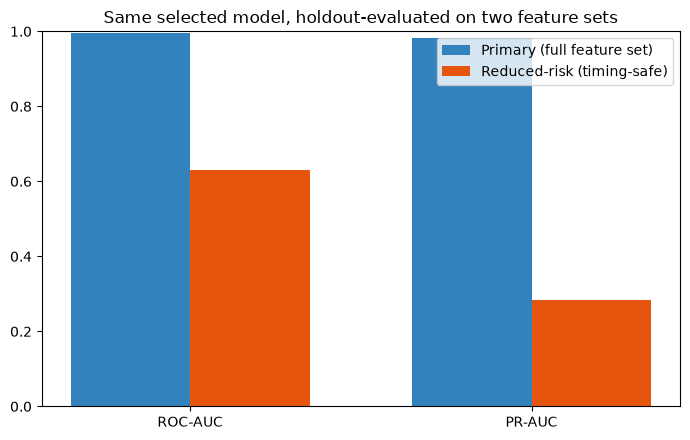

In [107]:
fig, ax = plt.subplots(figsize=(7, 4.5))
compare_metrics = ["roc_auc", "pr_auc"]
x_positions = np.arange(len(compare_metrics))
bar_width = 0.35
primary_values = [primary_holdout_metrics_for_comparison[metric] for metric in compare_metrics]
reduced_values = [reduced_risk_holdout_metrics[metric] for metric in compare_metrics]
ax.bar(x_positions - bar_width / 2, primary_values, bar_width, label="Primary (full feature set)", color="#3182bd")
ax.bar(x_positions + bar_width / 2, reduced_values, bar_width, label="Reduced-risk (timing-safe)", color="#e6550d")
ax.set_xticks(x_positions)
ax.set_xticklabels(["ROC-AUC", "PR-AUC"])
ax.set_ylim(0, 1)
ax.set_title("Same selected model, holdout-evaluated on two feature sets")
ax.legend()
plt.tight_layout()
plt.show()

### 12.4 Bootstrap uncertainty

**Bootstrap settings**

In [108]:
BOOTSTRAP_ITERATIONS = 1000
BOOTSTRAP_RANDOM_STATE = 2027


**Calibration statistics**

In [109]:
def calibration_statistics(y_true, probabilities, n_bins=10):
    y_array = np.asarray(y_true, dtype=int)
    probability_array = np.clip(
        np.asarray(probabilities, dtype=float), 1e-6, 1 - 1e-6
    )
    log_odds = np.log(probability_array / (1 - probability_array)).reshape(-1, 1)
    calibration_model = LogisticRegression(C=1e6, max_iter=1000).fit(
        log_odds, y_array
    )

    bin_ids = pd.qcut(
        pd.Series(probability_array).rank(method="first"),
        q=min(n_bins, len(probability_array)), labels=False,
    )
    calibration_frame = pd.DataFrame({
        "y": y_array, "p": probability_array, "bin": bin_ids,
    })
    bin_summary = calibration_frame.groupby("bin", observed=True).agg(
        customers=("y", "size"),
        observed_rate=("y", "mean"),
        predicted_rate=("p", "mean"),
    )
    ece = np.average(
        np.abs(bin_summary["observed_rate"] - bin_summary["predicted_rate"]),
        weights=bin_summary["customers"],
    )
    return {
        "calibration_intercept": float(calibration_model.intercept_[0]),
        "calibration_slope": float(calibration_model.coef_[0, 0]),
        "expected_calibration_error": float(ece),
    }


**Complete metric set**

In [110]:
def complete_prediction_metrics(y_true, probabilities):
    y_array = np.asarray(y_true, dtype=int)
    probability_array = np.asarray(probabilities, dtype=float)
    predictions = probability_array >= 0.50
    top_precision, top_recall, top_lift = top_capacity_metrics(
        y_array, probability_array, CAMPAIGN_CAPACITY
    )
    metrics = {
        "accuracy_at_0.50": accuracy_score(y_array, predictions),
        "roc_auc": roc_auc_score(y_array, probability_array),
        "pr_auc": average_precision_score(y_array, probability_array),
        "brier": brier_score_loss(y_array, probability_array),
        "log_loss": log_loss(y_array, probability_array),
        "precision_at_0.50": precision_score(
            y_array, predictions, zero_division=0
        ),
        "recall_at_0.50": recall_score(
            y_array, predictions, zero_division=0
        ),
        "f1_at_0.50": f1_score(y_array, predictions, zero_division=0),
        "top_10pct_precision": top_precision,
        "top_10pct_recall": top_recall,
        "top_10pct_lift": top_lift,
    }
    metrics.update(calibration_statistics(y_array, probability_array))
    return metrics


**Run the bootstrap**

In [111]:
holdout_point_metrics = complete_prediction_metrics(
    y_test, selected_probability_probabilities
)
bootstrap_rng = np.random.default_rng(BOOTSTRAP_RANDOM_STATE)
y_test_array = np.asarray(y_test, dtype=int)
bootstrap_metric_rows = []
for _ in range(BOOTSTRAP_ITERATIONS):
    sample_positions = bootstrap_rng.integers(0, len(y_test_array), len(y_test_array))
    sampled_y = y_test_array[sample_positions]
    if np.unique(sampled_y).size < 2:
        continue
    sampled_probabilities = selected_probability_probabilities[sample_positions]
    bootstrap_metric_rows.append(
        complete_prediction_metrics(sampled_y, sampled_probabilities)
    )


**Confidence intervals**

In [112]:
bootstrap_metric_samples = pd.DataFrame(bootstrap_metric_rows)
bootstrap_metric_summary = pd.DataFrame({
    "estimate": pd.Series(holdout_point_metrics),
    "ci_95_low": bootstrap_metric_samples.quantile(0.025),
    "ci_95_high": bootstrap_metric_samples.quantile(0.975),
})
display(bootstrap_metric_summary.round(4))


,estimate,ci_95_low,ci_95_high
accuracy_at_0.50,0.9796,0.9735,0.9852
roc_auc,0.9960,0.9942,0.9976
pr_auc,0.9822,0.9736,0.9892
brier,0.0167,0.0127,0.0208
log_loss,0.0592,0.0468,0.0734
precision_at_0.50,0.9471,0.9225,0.9688
recall_at_0.50,0.9299,0.9029,0.9560
f1_at_0.50,0.9384,0.9196,0.9561
top_10pct_precision,1.0000,0.9784,1.0000
top_10pct_recall,0.6000,0.5474,0.6516


### 12.5 Calibration by risk decile

**Form risk deciles**

In [113]:
calibration_deciles = pd.DataFrame({
    "observed": np.asarray(y_test, dtype=int),
    "predicted": selected_probability_probabilities,
})
calibration_deciles["risk_decile"] = pd.qcut(
    calibration_deciles["predicted"].rank(method="first"),
    q=10, labels=range(1, 11),
)
calibration_decile_summary = calibration_deciles.groupby(
    "risk_decile", observed=True
).agg(
    customers=("observed", "size"),
    churners=("observed", "sum"),
    observed_churn_rate=("observed", "mean"),
    average_predicted_risk=("predicted", "mean"),
).reset_index()


**Wilson intervals and gaps**

In [114]:
z_95 = norm.ppf(0.975)
n_decile = calibration_decile_summary["customers"].astype(float)
p_decile = calibration_decile_summary["observed_churn_rate"].astype(float)
wilson_denominator = 1 + z_95 ** 2 / n_decile
wilson_center = (p_decile + z_95 ** 2 / (2 * n_decile)) / wilson_denominator
wilson_half_width = (
    z_95
    * np.sqrt(
        p_decile * (1 - p_decile) / n_decile
        + z_95 ** 2 / (4 * n_decile ** 2)
    )
    / wilson_denominator
)
calibration_decile_summary["observed_ci_95_low"] = (
    wilson_center - wilson_half_width
)
calibration_decile_summary["observed_ci_95_high"] = (
    wilson_center + wilson_half_width
)
calibration_decile_summary["calibration_gap"] = (
    calibration_decile_summary["average_predicted_risk"]
    - calibration_decile_summary["observed_churn_rate"]
)


**Display the calibration table**

In [115]:
display(calibration_decile_summary.round(4))


,risk_decile,customers,churners,observed_churn_rate,average_predicted_risk,observed_ci_95_low,observed_ci_95_high,calibration_gap
0,1,231,0,0.0000,0.0000,0.0000,0.0164,0.0000
1,2,230,0,0.0000,0.0001,0.0000,0.0164,0.0001
2,3,231,0,0.0000,0.0002,0.0000,0.0164,0.0002
3,4,230,0,0.0000,0.0003,0.0000,0.0164,0.0003
4,5,231,0,0.0000,0.0005,0.0000,0.0164,0.0005
5,6,230,0,0.0000,0.0010,0.0000,0.0164,0.0010
6,7,230,1,0.0043,0.0028,0.0008,0.0242,-0.0016
7,8,231,5,0.0216,0.0253,0.0093,0.0497,0.0036
8,9,230,148,0.6435,0.6343,0.5797,0.7026,-0.0092
9,10,231,231,1.0000,0.9949,0.9836,1.0000,-0.0051


**Plot calibration**

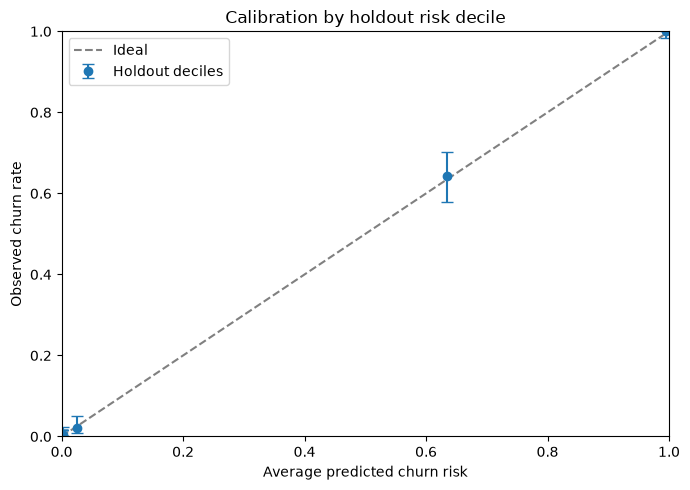

In [116]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.errorbar(
    calibration_decile_summary["average_predicted_risk"],
    calibration_decile_summary["observed_churn_rate"],
    yerr=[
        np.maximum(
            calibration_decile_summary["observed_churn_rate"]
            - calibration_decile_summary["observed_ci_95_low"],
            0,
        ),
        np.maximum(
            calibration_decile_summary["observed_ci_95_high"]
            - calibration_decile_summary["observed_churn_rate"],
            0,
        ),
    ],
    fmt="o", capsize=4, label="Holdout deciles",
)
ax.plot([0, 1], [0, 1], linestyle="--", color="grey", label="Ideal")
ax.set(
    xlabel="Average predicted churn risk",
    ylabel="Observed churn rate",
    title="Calibration by holdout risk decile",
    xlim=(0, 1), ylim=(0, 1),
)
ax.legend()
plt.tight_layout()
plt.show()


### 12.6 Final holdout charts

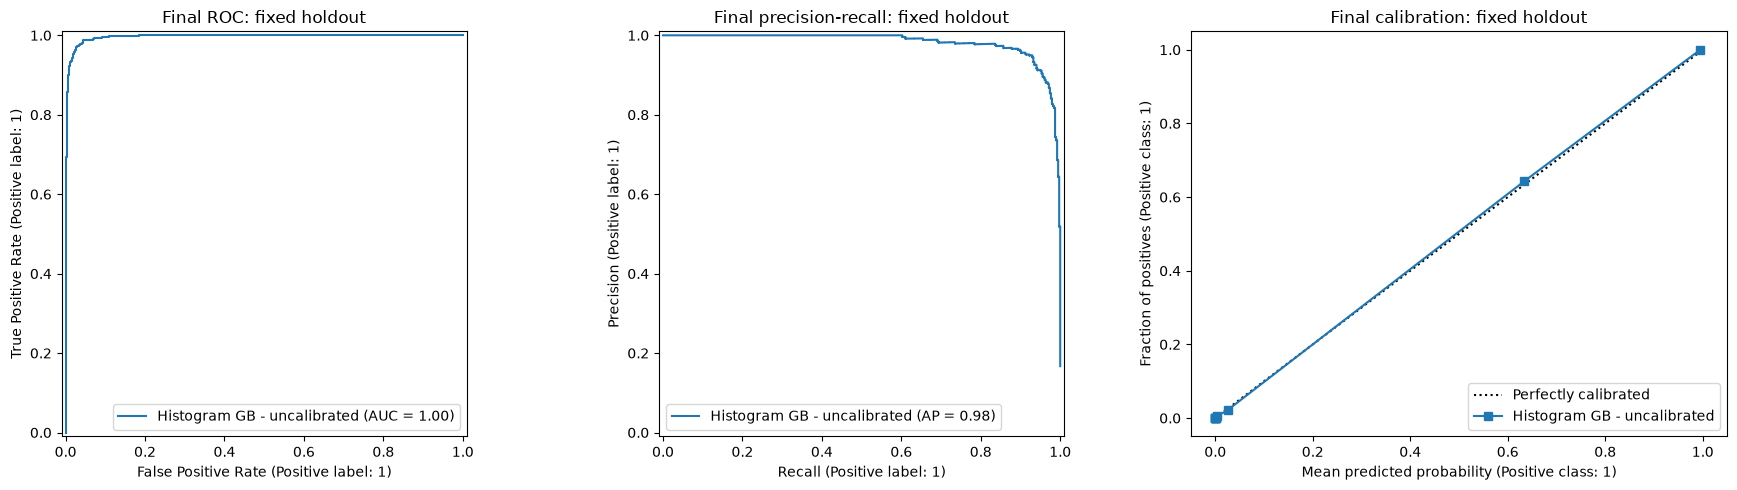

In [117]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
RocCurveDisplay.from_predictions(
    y_test, selected_probability_probabilities,
    name=selected_probability_model_name, ax=axes[0],
)
PrecisionRecallDisplay.from_predictions(
    y_test, selected_probability_probabilities,
    name=selected_probability_model_name, ax=axes[1],
)
CalibrationDisplay.from_predictions(
    y_test, selected_probability_probabilities, n_bins=10, strategy="quantile",
    name=selected_probability_model_name, ax=axes[2],
)
axes[0].set_title("Final ROC: fixed holdout")
axes[1].set_title("Final precision-recall: fixed holdout")
axes[2].set_title("Final calibration: fixed holdout")
plt.tight_layout()
plt.show()


### 12.7 Holdout confusion matrix

In [118]:
selected_probability_predictions = selected_probability_probabilities >= 0.50
confusion = pd.DataFrame(
    confusion_matrix(y_test, selected_probability_predictions),
    index=["Actual existing", "Actual attrited"],
    columns=["Predicted existing", "Predicted attrited"],
)
display(confusion)


,Predicted existing,Predicted attrited
Actual existing,1900,20
Actual attrited,27,358


### 12.8 Capacity audit on the holdout

In [119]:
CAMPAIGN_CAPACITY_OPTIONS = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30]
AUDIT_CAMPAIGN_CAPACITY = CAMPAIGN_CAPACITY
capacity_rows = []
probability_order = np.argsort(-selected_probability_probabilities, kind="stable")
for capacity in CAMPAIGN_CAPACITY_OPTIONS:
    target_count = max(1, int(np.ceil(len(y_test) * capacity)))
    selected_positions = probability_order[:target_count]
    selected_churners = int(np.asarray(y_test)[selected_positions].sum())
    precision, recall, lift = top_capacity_metrics(
        y_test, selected_probability_probabilities, capacity
    )
    threshold = selected_probability_probabilities[selected_positions[-1]]
    capacity_rows.append({
        "capacity": capacity, "customers_contacted": target_count,
        "churners_captured": selected_churners, "score_threshold": threshold,
        "precision": precision, "recall": recall, "lift": lift,
    })
capacity_results = pd.DataFrame(capacity_rows)
selected_capacity_row = capacity_results.loc[
    np.isclose(capacity_results["capacity"], AUDIT_CAMPAIGN_CAPACITY)
].iloc[0]
selected_operating_threshold = float(selected_capacity_row["score_threshold"])
display(capacity_results.round(4))
print(f"Pre-declared audit capacity: {AUDIT_CAMPAIGN_CAPACITY:.0%}")
print(f"Descriptive holdout threshold at the audit capacity: {selected_operating_threshold:.4f}")
print("This threshold is not used to select the economic campaign policy.")


,capacity,customers_contacted,churners_captured,score_threshold,precision,recall,lift
0,0.05,116,116,0.9968,1.0000,0.3013,5.9870
1,0.10,231,231,0.9826,1.0000,0.6000,5.9870
2,0.15,346,335,0.7580,0.9682,0.8701,5.7967
3,0.20,461,379,0.0908,0.8221,0.9844,4.9221
4,0.25,577,383,0.0163,0.6638,0.9948,3.9740
5,0.30,692,384,0.0051,0.5549,0.9974,3.3223


Pre-declared audit capacity: 10%
Descriptive holdout threshold at the audit capacity: 0.9826
This threshold is not used to select the economic campaign policy.


### 12.9 Capacity-performance chart

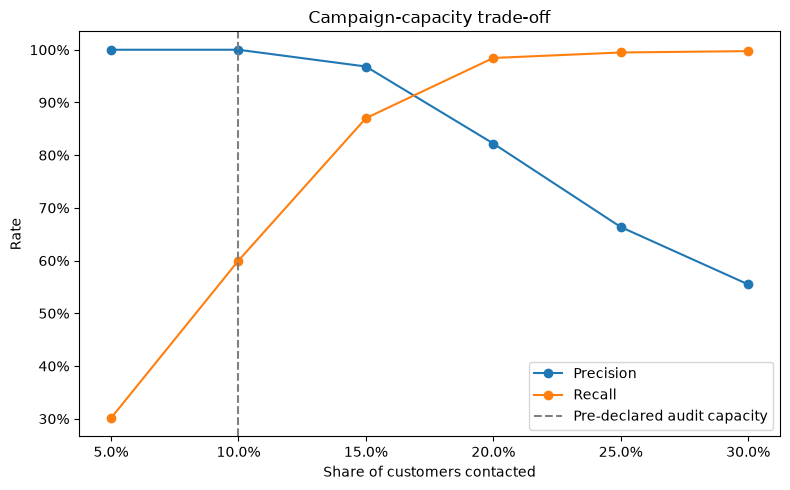

In [120]:
plt.figure(figsize=(8, 5))
plt.plot(capacity_results["capacity"], capacity_results["precision"], marker="o", label="Precision")
plt.plot(capacity_results["capacity"], capacity_results["recall"], marker="o", label="Recall")
plt.axvline(AUDIT_CAMPAIGN_CAPACITY, color="grey", linestyle="--", label="Pre-declared audit capacity")
plt.gca().xaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0))
plt.gca().yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0))
plt.xlabel("Share of customers contacted")
plt.ylabel("Rate")
plt.title("Campaign-capacity trade-off")
plt.legend()
plt.tight_layout()
plt.show()


### 12.10 Gender fairness audit

In [121]:
fairness_data = modeling_base.loc[X_test.index, ["Gender_clean", "Churned"]].copy()
fairness_data["score"] = selected_probability_probabilities
fairness_data["selected_for_outreach"] = fairness_data["score"].ge(selected_operating_threshold)
fairness_rows = []
for gender_group, group in fairness_data.groupby("Gender_clean", observed=True):
    y_group = group["Churned"].astype(int)
    selected_group = group["selected_for_outreach"].astype(int)
    tn, fp, fn, tp = confusion_matrix(y_group, selected_group, labels=[0, 1]).ravel()
    fairness_rows.append({
        "gender_group": str(gender_group),
        "customers": len(group), "churners": int(y_group.sum()),
        "observed_churn_rate": y_group.mean(),
        "average_score": group["score"].mean(),
        "calibration_gap": group["score"].mean() - y_group.mean(),
        "selection_rate": selected_group.mean(),
        "precision": tp / (tp + fp) if (tp + fp) else np.nan,
        "recall_tpr": tp / (tp + fn) if (tp + fn) else np.nan,
        "false_positive_rate": fp / (fp + tn) if (fp + tn) else np.nan,
        "roc_auc": roc_auc_score(y_group, group["score"]) if y_group.nunique() == 2 else np.nan,
        "pr_auc": average_precision_score(y_group, group["score"]) if y_group.nunique() == 2 else np.nan,
        "brier": brier_score_loss(y_group, group["score"]),
    })
fairness_results = pd.DataFrame(fairness_rows).sort_values("gender_group").reset_index(drop=True)
display(fairness_results.round(4))



,gender_group,customers,churners,observed_churn_rate,average_score,calibration_gap,selection_rate,precision,recall_tpr,false_positive_rate,roc_auc,pr_auc,brier
0,F,1187,197,0.1660,0.1676,0.0016,0.1087,1.0,0.6548,0.0,0.9960,0.9808,0.0186
1,M,1072,174,0.1623,0.1586,-0.0038,0.0858,1.0,0.5287,0.0,0.9959,0.9833,0.0151
2,Missing,46,14,0.3043,0.2989,-0.0054,0.2174,1.0,0.7143,0.0,1.0000,1.0000,0.0025


**Compare gender groups**

In [122]:
reported_gender_results = fairness_results.loc[fairness_results["gender_group"].isin(["F", "M"])]
fairness_gap_metrics = [
    "selection_rate", "precision", "recall_tpr", "false_positive_rate",
    "roc_auc", "pr_auc", "brier", "calibration_gap",
]
fairness_gap_summary = pd.DataFrame({
    "metric": fairness_gap_metrics,
    "max_minus_min_F_M": [
        reported_gender_results[metric].max() - reported_gender_results[metric].min()
        for metric in fairness_gap_metrics
    ],
})
display(fairness_gap_summary.round(4))


,metric,max_minus_min_F_M
0,selection_rate,0.0229
1,precision,0.0000
2,recall_tpr,0.1261
3,false_positive_rate,0.0000
4,roc_auc,0.0001
5,pr_auc,0.0025
6,brier,0.0036
7,calibration_gap,0.0054


### 12.11 Leakage and timing audit

In [123]:
assert set(MODEL_FEATURES).isdisjoint(FORBIDDEN_DIRECT_LEAKAGE)
assert X_train.index.intersection(X_test.index).empty
assert development_base.index.equals(X_train.index)
assert holdout_base.index.equals(X_test.index)

preprocessor_blocks = {
    name: transformer for name, transformer, _ in preprocessor.transformers
}
numeric_steps = set(preprocessor_blocks["numeric"].named_steps)
categorical_steps = set(preprocessor_blocks["categorical"].named_steps)
assert {"imputer", "scaler"}.issubset(numeric_steps)
assert {"imputer", "encoder"}.issubset(categorical_steps)

observation_timestamp_available = any(
    column in raw.columns for column in ["Observation_Date", "Snapshot_Date", "As_of_Date"]
)
churn_event_timestamp_available = any(
    column in raw.columns for column in ["Churn_Date", "Attrition_Date", "Closure_Date"]
)


**Display the audit**

In [124]:
timing_audit = pd.DataFrame([
        {
            "area": "Economic policy selection",
            "status": "Pass",
            "evidence_or_action": "Capacity selected on development OOF predictions; frozen before holdout economics.",
        },
        {
            "area": "Challenger adoption",
            "status": "Pass",
            "evidence_or_action": "Pre-declared development-CV guardrails; holdout does not choose the model.",
        },
    {"area": "Identifier and target columns", "status": "Pass",
     "evidence_or_action": "Customer ID, raw/clean churn labels, DOB, and target are excluded."},
    {"area": "Development/holdout overlap", "status": "Pass",
     "evidence_or_action": "Frozen partitions have disjoint row indices and reconcile to all labeled rows."},
    {"area": "Target-aware exploration", "status": "Pass",
     "evidence_or_action": "EDA, driver analysis, and segment comparisons use development_base only."},
    {"area": "Imputation, scaling, and encoding", "status": "Pass",
     "evidence_or_action": "All learned preprocessing is inside Pipeline/ColumnTransformer and fitted per fold."},
    {"area": "Treatment and feature decisions", "status": "Pass",
     "evidence_or_action": "Sensitivity and ablation tests use development cross-validation only."},
    {"area": "Model and calibration selection", "status": "Pass",
     "evidence_or_action": "Candidate selection uses development CV; only the fixed winner is evaluated on holdout."},
    {"area": "Existing-customer prioritization", "status": "Pass",
     "evidence_or_action": "Each labelled customer receives a nested out-of-fold probability; the full-fit model is reserved for genuinely unseen or unlabeled records."},
    {"area": "Observation timestamp (explicit source field)",
     "status": "Available" if observation_timestamp_available else "Unavailable",
     "evidence_or_action": "No Observation_Date/Snapshot_Date/As_of_Date column is present in the source file."},
    {"area": "Observation timestamp (internal inference from Age/DOB)",
     "status": "Inferred - unconfirmed" if AGE_DOB_INFERRED_WINDOW else "Unavailable",
     "evidence_or_action": (
         f"{AGE_DOB_BEST_AGREEMENT:,}/{AGE_DOB_CHECKED_ROWS:,} plausible-age records "
         f"({AGE_DOB_BEST_AGREEMENT / AGE_DOB_CHECKED_ROWS:.1%}) agree with a single window, "
         f"{AGE_DOB_INFERRED_WINDOW[0]} to {AGE_DOB_INFERRED_WINDOW[1]} (exclusive); not confirmed by a "
         "data dictionary or source system, and does not establish the churn-event timestamp."
     ) if AGE_DOB_INFERRED_WINDOW else "No single window is jointly consistent with Age and Date_of_birth."},
    {"area": "Churn-event timestamp",
     "status": "Available" if churn_event_timestamp_available else "Unavailable",
     "evidence_or_action": "Required to define a future prediction horizon."},
    {"area": "Transaction and 12-month behavior windows", "status": "Unresolved - high priority",
     "evidence_or_action": "Confirm every feature window ends before the churn outcome window."},
    {"area": "Reduced-risk benchmark", "status": "Completed",
     "evidence_or_action": (
         f"Training CV PR-AUC "
         f"{timing_sensitivity_results.set_index('treatment').loc['Primary feature set', 'cv_pr_auc']:.3f} "
         f"-> {timing_sensitivity_results.set_index('treatment').loc['Reduced-risk profile/static set', 'cv_pr_auc']:.3f}; "
         f"the selected model holdout-evaluated once on both feature sets confirms it: primary "
         f"{primary_holdout_metrics_for_comparison['pr_auc']:.3f} vs. reduced-risk "
         f"{reduced_risk_holdout_metrics['pr_auc']:.3f} PR-AUC."
     )},
    {"area": "Validation split", "status": "Limitation",
     "evidence_or_action": "Random stratification is used because time-aware validation is impossible."},
])
display(timing_audit)
if not (observation_timestamp_available and churn_event_timestamp_available):
    print("Temporal leakage cannot be ruled out from this snapshot; out-of-time validation is required before deployment.")


,area,status,evidence_or_action
0,Economic policy selection,Pass,Capacity selected on development OOF predictio...
1,Challenger adoption,Pass,Pre-declared development-CV guardrails; holdou...
2,Identifier and target columns,Pass,"Customer ID, raw/clean churn labels, DOB, and ..."
3,Development/holdout overlap,Pass,Frozen partitions have disjoint row indices an...
4,Target-aware exploration,Pass,"EDA, driver analysis, and segment comparisons ..."
5,"Imputation, scaling, and encoding",Pass,All learned preprocessing is inside Pipeline/C...
6,Treatment and feature decisions,Pass,Sensitivity and ablation tests use development...
7,Model and calibration selection,Pass,Candidate selection uses development CV; only ...
8,Existing-customer prioritization,Pass,Each labelled customer receives a nested out-o...
9,Observation timestamp (explicit source field),Unavailable,No Observation_Date/Snapshot_Date/As_of_Date c...


Temporal leakage cannot be ruled out from this snapshot; out-of-time validation is required before deployment.


## 13. Explain the model

### 13.1 Permutation importance

In [323]:
permutation = permutation_importance(
    selected_probability_model, X_test, y_test, scoring="average_precision",
    n_repeats=8, random_state=RANDOM_STATE, n_jobs=1,
)
permutation_drivers = pd.DataFrame({
    "feature": MODEL_FEATURES,
    "domain": [DOMAIN_BY_FEATURE[feature] for feature in MODEL_FEATURES],
    "importance_mean": permutation.importances_mean,
    "importance_sd": permutation.importances_std,
}).sort_values("importance_mean", ascending=False).reset_index(drop=True)
display(permutation_drivers.round(4))



,feature,domain,importance_mean,importance_sd
0,Total_Trans_Ct,Financial,0.4506,0.0204
1,Total_Trans_Amt,Financial,0.3032,0.0137
2,Total_Relationship_Count,Behavioral,0.0361,0.0062
3,Total_Amt_Chng_Q4_Q1,Financial,0.0334,0.0028
4,Total_Revolving_Bal,Financial,0.0300,0.0042
5,Total_Ct_Chng_Q4_Q1,Financial,0.0164,0.0026
6,Months_Inactive_12_mon,Behavioral,0.0090,0.0022
7,Age_clean,Demographic,0.0079,0.0010
8,Contacts_Count_12_mon,Behavioral,0.0068,0.0017
9,Credit_Limit_clean,Financial,0.0058,0.0013


### 13.2 Grouped importance and domain ablation

**Define feature groups**

In [324]:
GROUPED_DRIVER_FEATURES = {
    "Demographic domain": [
        feature for feature in FEATURE_GROUPS["Demographic"]
        if feature in MODEL_FEATURES
    ],
    "Financial domain": [
        feature for feature in FEATURE_GROUPS["Financial"]
        if feature in MODEL_FEATURES
    ],
    "Behavioral domain": [
        feature for feature in FEATURE_GROUPS["Behavioral"]
        if feature in MODEL_FEATURES
    ],
    "Transaction activity cluster": [
        "Total_Trans_Amt", "Total_Trans_Ct",
        "Total_Amt_Chng_Q4_Q1", "Total_Ct_Chng_Q4_Q1",
    ],
    "Credit usage cluster": [
        "Credit_Limit_clean", "Total_Revolving_Bal",
        "Avg_Utilization_Ratio",
    ],
    "Engagement cluster": [
        "Total_Relationship_Count", "Months_Inactive_12_mon",
        "Contacts_Count_12_mon",
    ],
}


**Grouped permutation importance**

In [325]:
GROUP_PERMUTATION_REPEATS = 20
grouped_rng = np.random.default_rng(2028)
grouped_baseline_pr_auc = average_precision_score(
    y_test, selected_probability_probabilities
)
grouped_importance_rows = []
for group_name, group_features in GROUPED_DRIVER_FEATURES.items():
    repeat_drops = []
    for _ in range(GROUP_PERMUTATION_REPEATS):
        shuffled_positions = grouped_rng.permutation(len(X_test))
        permuted_X = X_test.copy()
        permuted_X.loc[:, group_features] = (
            X_test.iloc[shuffled_positions][group_features].to_numpy()
        )
        permuted_probabilities = selected_probability_model.predict_proba(
            permuted_X
        )[:, 1]
        repeat_drops.append(
            grouped_baseline_pr_auc
            - average_precision_score(y_test, permuted_probabilities)
        )
    grouped_importance_rows.append({
        "feature_group": group_name,
        "features_in_group": len(group_features),
        "pr_auc_drop_mean": np.mean(repeat_drops),
        "pr_auc_drop_sd": np.std(repeat_drops, ddof=1),
    })


**Assemble grouped results**

In [326]:
grouped_permutation_importance = pd.DataFrame(
    grouped_importance_rows
).sort_values("pr_auc_drop_mean", ascending=False).reset_index(drop=True)


**Leave-one-domain-out CV**

In [327]:
domain_ablation_rows = []
for excluded_domain in [None, "Demographic", "Financial", "Behavioral"]:
    excluded_features = set(
        FEATURE_GROUPS.get(excluded_domain, [])
    ) if excluded_domain else set()
    numeric_features = [
        feature for feature in MODEL_NUMERIC_FEATURES
        if feature not in excluded_features
    ]
    categorical_features = [
        feature for feature in MODEL_CATEGORICAL_FEATURES
        if feature not in excluded_features
    ]
    ablation_features = numeric_features + categorical_features
    ablation_candidate = build_probability_candidate(
        selected_probability_model_name,
        numeric_features=numeric_features,
        categorical_features=categorical_features,
    )
    ablation_scores = cross_validate(
        ablation_candidate,
        development_base[ablation_features], y_train,
        cv=cv,
        scoring={
            "pr_auc": "average_precision",
            "roc_auc": "roc_auc",
            "neg_brier": "neg_brier_score",
        },
        n_jobs=1, error_score="raise",
    )
    domain_ablation_rows.append({
        "treatment": (
            "All model domains"
            if excluded_domain is None
            else f"Exclude {excluded_domain.lower()} domain"
        ),
        "features": len(ablation_features),
        "cv_pr_auc": ablation_scores["test_pr_auc"].mean(),
        "cv_pr_auc_sd": ablation_scores["test_pr_auc"].std(ddof=1),
        "cv_roc_auc": ablation_scores["test_roc_auc"].mean(),
        "cv_brier": -ablation_scores["test_neg_brier"].mean(),
    })


**Domain-ablation changes**

In [328]:
domain_ablation_results = pd.DataFrame(domain_ablation_rows)
full_domain_pr_auc = domain_ablation_results.loc[
    domain_ablation_results["treatment"].eq("All model domains"),
    "cv_pr_auc",
].iloc[0]
domain_ablation_results["pr_auc_change_vs_all"] = (
    domain_ablation_results["cv_pr_auc"] - full_domain_pr_auc
)


**Display driver checks**

In [329]:
display(grouped_permutation_importance.round(4))
display(domain_ablation_results.sort_values("cv_pr_auc", ascending=False).round(4))


,feature_group,features_in_group,pr_auc_drop_mean,pr_auc_drop_sd
0,Financial domain,9,0.7771,0.0113
1,Transaction activity cluster,4,0.7090,0.0161
2,Engagement cluster,3,0.0712,0.0064
3,Behavioral domain,3,0.0699,0.0058
4,Credit usage cluster,3,0.0544,0.0068
5,Demographic domain,4,0.0097,0.0019


,treatment,features,cv_pr_auc,cv_pr_auc_sd,cv_roc_auc,cv_brier,pr_auc_change_vs_all
0,All model domains,16,0.9738,0.0068,0.9937,0.0207,0.0000
1,Exclude demographic domain,12,0.9631,0.0091,0.9916,0.0254,-0.0107
3,Exclude behavioral domain,13,0.9627,0.0052,0.9906,0.0254,-0.0111
2,Exclude financial domain,7,0.4751,0.0210,0.7697,0.1145,-0.4987


**Plot grouped driver evidence**

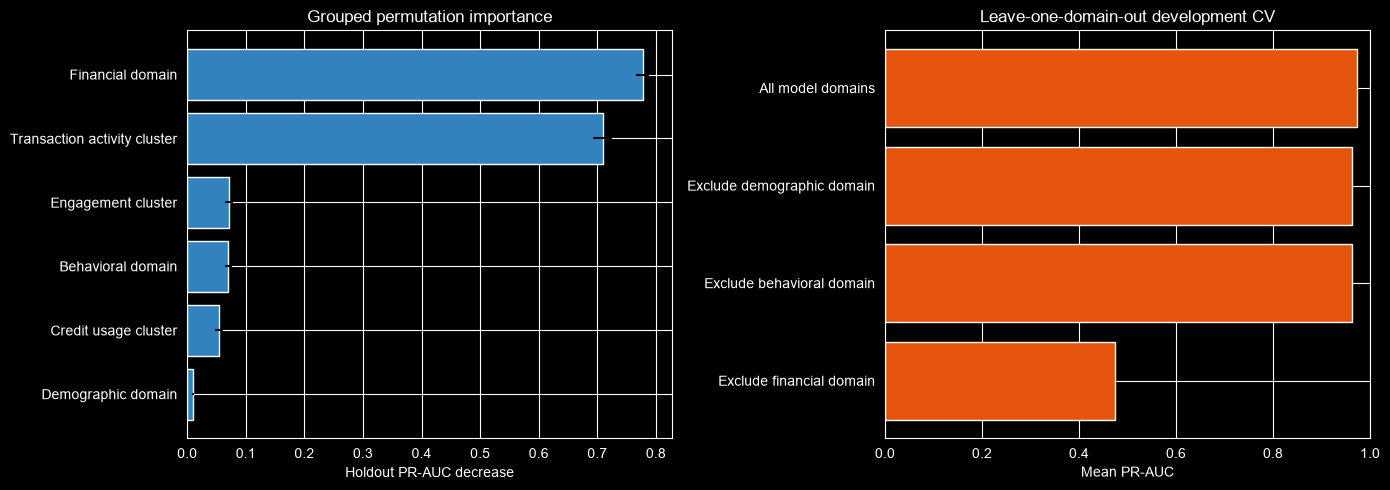

In [330]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
grouped_plot = grouped_permutation_importance.sort_values("pr_auc_drop_mean")
axes[0].barh(
    grouped_plot["feature_group"], grouped_plot["pr_auc_drop_mean"],
    xerr=grouped_plot["pr_auc_drop_sd"], color="#3182bd",
)
axes[0].set(
    title="Grouped permutation importance",
    xlabel="Holdout PR-AUC decrease",
)
ablation_plot = domain_ablation_results.sort_values("cv_pr_auc")
axes[1].barh(
    ablation_plot["treatment"], ablation_plot["cv_pr_auc"],
    color="#e6550d",
)
axes[1].set(
    title="Leave-one-domain-out development CV",
    xlabel="Mean PR-AUC", xlim=(0, 1),
)
plt.tight_layout()
plt.show()


### 13.3 Importance chart

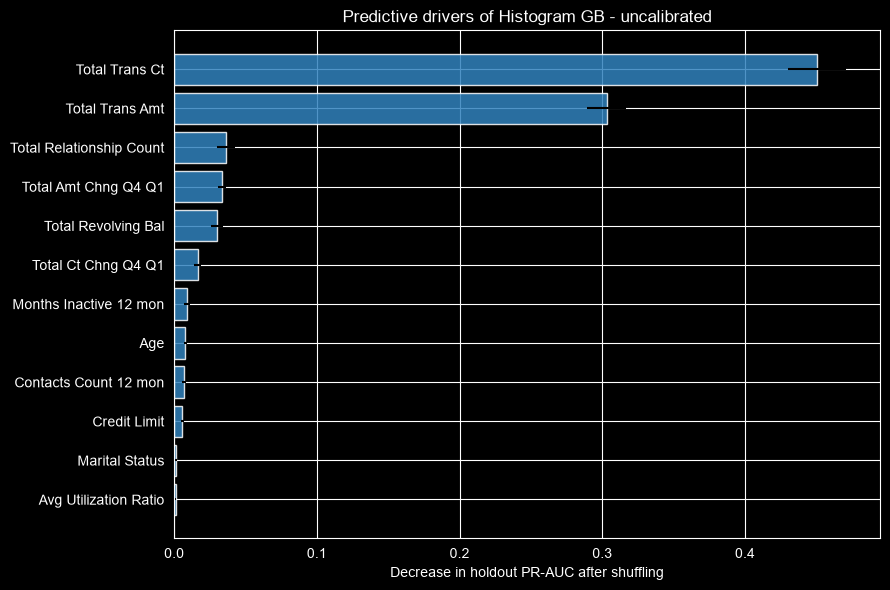

In [331]:
top_permutation = permutation_drivers.head(12).sort_values("importance_mean")
plt.figure(figsize=(9, 6))
plt.barh(
    top_permutation["feature"].str.replace("_clean", "", regex=False).str.replace("_", " ", regex=False),
    top_permutation["importance_mean"],
    xerr=top_permutation["importance_sd"], color="#3182bd", alpha=0.85,
)
plt.xlabel("Decrease in holdout PR-AUC after shuffling")
plt.title(f"Predictive drivers of {selected_probability_model_name}")
plt.tight_layout()
plt.show()



### 13.4 Logistic coefficients, if selected

In [332]:
final_model_step = (
    selected_probability_model.named_steps["model"]
    if hasattr(selected_probability_model, "named_steps")
    else None
)

if isinstance(final_model_step, LogisticRegression):
    feature_names = selected_probability_model.named_steps["preprocess"].get_feature_names_out()
    coefficients = final_model_step.coef_[0]
    coefficient_table = pd.DataFrame({
        "transformed_feature": feature_names,
        "coefficient": coefficients,
        "odds_ratio": np.exp(coefficients),
    })
    coefficient_table["abs_coefficient"] = coefficient_table["coefficient"].abs()
    display(coefficient_table.sort_values("abs_coefficient", ascending=False).head(25).round(3))
else:
    print(
        f"Selected probability model is '{selected_probability_model_name}', which does not "
        "expose a single signed-coefficient vector (it is a tree ensemble, or a calibrated "
        "wrapper around one). See the permutation-importance tables in 13.1-13.3 for its "
        "predictive drivers instead."
    )

Selected probability model is 'Histogram GB - uncalibrated', which does not expose a single signed-coefficient vector (it is a tree ensemble, or a calibrated wrapper around one). See the permutation-importance tables in 13.1-13.3 for its predictive drivers instead.


## 14. Prioritize existing customers

### 14.1 Out-of-fold scores

**Generate OOF score sets**

In [333]:
PRIORITY_OOF_REPEATS = 3
priority_oof_scores = pd.DataFrame(index=X.index)
for repeat_number in range(PRIORITY_OOF_REPEATS):
    repeat_priority_cv = StratifiedKFold(
        n_splits=5, shuffle=True,
        random_state=RANDOM_STATE + repeat_number,
    )
    priority_oof_scores[f"repeat_{repeat_number + 1}"] = cross_val_predict(
        clone(selected_probability_pipeline), X, y,
        cv=repeat_priority_cv, method="predict_proba", n_jobs=1,
    )[:, 1]


**Average repeated scores**

In [334]:
oof_probability = priority_oof_scores.mean(axis=1).rename(
    "churn_probability_oof_mean"
)
oof_probability_sd = priority_oof_scores.std(axis=1, ddof=1).rename(
    "churn_probability_oof_sd"
)


**Fit the inference model**

In [335]:
final_model = clone(selected_probability_pipeline).fit(X, y)

existing_population = customer_base.loc[
    customer_base["Attrition_Flag_clean"].eq("Existing Customer")
].copy()
existing_population["churn_probability_full_fit"] = final_model.predict_proba(
    existing_population[MODEL_FEATURES]
)[:, 1]
existing_population["churn_probability"] = oof_probability.reindex(
    existing_population.index
)
existing_population["churn_probability_oof_sd"] = oof_probability_sd.reindex(
    existing_population.index
)
assert existing_population["churn_probability"].notna().all()


**High-risk selection frequency**

In [336]:
high_priority_frequency = pd.Series(
    0.0, index=existing_population.index,
    name="high_priority_frequency",
)
for score_column in priority_oof_scores.columns:
    repeat_existing_scores = priority_oof_scores.loc[
        existing_population.index, score_column
    ]
    repeat_high_count = max(
        1, int(np.ceil(len(repeat_existing_scores) * 0.10))
    )
    repeat_high_index = repeat_existing_scores.nlargest(
        repeat_high_count
    ).index
    high_priority_frequency.loc[repeat_high_index] += 1 / PRIORITY_OOF_REPEATS
existing_population["high_priority_frequency"] = high_priority_frequency


**Assign risk bands**

In [337]:
existing_population["risk_percentile"] = existing_population[
    "churn_probability"
].rank(method="first", pct=True)
existing_population["risk_band"] = np.select(
    [
        existing_population["risk_percentile"].ge(0.90),
        existing_population["risk_percentile"].ge(0.70),
    ],
    ["High", "Medium"],
    default="Low",
)
existing_population["score_method"] = (
    "Mean of three repeated five-fold OOF probabilities"
)


**Full-fit comparison bands**

In [338]:
existing_population["full_fit_risk_percentile"] = existing_population[
    "churn_probability_full_fit"
].rank(method="first", pct=True)
existing_population["full_fit_risk_band"] = np.select(
    [
        existing_population["full_fit_risk_percentile"].ge(0.90),
        existing_population["full_fit_risk_percentile"].ge(0.70),
    ],
    ["High", "Medium"],
    default="Low",
)


### 14.2 OOF vs. full-fit comparison

**Overlap at the top**

In [339]:
full_fit_high_index = set(existing_population.index[
    existing_population["full_fit_risk_band"].eq("High")
])
oof_high_index = set(existing_population.index[
    existing_population["risk_band"].eq("High")
])
high_overlap = len(full_fit_high_index & oof_high_index)
high_union = len(full_fit_high_index | oof_high_index)


**Summarize score differences**

In [340]:
oof_priority_diagnostics = pd.Series({
    "labelled_existing_customers": len(existing_population),
    "spearman_rank_correlation": existing_population[
        "churn_probability_full_fit"
    ].corr(existing_population["churn_probability"], method="spearman"),
    "mean_absolute_probability_change": (
        existing_population["churn_probability"]
        - existing_population["churn_probability_full_fit"]
    ).abs().mean(),
    "mean_full_fit_probability": existing_population[
        "churn_probability_full_fit"
    ].mean(),
    "mean_oof_probability": existing_population["churn_probability"].mean(),
    "mean_customer_oof_score_sd": existing_population[
        "churn_probability_oof_sd"
    ].mean(),
    "high_band_selected_in_all_oof_repeats": existing_population.loc[
        existing_population["risk_band"].eq("High"),
        "high_priority_frequency",
    ].eq(1.0).sum(),
    "high_band_full_consensus_rate": existing_population.loc[
        existing_population["risk_band"].eq("High"),
        "high_priority_frequency",
    ].eq(1.0).mean(),
    "high_priority_customers_each_method": len(oof_high_index),
    "high_priority_overlap_customers": high_overlap,
    "high_priority_overlap_rate": high_overlap / len(oof_high_index),
    "high_priority_jaccard": high_overlap / high_union,
    "customers_changing_risk_band": existing_population[
        "risk_band"
    ].ne(existing_population["full_fit_risk_band"]).sum(),
    "risk_band_change_rate": existing_population[
        "risk_band"
    ].ne(existing_population["full_fit_risk_band"]).mean(),
}, name="value")
display(oof_priority_diagnostics.to_frame().round(4))


,value
labelled_existing_customers,9600.0000
spearman_rank_correlation,0.9496
mean_absolute_probability_change,0.0119
mean_full_fit_probability,0.0071
mean_oof_probability,0.0180
mean_customer_oof_score_sd,0.0068
high_band_selected_in_all_oof_repeats,694.0000
high_band_full_consensus_rate,0.7222
high_priority_customers_each_method,961.0000
high_priority_overlap_customers,814.0000


**Risk-band transition table**

In [341]:
risk_band_order = ["High", "Medium", "Low"]
risk_band_transition = pd.crosstab(
    existing_population["full_fit_risk_band"],
    existing_population["risk_band"],
).reindex(index=risk_band_order, columns=risk_band_order, fill_value=0)
display(risk_band_transition)


risk_band,High,Medium,Low
full_fit_risk_band,,,
High,814,146,1
Medium,147,1476,297
Low,0,298,6421


**Visualize the comparison**

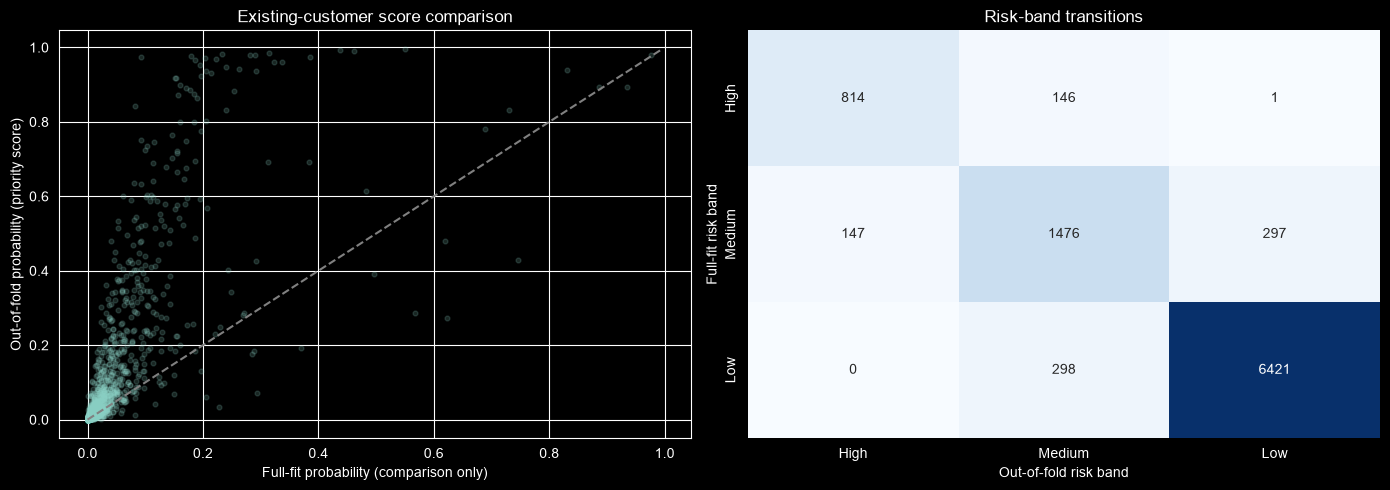

In [342]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(
    existing_population["churn_probability_full_fit"],
    existing_population["churn_probability"],
    alpha=0.18,
    s=12,
)
score_limit = max(
    existing_population["churn_probability_full_fit"].max(),
    existing_population["churn_probability"].max(),
)
axes[0].plot([0, score_limit], [0, score_limit], linestyle="--", color="grey")
axes[0].set(
    xlabel="Full-fit probability (comparison only)",
    ylabel="Out-of-fold probability (priority score)",
    title="Existing-customer score comparison",
)
sns.heatmap(
    risk_band_transition,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    ax=axes[1],
)
axes[1].set(
    xlabel="Out-of-fold risk band",
    ylabel="Full-fit risk band",
    title="Risk-band transitions",
)
plt.tight_layout()
plt.show()


### 14.3 Operational signals

In [343]:
signal_thresholds = {
    "low_transactions": modeling_base["Total_Trans_Ct"].quantile(0.25),
    "low_amount": modeling_base["Total_Trans_Amt"].quantile(0.25),
    "few_relationships": modeling_base["Total_Relationship_Count"].quantile(0.25),
    "high_inactivity": modeling_base["Months_Inactive_12_mon"].quantile(0.75),
    "high_contacts": modeling_base["Contacts_Count_12_mon"].quantile(0.75),
}
signal_conditions = [
    existing_population["Contacts_Count_12_mon"].ge(signal_thresholds["high_contacts"]),
    existing_population["Months_Inactive_12_mon"].ge(signal_thresholds["high_inactivity"]),
    existing_population["Total_Trans_Ct"].le(signal_thresholds["low_transactions"]),
    existing_population["Total_Trans_Amt"].le(signal_thresholds["low_amount"]),
    existing_population["Total_Relationship_Count"].le(signal_thresholds["few_relationships"]),
    existing_population["Avg_Utilization_Ratio"].eq(0),
]
signal_labels = [
    "High service-contact frequency", "Recent inactivity",
    "Low transaction frequency", "Low transaction value",
    "Few bank relationships", "No revolving utilization",
]
existing_population["operational_signal"] = np.select(
    signal_conditions, signal_labels, default="Broad multi-factor risk"
)


### 14.4 Map signals to interventions

In [344]:
intervention_map = {
    "High service-contact frequency": "Service-recovery review before any offer",
    "Recent inactivity": "Personalized re-engagement reminder",
    "Low transaction frequency": "Relevant usage or spend activation offer",
    "Low transaction value": "Review product fit and relevant benefits",
    "Few bank relationships": "Relationship-manager needs review",
    "No revolving utilization": "Card activation and benefit education",
    "Broad multi-factor risk": "Manual review of the full customer profile",
}
existing_population["suggested_intervention"] = existing_population["operational_signal"].map(intervention_map)



### 14.5 Risk-band summary

In [345]:
risk_band_summary = (
    existing_population.groupby("risk_band", observed=True)
    .agg(customers=("Customer_Number", "size"), average_score=("churn_probability", "mean"))
    .reindex(["High", "Medium", "Low"])
)
risk_band_display = risk_band_summary.copy()
risk_band_display["average_score"] = risk_band_display["average_score"].map(lambda value: f"{value:.2%}")
display(risk_band_display)



,customers,average_score
risk_band,,
High,961,16.64%
Medium,1920,0.52%
Low,6719,0.04%


### 14.6 Retention priority list

In [346]:
retention_columns = [
    "Customer_Number", "churn_probability", "churn_probability_oof_sd",
    "high_priority_frequency", "risk_band", "score_method",
    "operational_signal", "suggested_intervention",
    "Total_Trans_Ct", "Total_Trans_Amt", "Months_Inactive_12_mon",
    "Contacts_Count_12_mon", "Total_Relationship_Count",
]
retention_priority = existing_population.sort_values("churn_probability", ascending=False)[retention_columns].copy()
retention_priority_display = retention_priority.head(25).copy()
retention_priority_display["churn_probability"] = retention_priority_display["churn_probability"].map(
    lambda value: f"{value:.2%}"
)
display(retention_priority_display)


,Customer_Number,churn_probability,churn_probability_oof_sd,high_priority_frequency,risk_band,score_method,operational_signal,suggested_intervention,Total_Trans_Ct,Total_Trans_Amt,Months_Inactive_12_mon,Contacts_Count_12_mon,Total_Relationship_Count
6259,3719632083,99.58%,0.003992,1.0,High,Mean of three repeated five-fold OOF probabili...,High service-contact frequency,Service-recovery review before any offer,40,1720,2,3,3
1043,3710106783,99.39%,0.001941,1.0,High,Mean of three repeated five-fold OOF probabili...,High service-contact frequency,Service-recovery review before any offer,42,2191,3,3,4
6899,3720856683,99.15%,0.002039,1.0,High,Mean of three repeated five-fold OOF probabili...,High service-contact frequency,Service-recovery review before any offer,45,2512,3,4,6
10903,3803786658,98.60%,0.001755,1.0,High,Mean of three repeated five-fold OOF probabili...,Recent inactivity,Personalized re-engagement reminder,52,2118,3,2,3
5955,3719048133,98.21%,0.008199,1.0,High,Mean of three repeated five-fold OOF probabili...,Low transaction frequency,Relevant usage or spend activation offer,41,4862,2,2,3
10061,3789185808,98.05%,0.018200,1.0,High,Mean of three repeated five-fold OOF probabili...,Recent inactivity,Personalized re-engagement reminder,71,8352,3,2,2
12066,3827121408,97.98%,0.011526,1.0,High,Mean of three repeated five-fold OOF probabili...,Low transaction frequency,Relevant usage or spend activation offer,28,1109,2,2,2
9993,3788975808,97.86%,0.006466,1.0,High,Mean of three repeated five-fold OOF probabili...,High service-contact frequency,Service-recovery review before any offer,41,2170,3,3,6
730,3709475883,97.72%,0.002738,1.0,High,Mean of three repeated five-fold OOF probabili...,High service-contact frequency,Service-recovery review before any offer,31,902,1,3,3
8016,3759561720,97.52%,0.005392,1.0,High,Mean of three repeated five-fold OOF probabili...,High service-contact frequency,Service-recovery review before any offer,31,902,1,3,3


### 14.7 Score unlabeled customers

In [347]:
unlabeled_scores = unlabeled_base[["Customer_Number"] + MODEL_FEATURES].copy()
unlabeled_scores["churn_probability"] = final_model.predict_proba(
    unlabeled_scores[MODEL_FEATURES]
)[:, 1]

high_cutoff_full_fit = existing_population.loc[
    existing_population["full_fit_risk_band"].eq("High"),
    "churn_probability_full_fit",
].min()
medium_cutoff_full_fit = existing_population.loc[
    existing_population["full_fit_risk_band"].eq("Medium"),
    "churn_probability_full_fit",
].min()
unlabeled_scores["risk_band"] = np.select(
    [
        unlabeled_scores["churn_probability"].ge(high_cutoff_full_fit),
        unlabeled_scores["churn_probability"].ge(medium_cutoff_full_fit),
    ],
    ["High", "Medium"],
    default="Low",
)
unlabeled_scores["score_method"] = "Full-fit calibrated model; target unavailable"

unlabeled_display = unlabeled_scores[[
    "Customer_Number", "churn_probability", "risk_band", "score_method",
]].sort_values("churn_probability", ascending=False).head(20).copy()
unlabeled_display["churn_probability"] = unlabeled_display[
    "churn_probability"
].map(lambda value: f"{value:.2%}")
display(unlabeled_display)
print(
    "Modeling objects ready: model_results, permutation_drivers, "
    "retention_priority, and unlabeled_scores."
)


,Customer_Number,churn_probability,risk_band,score_method
7989,3758720311,99.95%,High,Full-fit calibrated model; target unavailable
8030,3760766873,99.95%,High,Full-fit calibrated model; target unavailable
11298,3811978342,99.95%,High,Full-fit calibrated model; target unavailable
9715,3787483539,99.95%,High,Full-fit calibrated model; target unavailable
8812,3774106813,99.75%,High,Full-fit calibrated model; target unavailable
11962,3824547680,99.75%,High,Full-fit calibrated model; target unavailable
303,3708690577,99.71%,High,Full-fit calibrated model; target unavailable
7684,3748329566,99.71%,High,Full-fit calibrated model; target unavailable
7304,3725109001,99.71%,High,Full-fit calibrated model; target unavailable
9817,3788243749,99.71%,High,Full-fit calibrated model; target unavailable


Modeling objects ready: model_results, permutation_drivers, retention_priority, and unlabeled_scores.


## 15. Campaign economics

- **Risk:** who is likely to churn?
- **Economics:** what outreach volume creates the most value?
- **Causal effectiveness:** does the intervention actually work?

### 15.1 Economic assumptions

In [348]:
CAMPAIGN_ECONOMIC_ASSUMPTIONS = pd.Series({
    "retained_value_per_incremental_customer": 1000.0,
    "contact_and_offer_cost_per_customer": 25.0,
    "incremental_retention_success_among_would_be_churners": 0.10,
    "fixed_campaign_cost": 0.0,
    "maximum_capacity": 0.30,
}, name="illustrative_value")

display(CAMPAIGN_ECONOMIC_ASSUMPTIONS.to_frame())
print("These are illustrative assumptions, not values observed in the supplied dataset.")


,illustrative_value
retained_value_per_incremental_customer,1000.0
contact_and_offer_cost_per_customer,25.0
incremental_retention_success_among_would_be_churners,0.1
fixed_campaign_cost,0.0
maximum_capacity,0.3


These are illustrative assumptions, not values observed in the supplied dataset.


### 15.2 Select the policy, then evaluate once

**Campaign-economics calculator**

In [349]:
def campaign_economics_by_capacity(
    y_true, probabilities, retained_value, contact_cost,
    retention_success, fixed_cost=0.0, maximum_capacity=0.30,
):
    y_array = np.asarray(y_true, dtype=int)
    probability_array = np.asarray(probabilities, dtype=float)
    ranking = np.argsort(-probability_array, kind="stable")
    capacities = np.round(np.arange(0.00, maximum_capacity + 0.001, 0.01), 2)
    rows = []
    for capacity in capacities:
        contacted = 0 if capacity == 0 else max(1, int(np.ceil(len(y_array) * capacity)))
        selected = ranking[:contacted]
        expected_churners = probability_array[selected].sum() if contacted else 0.0
        observed_backtest_churners = int(y_array[selected].sum()) if contacted else 0
        expected_incremental_retentions = expected_churners * retention_success
        backtest_incremental_retentions = observed_backtest_churners * retention_success
        expected_retained_value = expected_incremental_retentions * retained_value
        backtest_retained_value = backtest_incremental_retentions * retained_value
        variable_cost = contacted * contact_cost
        total_cost = variable_cost + (fixed_cost if contacted else 0.0)
        expected_net_value = expected_retained_value - total_cost
        backtest_net_value = backtest_retained_value - total_cost
        rows.append({
            "capacity": capacity,
            "customers_contacted": contacted,
            "expected_churners": expected_churners,
            "observed_backtest_churners": observed_backtest_churners,
            "expected_incremental_retentions": expected_incremental_retentions,
            "backtest_incremental_retentions": backtest_incremental_retentions,
            "expected_retained_value": expected_retained_value,
            "total_campaign_cost": total_cost,
            "expected_net_value": expected_net_value,
            "backtest_net_value": backtest_net_value,
            "roi": expected_net_value / total_cost if total_cost else np.nan,
            "score_threshold": probability_array[selected[-1]] if contacted else np.nan,
        })
    return pd.DataFrame(rows)


**Select capacity on OOF scores**

In [350]:
development_economic_results = campaign_economics_by_capacity(
    y_train,
    development_policy_probabilities,
    retained_value=CAMPAIGN_ECONOMIC_ASSUMPTIONS["retained_value_per_incremental_customer"],
    contact_cost=CAMPAIGN_ECONOMIC_ASSUMPTIONS["contact_and_offer_cost_per_customer"],
    retention_success=CAMPAIGN_ECONOMIC_ASSUMPTIONS[
        "incremental_retention_success_among_would_be_churners"
    ],
    fixed_cost=CAMPAIGN_ECONOMIC_ASSUMPTIONS["fixed_campaign_cost"],
    maximum_capacity=CAMPAIGN_ECONOMIC_ASSUMPTIONS["maximum_capacity"],
)
development_optimal_policy = development_economic_results.sort_values(
    ["expected_net_value", "capacity"], ascending=[False, True]
).iloc[0]
SELECTED_CAMPAIGN_CAPACITY = float(development_optimal_policy["capacity"])
DEVELOPMENT_POLICY_SCORE_THRESHOLD = float(
    development_optimal_policy["score_threshold"]
)


**Evaluate the frozen capacity**

In [351]:
holdout_economic_results = campaign_economics_by_capacity(
    y_test,
    selected_probability_probabilities,
    retained_value=CAMPAIGN_ECONOMIC_ASSUMPTIONS["retained_value_per_incremental_customer"],
    contact_cost=CAMPAIGN_ECONOMIC_ASSUMPTIONS["contact_and_offer_cost_per_customer"],
    retention_success=CAMPAIGN_ECONOMIC_ASSUMPTIONS[
        "incremental_retention_success_among_would_be_churners"
    ],
    fixed_cost=CAMPAIGN_ECONOMIC_ASSUMPTIONS["fixed_campaign_cost"],
    maximum_capacity=CAMPAIGN_ECONOMIC_ASSUMPTIONS["maximum_capacity"],
)
holdout_policy_evaluation = holdout_economic_results.loc[
    np.isclose(
        holdout_economic_results["capacity"], SELECTED_CAMPAIGN_CAPACITY
    )
].iloc[0]


**Break-even probability**

In [352]:
base_break_even_score = (
    CAMPAIGN_ECONOMIC_ASSUMPTIONS["contact_and_offer_cost_per_customer"]
    / (
        CAMPAIGN_ECONOMIC_ASSUMPTIONS["retained_value_per_incremental_customer"]
        * CAMPAIGN_ECONOMIC_ASSUMPTIONS[
            "incremental_retention_success_among_would_be_churners"
        ]
    )
)


**Bootstrap the policy value**

In [353]:
economic_bootstrap_rng = np.random.default_rng(2029)
economic_bootstrap_values = []
y_holdout_array = np.asarray(y_test, dtype=int)
for _ in range(BOOTSTRAP_ITERATIONS):
    sampled_positions = economic_bootstrap_rng.integers(
        0, len(y_holdout_array), len(y_holdout_array)
    )
    sampled_y = y_holdout_array[sampled_positions]
    sampled_scores = selected_probability_probabilities[sampled_positions]
    contacted = max(
        1, int(np.ceil(len(sampled_y) * SELECTED_CAMPAIGN_CAPACITY))
    )
    selected_positions = np.argsort(
        -sampled_scores, kind="stable"
    )[:contacted]
    observed_churners = sampled_y[selected_positions].sum()
    retained_value = (
        observed_churners
        * CAMPAIGN_ECONOMIC_ASSUMPTIONS[
            "incremental_retention_success_among_would_be_churners"
        ]
        * CAMPAIGN_ECONOMIC_ASSUMPTIONS[
            "retained_value_per_incremental_customer"
        ]
    )
    campaign_cost = (
        contacted
        * CAMPAIGN_ECONOMIC_ASSUMPTIONS["contact_and_offer_cost_per_customer"]
        + CAMPAIGN_ECONOMIC_ASSUMPTIONS["fixed_campaign_cost"]
    )
    economic_bootstrap_values.append(retained_value - campaign_cost)


**Assemble the policy summary**

In [354]:
frozen_policy_summary = pd.Series({
    "development_selected_capacity": SELECTED_CAMPAIGN_CAPACITY,
    "development_score_threshold": DEVELOPMENT_POLICY_SCORE_THRESHOLD,
    "development_expected_net_value": development_optimal_policy[
        "expected_net_value"
    ],
    "holdout_customers_contacted": holdout_policy_evaluation[
        "customers_contacted"
    ],
    "holdout_observed_churners_captured": holdout_policy_evaluation[
        "observed_backtest_churners"
    ],
    "holdout_expected_net_value": holdout_policy_evaluation[
        "expected_net_value"
    ],
    "holdout_backtest_net_value": holdout_policy_evaluation[
        "backtest_net_value"
    ],
    "holdout_backtest_net_value_ci_95_low": np.quantile(
        economic_bootstrap_values, 0.025
    ),
    "holdout_backtest_net_value_ci_95_high": np.quantile(
        economic_bootstrap_values, 0.975
    ),
}, name="frozen_policy")


**Display policy evidence**

In [355]:
display(development_economic_results.round(4))
display(frozen_policy_summary.to_frame().round(4))
print(f"Illustrative break-even churn probability: {base_break_even_score:.2%}")
print("Capacity selected on development OOF scores; holdout used only for evaluation.")


,capacity,customers_contacted,expected_churners,observed_backtest_churners,expected_incremental_retentions,backtest_incremental_retentions,expected_retained_value,total_campaign_cost,expected_net_value,backtest_net_value,roi,score_threshold
0,0.00,0,0.0000,0,0.0000,0.0,0.0000,0.0,0.0000,0.0,NaN,NaN
1,0.01,93,92.8766,93,9.2877,9.3,9287.6647,2325.0,6962.6647,6975.0,2.9947,0.9981
2,0.02,185,184.6613,185,18.4661,18.5,18466.1306,4625.0,13841.1306,13875.0,2.9927,0.9972
3,0.03,277,276.3593,277,27.6359,27.7,27635.9276,6925.0,20710.9276,20775.0,2.9907,0.9962
4,0.04,369,367.9551,369,36.7955,36.9,36795.5097,9225.0,27570.5097,27675.0,2.9887,0.9951
5,0.05,461,459.4114,460,45.9411,46.0,45941.1354,11525.0,34416.1354,34475.0,2.9862,0.9932
6,0.06,554,551.6827,551,55.1683,55.1,55168.2673,13850.0,41318.2673,41250.0,2.9833,0.9908
7,0.07,646,642.6912,642,64.2691,64.2,64269.1179,16150.0,48119.1179,48050.0,2.9795,0.9874
8,0.08,738,733.3670,734,73.3367,73.4,73336.6965,18450.0,54886.6965,54950.0,2.9749,0.9834
9,0.09,830,823.5550,826,82.3555,82.6,82355.5046,20750.0,61605.5046,61850.0,2.9689,0.9772


,frozen_policy
development_selected_capacity,0.1800
development_score_threshold,0.2496
development_expected_net_value,102319.3713
holdout_customers_contacted,415.0000
holdout_observed_churners_captured,370.0000
holdout_expected_net_value,26542.6623
holdout_backtest_net_value,26625.0000
holdout_backtest_net_value_ci_95_low,24122.5000
holdout_backtest_net_value_ci_95_high,29025.0000


Illustrative break-even churn probability: 25.00%
Capacity selected on development OOF scores; holdout used only for evaluation.


### 15.3 Economic sensitivity

In [356]:
RETAINED_VALUE_SCENARIOS = [500.0, 1000.0, 2000.0]
CONTACT_COST_SCENARIOS = [10.0, 25.0, 50.0]
RETENTION_SUCCESS_SCENARIOS = [0.05, 0.10, 0.20]

economic_sensitivity_rows = []
for retained_value in RETAINED_VALUE_SCENARIOS:
    for contact_cost in CONTACT_COST_SCENARIOS:
        for retention_success in RETENTION_SUCCESS_SCENARIOS:
            scenario_results = campaign_economics_by_capacity(
                y_train, development_policy_probabilities,
                retained_value=retained_value,
                contact_cost=contact_cost,
                retention_success=retention_success,
                fixed_cost=CAMPAIGN_ECONOMIC_ASSUMPTIONS["fixed_campaign_cost"],
                maximum_capacity=CAMPAIGN_ECONOMIC_ASSUMPTIONS["maximum_capacity"],
            )
            optimum = scenario_results.sort_values(
                ["expected_net_value", "capacity"], ascending=[False, True]
            ).iloc[0]
            economic_sensitivity_rows.append({
                "retained_value": retained_value,
                "contact_cost": contact_cost,
                "retention_success": retention_success,
                "break_even_probability": contact_cost / (retained_value * retention_success),
                "optimal_capacity": optimum["capacity"],
                "development_customers_contacted": int(optimum["customers_contacted"]),
                "expected_net_value": optimum["expected_net_value"],
                "roi": optimum["roi"],
            })

economic_sensitivity = pd.DataFrame(economic_sensitivity_rows)
display(economic_sensitivity.round(4))


,retained_value,contact_cost,retention_success,break_even_probability,optimal_capacity,development_customers_contacted,expected_net_value,roi
0,500.0,10.0,0.05,0.4000,0.17,1568,19585.0404,1.2490
1,500.0,10.0,0.10,0.2000,0.18,1660,55309.6857,3.3319
2,500.0,10.0,0.20,0.1000,0.20,1844,128254.6094,6.9552
3,500.0,25.0,0.05,1.0000,0.00,0,0.0000,NaN
4,500.0,25.0,0.10,0.5000,0.16,1476,31651.9505,0.8578
5,500.0,25.0,0.20,0.2500,0.18,1660,102319.3713,2.4655
6,500.0,50.0,0.05,2.0000,0.00,0,0.0000,NaN
7,500.0,50.0,0.10,1.0000,0.00,0,0.0000,NaN
8,500.0,50.0,0.20,0.5000,0.16,1476,63303.9009,0.8578
9,1000.0,10.0,0.05,0.2000,0.18,1660,55309.6857,3.3319


### 15.4 Scenario comparison

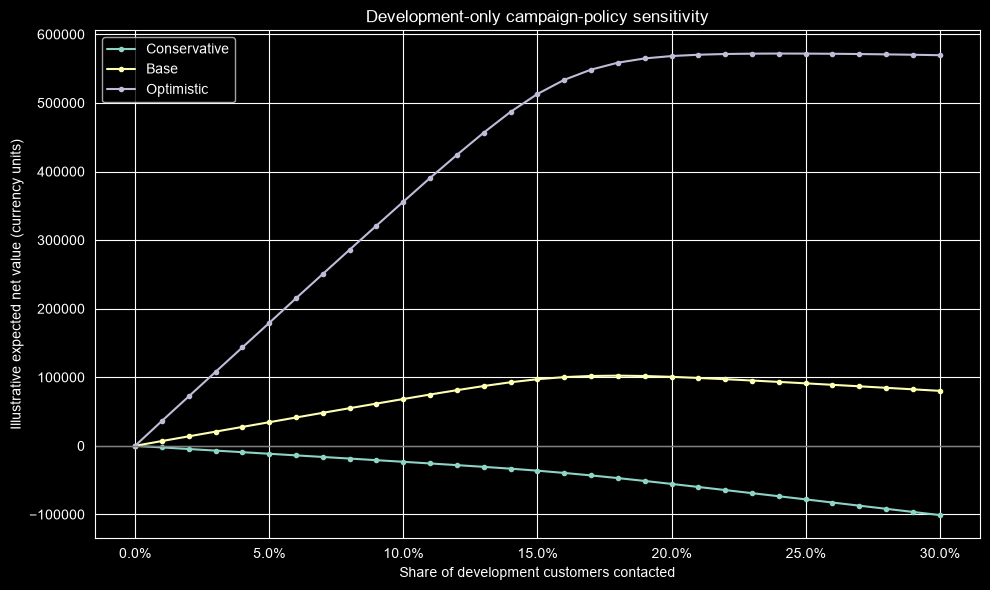

In [357]:
ECONOMIC_CHART_SCENARIOS = {
    "Conservative": {"retained_value": 500.0, "contact_cost": 50.0, "retention_success": 0.05},
    "Base": {"retained_value": 1000.0, "contact_cost": 25.0, "retention_success": 0.10},
    "Optimistic": {"retained_value": 2000.0, "contact_cost": 10.0, "retention_success": 0.20},
}

plt.figure(figsize=(10, 6))
for scenario_name, assumptions in ECONOMIC_CHART_SCENARIOS.items():
    scenario_curve = campaign_economics_by_capacity(
        y_train, development_policy_probabilities,
        maximum_capacity=CAMPAIGN_ECONOMIC_ASSUMPTIONS["maximum_capacity"],
        fixed_cost=CAMPAIGN_ECONOMIC_ASSUMPTIONS["fixed_campaign_cost"],
        **assumptions,
    )
    plt.plot(
        scenario_curve["capacity"], scenario_curve["expected_net_value"],
        marker="o", markersize=3, label=scenario_name,
    )
plt.axhline(0, color="grey", linewidth=1)
plt.gca().xaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0))
plt.xlabel("Share of development customers contacted")
plt.ylabel("Illustrative expected net value (currency units)")
plt.title("Development-only campaign-policy sensitivity")
plt.legend()
plt.tight_layout()
plt.show()


### 15.5 Randomized retention pilot

- Eligible: existing customers, High/Medium risk band
- Treatment: signal-based retention intervention
- Control: business as usual
- Randomization strata: risk band and signal
- Primary outcome: churn over a pre-declared horizon
- Primary analysis: intention-to-treat

### 15.6 Sample size and minimum detectable effect

In [358]:
def required_sample_size_two_proportions(
    control_rate, absolute_reduction, alpha=0.05, power=0.80,
):
    treatment_rate = control_rate - absolute_reduction
    if not 0 < treatment_rate < control_rate < 1:
        return np.nan
    pooled_rate = (control_rate + treatment_rate) / 2
    z_alpha = norm.ppf(1 - alpha / 2)
    z_power = norm.ppf(power)
    numerator = (
        z_alpha * np.sqrt(2 * pooled_rate * (1 - pooled_rate))
        + z_power * np.sqrt(
            control_rate * (1 - control_rate)
            + treatment_rate * (1 - treatment_rate)
        )
    ) ** 2
    return int(np.ceil(numerator / absolute_reduction**2))


**Pilot assumptions**

In [359]:
EXPERIMENT_ASSUMPTIONS = pd.Series({
    "alpha": 0.05,
    "power": 0.80,
    "outcome_horizon_months": 3,
    "illustrative_control_churn_rate": float(y_train.mean()),
    "illustrative_minimum_detectable_reduction": 0.05,
    "treatment_allocation": 0.50,
}, name="illustrative_value")

CONTROL_RATE_SCENARIOS = [float(y_train.mean()), 0.25, 0.35, 0.50]
ABSOLUTE_REDUCTION_SCENARIOS = [0.02, 0.03, 0.04, 0.05, 0.08]
power_rows = []
for control_rate in CONTROL_RATE_SCENARIOS:
    for reduction in ABSOLUTE_REDUCTION_SCENARIOS:
        required_per_arm = required_sample_size_two_proportions(
            control_rate, reduction,
            alpha=EXPERIMENT_ASSUMPTIONS["alpha"],
            power=EXPERIMENT_ASSUMPTIONS["power"],
        )
        power_rows.append({
            "assumed_control_churn_rate": control_rate,
            "minimum_detectable_absolute_reduction": reduction,
            "required_per_arm": required_per_arm,
            "required_total": required_per_arm * 2 if pd.notna(required_per_arm) else np.nan,
        })

experiment_power_table = pd.DataFrame(power_rows)
display(EXPERIMENT_ASSUMPTIONS.to_frame())
display(experiment_power_table)


,illustrative_value
alpha,0.050000
power,0.800000
outcome_horizon_months,3.000000
illustrative_control_churn_rate,0.167028
illustrative_minimum_detectable_reduction,0.050000
treatment_allocation,0.500000


,assumed_control_churn_rate,minimum_detectable_absolute_reduction,required_per_arm,required_total
0,0.167028,0.02,5194,10388
1,0.167028,0.03,2248,4496
2,0.167028,0.04,1230,2460
3,0.167028,0.05,764,1528
4,0.167028,0.08,271,542
5,0.250000,0.02,7157,14314
6,0.250000,0.03,3135,6270
7,0.250000,0.04,1737,3474
8,0.250000,0.05,1094,2188
9,0.250000,0.08,406,812


### 15.7 Blocked pilot assignment

**Define eligible pilot and blocks**

In [360]:
EXPERIMENT_RANDOM_STATE = 2026
PILOT_RISK_BANDS = ["High", "Medium"]
pilot_assignment = existing_population.loc[
    existing_population["risk_band"].isin(PILOT_RISK_BANDS)
].copy()
credit_block_labels = ["CL_Q1", "CL_Q2", "CL_Q3", "CL_Q4", "CL_Q5"]
pilot_assignment["credit_limit_block"] = pd.qcut(
    pilot_assignment["Credit_Limit_clean"].rank(method="first"),
    q=len(credit_block_labels),
    labels=credit_block_labels,
)
pilot_assignment["randomization_stratum"] = (
    pilot_assignment["risk_band"].astype(str)
    + " | "
    + pilot_assignment["operational_signal"].astype(str)
    + " | "
    + pilot_assignment["credit_limit_block"].astype(str)
)


**Randomize within blocks**

In [361]:
rng = np.random.default_rng(EXPERIMENT_RANDOM_STATE)
pilot_assignment["experiment_arm"] = pd.Series(index=pilot_assignment.index, dtype="string")
for _, stratum_index in pilot_assignment.groupby("randomization_stratum").groups.items():
    shuffled_index = rng.permutation(np.asarray(list(stratum_index)))
    treatment_count = len(shuffled_index) // 2
    pilot_assignment.loc[shuffled_index[:treatment_count], "experiment_arm"] = "Treatment"
    pilot_assignment.loc[shuffled_index[treatment_count:], "experiment_arm"] = "Control"


**Attach the intervention**

In [362]:
pilot_assignment["assigned_intervention"] = np.where(
    pilot_assignment["experiment_arm"].eq("Treatment"),
    pilot_assignment["suggested_intervention"],
    "Business as usual / no incremental retention outreach",
)


**Summarize pilot arms**

In [363]:
pilot_arm_summary = (
    pilot_assignment.groupby(["experiment_arm", "risk_band"], observed=True)
    .agg(
        customers=("Customer_Number", "size"),
        average_score=("churn_probability", "mean"),
    )
    .reset_index()
)
display(pilot_arm_summary.round(4))


,experiment_arm,risk_band,customers,average_score
0,Control,High,490,0.1684
1,Control,Medium,969,0.0052
2,Treatment,High,471,0.1644
3,Treatment,Medium,951,0.0051


**Check pilot sample size**

In [364]:
pilot_power_feasibility = experiment_power_table.loc[
    np.isclose(
        experiment_power_table["minimum_detectable_absolute_reduction"],
        EXPERIMENT_ASSUMPTIONS["illustrative_minimum_detectable_reduction"],
    ),
    ["assumed_control_churn_rate", "minimum_detectable_absolute_reduction", "required_total"],
].copy()
pilot_power_feasibility["available_pilot_customers"] = len(pilot_assignment)
pilot_power_feasibility["feasible_with_available_population"] = (
    pilot_power_feasibility["required_total"] <= len(pilot_assignment)
)
display(pilot_power_feasibility)
print(f"Pilot-eligible customers: {len(pilot_assignment):,}")


,assumed_control_churn_rate,minimum_detectable_absolute_reduction,required_total,available_pilot_customers,feasible_with_available_population
3,0.167028,0.05,1528,2881,True
8,0.250000,0.05,2188,2881,True
13,0.350000,0.05,2754,2881,True
18,0.500000,0.05,3130,2881,False


Pilot-eligible customers: 2,881


### 15.8 Pre-treatment balance

In [365]:
def experiment_numeric_balance(data, features, arm_column="experiment_arm"):
    rows = []
    for feature in features:
        control = data.loc[data[arm_column].eq("Control"), feature].dropna().astype(float)
        treatment = data.loc[data[arm_column].eq("Treatment"), feature].dropna().astype(float)
        pooled_sd = np.sqrt((control.var(ddof=1) + treatment.var(ddof=1)) / 2)
        rows.append({
            "feature": feature,
            "control_mean": control.mean(),
            "treatment_mean": treatment.mean(),
            "standardized_mean_difference": (
                (treatment.mean() - control.mean()) / pooled_sd if pooled_sd else np.nan
            ),
        })
    return pd.DataFrame(rows)

EXPERIMENT_BALANCE_FEATURES = [
    "churn_probability", "Age_clean", "Credit_Limit_clean",
    "Total_Trans_Ct", "Total_Trans_Amt",
    "Months_Inactive_12_mon", "Contacts_Count_12_mon",
]
experiment_balance = experiment_numeric_balance(
    pilot_assignment, EXPERIMENT_BALANCE_FEATURES
)
display(experiment_balance.round(4))
display(pd.crosstab(
    pilot_assignment["operational_signal"],
    pilot_assignment["experiment_arm"],
))


,feature,control_mean,treatment_mean,standardized_mean_difference
0,churn_probability,0.0600,0.0579,-0.0144
1,Age_clean,45.4478,46.2118,0.0871
2,Credit_Limit_clean,9767.3802,9625.2527,-0.0150
3,Total_Trans_Ct,53.7464,53.9677,0.0111
4,Total_Trans_Amt,3400.6546,3372.0190,-0.0101
5,Months_Inactive_12_mon,2.3509,2.3249,-0.0261
6,Contacts_Count_12_mon,2.5929,2.5942,0.0013


experiment_arm,Control,Treatment
operational_signal,,
Broad multi-factor risk,63,55
Few bank relationships,95,89
High service-contact frequency,785,780
Low transaction frequency,142,136
Low transaction value,29,26
No revolving utilization,35,30
Recent inactivity,310,306


### 15.9 Outcome template and ITT analysis

In [366]:
pilot_results_template = pilot_assignment[[
    "Customer_Number", "experiment_arm", "assigned_intervention",
    "risk_band", "operational_signal", "churn_probability",
]].copy()
pilot_results_template["outcome_window_start"] = pd.NaT
pilot_results_template["outcome_window_end"] = pd.NaT
pilot_results_template["churned_during_horizon"] = pd.Series(
    pd.NA, index=pilot_results_template.index, dtype="Int64"
)
pilot_results_template["post_period_transaction_count"] = np.nan
pilot_results_template["post_period_transaction_amount"] = np.nan
pilot_results_template["actual_campaign_cost"] = np.nan

display(pilot_results_template.head())


,Customer_Number,experiment_arm,assigned_intervention,risk_band,operational_signal,churn_probability,outcome_window_start,outcome_window_end,churned_during_horizon,post_period_transaction_count,post_period_transaction_amount,actual_campaign_cost
5,3708105258,Treatment,Relevant usage or spend activation offer,Medium,Low transaction frequency,0.007199,NaT,NaT,<NA>,NaN,NaN,NaN
10,3708114783,Control,Business as usual / no incremental retention o...,Medium,Recent inactivity,0.003704,NaT,NaT,<NA>,NaN,NaN,NaN
12,3708122133,Treatment,Service-recovery review before any offer,Medium,High service-contact frequency,0.013788,NaT,NaT,<NA>,NaN,NaN,NaN
15,3708129783,Control,Business as usual / no incremental retention o...,High,Broad multi-factor risk,0.030708,NaT,NaT,<NA>,NaN,NaN,NaN
22,3708143256,Treatment,Service-recovery review before any offer,Medium,High service-contact frequency,0.003023,NaT,NaT,<NA>,NaN,NaN,NaN


**Future ITT analysis**

In [367]:
def evaluate_retention_experiment(
    results, outcome="churned_during_horizon",
    arm="experiment_arm", control_label="Control", treatment_label="Treatment",
):
    analysis = results.loc[results[outcome].notna()].copy()
    if analysis.empty:
        raise ValueError("No post-intervention outcomes are available yet.")
    control = analysis.loc[analysis[arm].eq(control_label), outcome].astype(int)
    treatment = analysis.loc[analysis[arm].eq(treatment_label), outcome].astype(int)
    control_rate = control.mean()
    treatment_rate = treatment.mean()
    absolute_reduction = control_rate - treatment_rate
    standard_error = np.sqrt(
        control_rate * (1 - control_rate) / len(control)
        + treatment_rate * (1 - treatment_rate) / len(treatment)
    )
    z_statistic = absolute_reduction / standard_error if standard_error else np.nan
    p_value = 2 * (1 - norm.cdf(abs(z_statistic))) if pd.notna(z_statistic) else np.nan
    ci_low = absolute_reduction - 1.96 * standard_error
    ci_high = absolute_reduction + 1.96 * standard_error
    incremental_customers_retained = absolute_reduction * len(treatment)
    return pd.DataFrame([{
        "control_customers": len(control),
        "treatment_customers": len(treatment),
        "control_churn_rate": control_rate,
        "treatment_churn_rate": treatment_rate,
        "absolute_churn_reduction": absolute_reduction,
        "relative_churn_reduction": absolute_reduction / control_rate if control_rate else np.nan,
        "ci_95_low": ci_low,
        "ci_95_high": ci_high,
        "p_value": p_value,
        "incremental_customers_retained": incremental_customers_retained,
    }])

print("The ITT evaluation function is ready; it requires future randomized-treatment outcomes.")


The ITT evaluation function is ready; it requires future randomized-treatment outcomes.


### 15.10 References

- [World Bank & IADB — Impact Evaluation in Practice](https://www.worldbank.org/en/programs/sief-trust-fund/publication/impact-evaluation-in-practice)
- [statsmodels — power for a two-sample z-test](https://www.statsmodels.org/stable/generated/statsmodels.stats.power.NormalIndPower.power.html)
- [Uplift modeling for churn and retention](https://www.sciencedirect.com/science/article/abs/pii/S0019850121001930)

## 16. Win-back and campaign measurement

- **Retention:** existing customers who may churn in the future.
- **Win-back:** attrited customers who may return after an intervention.

Success for win-back is measured as return/reactivation rate vs. a control group, not a churn-rate change — these customers have already churned.

### 16.1 Attrited-customer base

**Isolate attrited customers**

In [368]:
attrited_candidates = customer_base.loc[
    customer_base["Attrition_Flag_clean"].eq("Attrited Customer")
].copy()


**Required operational fields**

In [369]:
REQUIRED_WINBACK_OPERATIONAL_FIELDS = {
    "attrition_date": "Establish recency and the start of the return window",
    "attrition_reason": "Match the intervention to the documented reason for leaving",
    "customer_initiated_exit": "Exclude bank-initiated or ineligible closures",
    "marketing_consent": "Confirm permission for the proposed channel",
    "do_not_contact": "Respect contact restrictions",
    "preferred_channel": "Use the approved customer-preferred channel",
    "contactable_flag": "Confirm that approved contact details remain valid",
    "fraud_or_compliance_exclusion": "Apply risk and compliance exclusions",
    "deceased_flag": "Apply mandatory exclusions",
    "open_complaint_flag": "Route unresolved complaints through customer care",
    "actual_customer_margin": "Measure value using contribution, not credit limit",
    "expected_second_lifetime_value": "Evaluate the economics of reacquisition",
    "estimated_offer_cost": "Evaluate campaign cost before launch",
}


**Audit field availability**

In [370]:
winback_field_availability = pd.DataFrame([
    {
        "required_field": field,
        "available_in_snapshot": field in attrited_candidates.columns,
        "business_purpose": purpose,
    }
    for field, purpose in REQUIRED_WINBACK_OPERATIONAL_FIELDS.items()
])


**Mark as analytical only**

In [371]:
attrited_candidates["campaign_authorization_status"] = (
    "Analytical candidate only - operational eligibility not supplied"
)

display(winback_field_availability)
print(f"Deduplicated labelled attrited customers: {len(attrited_candidates):,}")
print("This population is analytical only until the missing operational fields are joined.")


,required_field,available_in_snapshot,business_purpose
0,attrition_date,False,Establish recency and the start of the return ...
1,attrition_reason,False,Match the intervention to the documented reaso...
2,customer_initiated_exit,False,Exclude bank-initiated or ineligible closures
3,marketing_consent,False,Confirm permission for the proposed channel
4,do_not_contact,False,Respect contact restrictions
5,preferred_channel,False,Use the approved customer-preferred channel
6,contactable_flag,False,Confirm that approved contact details remain v...
7,fraud_or_compliance_exclusion,False,Apply risk and compliance exclusions
8,deceased_flag,False,Apply mandatory exclusions
9,open_complaint_flag,False,Route unresolved complaints through customer care


Deduplicated labelled attrited customers: 1,925
This population is analytical only until the missing operational fields are joined.


### 16.2 Relationship-strength components

**Percentile components**

In [372]:
attrited_candidates["activity_recency_proxy"] = (
    1 - attrited_candidates["Months_Inactive_12_mon"].rank(method="average", pct=True)
)
attrited_candidates["frequency_proxy"] = attrited_candidates["Total_Trans_Ct"].rank(
    method="average", pct=True
)
attrited_candidates["monetary_proxy"] = attrited_candidates["Total_Trans_Amt"].rank(
    method="average", pct=True
)
attrited_candidates["relationship_depth_proxy"] = attrited_candidates[
    "Total_Relationship_Count"
].rank(method="average", pct=True)
attrited_candidates["relationship_duration_proxy"] = attrited_candidates[
    "Months_on_book"
].rank(method="average", pct=True)


**Win-back potential proxy**

In [373]:
WINBACK_PROXY_COMPONENTS = [
    "activity_recency_proxy", "frequency_proxy", "monetary_proxy",
    "relationship_depth_proxy", "relationship_duration_proxy",
]
attrited_candidates["proxy_components_available"] = attrited_candidates[
    WINBACK_PROXY_COMPONENTS
].notna().sum(axis=1)
attrited_candidates["winback_potential_proxy"] = attrited_candidates[
    WINBACK_PROXY_COMPONENTS
].median(axis=1, skipna=True).where(
    attrited_candidates["proxy_components_available"].ge(3)
)


**Commercial-engagement proxy**

In [374]:
attrited_candidates["commercial_engagement_proxy"] = attrited_candidates[[
    "frequency_proxy", "monetary_proxy", "relationship_depth_proxy",
]].median(axis=1, skipna=True)


**Inspect proxy distributions**

In [375]:
display(
    attrited_candidates[
        WINBACK_PROXY_COMPONENTS
        + ["winback_potential_proxy", "commercial_engagement_proxy"]
    ].describe().T.round(4)
)


,count,mean,std,min,25%,50%,75%,max
activity_recency_proxy,1925.0,0.4997,0.2647,0.0052,0.3665,0.3665,0.7735,0.9948
frequency_proxy,1925.0,0.5003,0.2886,0.0013,0.2584,0.4971,0.7470,1.0000
monetary_proxy,1925.0,0.5003,0.2887,0.0010,0.2504,0.5003,0.7501,1.0000
relationship_depth_proxy,1925.0,0.5003,0.2837,0.0748,0.2569,0.4855,0.8151,0.9431
relationship_duration_proxy,1925.0,0.5003,0.2856,0.0021,0.2449,0.4823,0.7475,0.9948
winback_potential_proxy,1925.0,0.5001,0.2081,0.0216,0.3665,0.4823,0.6753,0.9616
commercial_engagement_proxy,1925.0,0.5059,0.2685,0.0021,0.2855,0.4951,0.7223,0.9894


### 16.3 Ranking sensitivity

**Alternative proxy formulations**

In [376]:
WINBACK_PROXY_VARIANTS = {
    "rfm": [
        "activity_recency_proxy", "frequency_proxy", "monetary_proxy",
    ],
    "relationship_enriched": WINBACK_PROXY_COMPONENTS,
    "commercial_engagement": [
        "frequency_proxy", "monetary_proxy", "relationship_depth_proxy",
    ],
}


**Score and rank variants**

In [377]:
variant_rank_columns = []
for variant, components in WINBACK_PROXY_VARIANTS.items():
    score_column = f"{variant}_score"
    rank_column = f"{variant}_rank"
    attrited_candidates[score_column] = attrited_candidates[components].median(
        axis=1, skipna=True
    )
    attrited_candidates[rank_column] = attrited_candidates[score_column].rank(
        method="average", pct=True
    )
    variant_rank_columns.append(rank_column)


**Create consensus tiers**

In [378]:
attrited_candidates["consensus_rank"] = attrited_candidates[
    variant_rank_columns
].median(axis=1, skipna=True)
attrited_candidates["top_quartile_variant_count"] = attrited_candidates[
    variant_rank_columns
].ge(0.75).sum(axis=1)
attrited_candidates["stable_top_quartile"] = attrited_candidates[
    "top_quartile_variant_count"
].ge(2)
attrited_candidates["priority_tier"] = np.select(
    [
        attrited_candidates["stable_top_quartile"],
        attrited_candidates["consensus_rank"].ge(0.50),
    ],
    ["Tier A", "Tier B"],
    default="Tier C",
)


**Potential and engagement bands**

In [379]:
attrited_candidates["potential_band"] = np.select(
    [
        attrited_candidates["consensus_rank"].ge(0.75),
        attrited_candidates["consensus_rank"].ge(0.50),
    ],
    ["High", "Medium"],
    default="Lower",
)
engagement_rank = attrited_candidates["commercial_engagement_proxy"].rank(
    method="average", pct=True
)
attrited_candidates["commercial_engagement_band"] = np.select(
    [engagement_rank.ge(0.75), engagement_rank.ge(0.50)],
    ["High", "Medium"],
    default="Lower",
)


**Assign action segments**

In [380]:
attrited_candidates["winback_action_segment"] = np.select(
    [
        attrited_candidates["potential_band"].eq("High")
        & attrited_candidates["commercial_engagement_band"].eq("High"),
        attrited_candidates["potential_band"].eq("High"),
        attrited_candidates["commercial_engagement_band"].eq("High"),
    ],
    [
        "Priority personal win-back",
        "Low-cost reactivation",
        "Diagnostic review before incentive",
    ],
    default="Low-cost feedback or no paid offer",
)


**Display sensitivity and sizes**

In [381]:
variant_rank_correlation = attrited_candidates[variant_rank_columns].corr(
    method="spearman"
)
priority_summary = (
    attrited_candidates.groupby(
        ["priority_tier", "winback_action_segment"], observed=True
    )
    .agg(
        customers=("Customer_Number", "size"),
        median_consensus_rank=("consensus_rank", "median"),
    )
    .reset_index()
)
display(variant_rank_correlation.round(3))
display(priority_summary.round(4))


,rfm_rank,relationship_enriched_rank,commercial_engagement_rank
rfm_rank,1.000,0.774,0.897
relationship_enriched_rank,0.774,1.000,0.784
commercial_engagement_rank,0.897,0.784,1.000


,priority_tier,winback_action_segment,customers,median_consensus_rank
0,Tier A,Low-cost reactivation,41,0.7766
1,Tier A,Priority personal win-back,448,0.8870
2,Tier B,Diagnostic review before incentive,13,0.7062
3,Tier B,Low-cost feedback or no paid offer,460,0.6200
4,Tier C,Diagnostic review before incentive,21,0.4639
5,Tier C,Low-cost feedback or no paid offer,942,0.2549


### 16.4 Signals to strategies

**Win-back signal thresholds**

In [382]:
attrited_signal_thresholds = {
    "high_contacts": attrited_candidates["Contacts_Count_12_mon"].quantile(0.75),
    "lower_inactivity": attrited_candidates["Months_Inactive_12_mon"].quantile(0.25),
    "strong_transactions": attrited_candidates["Total_Trans_Ct"].quantile(0.75),
    "broad_relationship": attrited_candidates["Total_Relationship_Count"].quantile(0.75),
}


**Assign the dominant signal**

In [383]:
attrited_candidates["observed_winback_signal"] = np.select(
    [
        attrited_candidates["Contacts_Count_12_mon"].ge(
            attrited_signal_thresholds["high_contacts"]
        ),
        attrited_candidates["Months_Inactive_12_mon"].le(
            attrited_signal_thresholds["lower_inactivity"]
        ),
        attrited_candidates["Total_Trans_Ct"].ge(
            attrited_signal_thresholds["strong_transactions"]
        ),
        attrited_candidates["Total_Relationship_Count"].ge(
            attrited_signal_thresholds["broad_relationship"]
        ),
    ],
    [
        "High previous contact frequency - reason unknown",
        "Lower inactivity relative to other attrited customers",
        "Strong previous transaction activity",
        "Broad previous bank relationship",
    ],
    default="No dominant observed signal",
)


**Map segments to strategies**

In [384]:
WINBACK_STRATEGY_MAP = {
    "Priority personal win-back": (
        "Personal needs-and-exit-reason review, reactivation help, and one "
        "approved incentive only if eligible"
    ),
    "Low-cost reactivation": (
        "Secure digital welcome-back message with simple reactivation assistance"
    ),
    "Diagnostic review before incentive": (
        "Diagnostic service review before considering any incentive"
    ),
    "Low-cost feedback or no paid offer": (
        "Low-cost feedback request or no incremental paid offer"
    ),
}


**Offer and cadence examples**

In [385]:
WINBACK_OFFER_EXAMPLES = {
    "Priority personal win-back": (
        "Illustrative: fee waiver on the next annual card fee, or an equivalent bonus-points "
        "credit, offered only after the exit-reason conversation and only if approved"
    ),
    "Low-cost reactivation": (
        "Illustrative: limited-time bonus-rewards multiplier on the first 3 transactions after "
        "reactivation"
    ),
    "Diagnostic review before incentive": (
        "No incentive proposed until the underlying service issue is reviewed and resolved"
    ),
    "Low-cost feedback or no paid offer": (
        "No paid incentive; a short feedback request only"
    ),
}
WINBACK_TOUCH_CADENCE = {
    "Priority personal win-back": (
        "Day 0: personal call or relationship-manager outreach; Day 3: SMS follow-up if no "
        "contact; Day 7: email with the approved offer if still no response; Day 21: close out "
        "and route to the diagnostic-review segment if unresolved"
    ),
    "Low-cost reactivation": (
        "Day 0: secure app or push notification; Day 5: reactivation email; Day 14: single "
        "low-cost reminder, then stop"
    ),
    "Diagnostic review before incentive": (
        "Day 0: phone or branch service-review request; Day 10: one follow-up call; no "
        "incentive is sent within this cadence"
    ),
    "Low-cost feedback or no paid offer": (
        "Day 0: single low-cost digital feedback request; no further scheduled touches"
    ),
}

**Map signals to messages**

In [386]:
WINBACK_MESSAGE_MAP = {
    "High previous contact frequency - reason unknown": (
        "Ask what happened, listen first, and offer a documented resolution path"
    ),
    "Lower inactivity relative to other attrited customers": (
        "Make returning simple and explain the relevant approved benefit clearly"
    ),
    "Strong previous transaction activity": (
        "Acknowledge previous use and test one relevant, time-bound approved benefit"
    ),
    "Broad previous bank relationship": (
        "Recognize the previous relationship and offer a needs-based review"
    ),
    "No dominant observed signal": (
        "Request feedback without pressure and avoid an uneconomic blanket discount"
    ),
}


**Sample message copy**

In [387]:
WINBACK_SAMPLE_COPY = {
    "High previous contact frequency - reason unknown": (
        "\"We noticed you reached out to us more than once before you left. We would like to "
        "hear what happened and make it right.\""
    ),
    "Lower inactivity relative to other attrited customers": (
        "\"Coming back is simple. Here is the benefit that is most relevant to how you used "
        "your card.\""
    ),
    "Strong previous transaction activity": (
        "\"We valued having you as an active customer. Here is a time-bound benefit as a "
        "thank-you for coming back.\""
    ),
    "Broad previous bank relationship": (
        "\"You had a broad relationship with us. Let us review what you need today and how we "
        "can support it.\""
    ),
    "No dominant observed signal": (
        "\"We would appreciate your feedback on your experience with us - no strings attached.\""
    ),
}

**Attach strategy and message**

In [388]:
attrited_candidates["proposed_intervention"] = attrited_candidates[
    "winback_action_segment"
].map(WINBACK_STRATEGY_MAP)
attrited_candidates["message_principle"] = attrited_candidates[
    "observed_winback_signal"
].map(WINBACK_MESSAGE_MAP)
attrited_candidates["illustrative_offer_example"] = attrited_candidates[
    "winback_action_segment"
].map(WINBACK_OFFER_EXAMPLES)
attrited_candidates["touch_cadence"] = attrited_candidates[
    "winback_action_segment"
].map(WINBACK_TOUCH_CADENCE)
attrited_candidates["sample_message_copy"] = attrited_candidates[
    "observed_winback_signal"
].map(WINBACK_SAMPLE_COPY)


**Channel guidance and rules**

In [389]:
attrited_candidates["proposed_channel_if_eligible"] = attrited_candidates[
    "winback_action_segment"
].map({
    "Priority personal win-back": (
        "Approved preferred channel; official phone or relationship manager where permitted"
    ),
    "Low-cost reactivation": "Approved preferred secure digital channel",
    "Diagnostic review before incentive": "Approved official phone or branch service review",
    "Low-cost feedback or no paid offer": "Low-cost approved digital channel or control",
})
attrited_candidates["secure_contact_rule"] = (
    "Use approved CIB channels; never request confidential banking credentials"
)


### 16.5 Win-back customer list

In [390]:
WINBACK_CUSTOMER_COLUMNS = [
    "Customer_Number", "priority_tier", "consensus_rank",
    "winback_potential_proxy", "commercial_engagement_proxy",
    "potential_band", "commercial_engagement_band",
    "winback_action_segment", "observed_winback_signal",
    "proposed_intervention", "illustrative_offer_example", "touch_cadence",
    "proposed_channel_if_eligible",
    "message_principle", "sample_message_copy", "secure_contact_rule",
    "campaign_authorization_status", "Months_Inactive_12_mon",
    "Total_Trans_Ct", "Total_Trans_Amt", "Total_Relationship_Count",
    "Months_on_book", "Contacts_Count_12_mon",
]
winback_customer_list = attrited_candidates.sort_values(
    ["priority_tier", "consensus_rank"],
    ascending=[True, False],
)[WINBACK_CUSTOMER_COLUMNS].copy()

winback_customer_list_display = winback_customer_list.head(25).copy()
for column in [
    "consensus_rank", "winback_potential_proxy", "commercial_engagement_proxy",
]:
    winback_customer_list_display[column] = winback_customer_list_display[column].map(
        lambda value: f"{value:.1%}" if pd.notna(value) else "Missing"
    )
display(winback_customer_list_display)



,Customer_Number,priority_tier,consensus_rank,winback_potential_proxy,commercial_engagement_proxy,potential_band,commercial_engagement_band,winback_action_segment,observed_winback_signal,proposed_intervention,...,message_principle,sample_message_copy,secure_contact_rule,campaign_authorization_status,Months_Inactive_12_mon,Total_Trans_Ct,Total_Trans_Amt,Total_Relationship_Count,Months_on_book,Contacts_Count_12_mon
3093,3713743758,Tier A,100.0%,48.2%,98.9%,High,High,Priority personal win-back,Strong previous transaction activity,"Personal needs-and-exit-reason review, reactiv...",...,Acknowledge previous use and test one relevant...,"""We valued having you as an active customer. H...",Use approved CIB channels; never request confi...,Analytical candidate only - operational eligib...,3,85,10219,2,36,2
3578,3714534708,Tier A,99.9%,89.0%,98.3%,High,High,Priority personal win-back,Strong previous transaction activity,"Personal needs-and-exit-reason review, reactiv...",...,Acknowledge previous use and test one relevant...,"""We valued having you as an active customer. H...",Use approved CIB channels; never request confi...,Analytical candidate only - operational eligib...,3,82,9441,1,46,3
1086,3710188683,Tier A,99.9%,81.5%,97.8%,High,High,Priority personal win-back,High previous contact frequency - reason unknown,"Personal needs-and-exit-reason review, reactiv...",...,"Ask what happened, listen first, and offer a d...","""We noticed you reached out to us more than on...",Use approved CIB channels; never request confi...,Analytical candidate only - operational eligib...,3,89,9314,5,38,6
147,3708395658,Tier A,99.8%,48.2%,97.8%,High,High,Priority personal win-back,Strong previous transaction activity,"Personal needs-and-exit-reason review, reactiv...",...,Acknowledge previous use and test one relevant...,"""We valued having you as an active customer. H...",Use approved CIB channels; never request confi...,Analytical candidate only - operational eligib...,3,80,9524,2,36,3
7957,3758021789,Tier A,99.8%,48.2%,97.8%,High,High,Priority personal win-back,Strong previous transaction activity,"Personal needs-and-exit-reason review, reactiv...",...,Acknowledge previous use and test one relevant...,"""We valued having you as an active customer. H...",Use approved CIB channels; never request confi...,Analytical candidate only - operational eligib...,3,80,9524,2,36,3
9672,3786554746,Tier A,99.8%,48.2%,97.8%,High,High,Priority personal win-back,Strong previous transaction activity,"Personal needs-and-exit-reason review, reactiv...",...,Acknowledge previous use and test one relevant...,"""We valued having you as an active customer. H...",Use approved CIB channels; never request confi...,Analytical candidate only - operational eligib...,3,80,9524,2,36,3
6095,3719336883,Tier A,99.7%,67.5%,97.5%,High,High,Priority personal win-back,Strong previous transaction activity,"Personal needs-and-exit-reason review, reactiv...",...,Acknowledge previous use and test one relevant...,"""We valued having you as an active customer. H...",Use approved CIB channels; never request confi...,Analytical candidate only - operational eligib...,3,85,9226,4,36,2
1952,3711756258,Tier A,99.6%,67.5%,97.5%,High,High,Priority personal win-back,Strong previous transaction activity,"Personal needs-and-exit-reason review, reactiv...",...,Acknowledge previous use and test one relevant...,"""We valued having you as an active customer. H...",Use approved CIB channels; never request confi...,Analytical candidate only - operational eligib...,3,81,9220,4,37,2
800,3709618833,Tier A,99.5%,95.9%,97.4%,High,High,Priority personal win-back,High previous contact frequency - reason unknown,"Personal needs-and-exit-reason review, reactiv...",...,"Ask what happened, listen first, and offer a d...","""We noticed you reached out to us more than on...",Use approved CIB channels; never request confi...,Analytical candidate only - operational eligib...,1,79,9451,5,17,4
2835,3713291958,Tier A,99.5%,94.3%,9

### 16.6 Operational-enrichment template

In [391]:
winback_operational_template = winback_customer_list[[
    "Customer_Number", "priority_tier", "winback_action_segment",
    "proposed_intervention",
]].copy()
winback_operational_template["attrition_date"] = pd.NaT
winback_operational_template["attrition_reason"] = pd.Series(
    pd.NA, index=winback_operational_template.index, dtype="string"
)
winback_operational_template["customer_initiated_exit"] = pd.Series(
    pd.NA, index=winback_operational_template.index, dtype="boolean"
)
for field in [
    "marketing_consent", "do_not_contact", "contactable_flag",
    "fraud_or_compliance_exclusion", "deceased_flag", "open_complaint_flag",
]:
    winback_operational_template[field] = pd.Series(
        pd.NA, index=winback_operational_template.index, dtype="boolean"
    )
winback_operational_template["preferred_channel"] = pd.Series(
    pd.NA, index=winback_operational_template.index, dtype="string"
)
for field in [
    "actual_customer_margin", "expected_second_lifetime_value",
    "estimated_offer_cost",
]:
    winback_operational_template[field] = np.nan

display(winback_operational_template.head())


,Customer_Number,priority_tier,winback_action_segment,proposed_intervention,attrition_date,attrition_reason,customer_initiated_exit,marketing_consent,do_not_contact,contactable_flag,fraud_or_compliance_exclusion,deceased_flag,open_complaint_flag,preferred_channel,actual_customer_margin,expected_second_lifetime_value,estimated_offer_cost
3093,3713743758,Tier A,Priority personal win-back,"Personal needs-and-exit-reason review, reactiv...",NaT,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,NaN,NaN
3578,3714534708,Tier A,Priority personal win-back,"Personal needs-and-exit-reason review, reactiv...",NaT,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,NaN,NaN
1086,3710188683,Tier A,Priority personal win-back,"Personal needs-and-exit-reason review, reactiv...",NaT,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,NaN,NaN
147,3708395658,Tier A,Priority personal win-back,"Personal needs-and-exit-reason review, reactiv...",NaT,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,NaN,NaN
7957,3758021789,Tier A,Priority personal win-back,"Personal needs-and-exit-reason review, reactiv...",NaT,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,NaN,NaN


### 16.7 Pilot power for win-back

**Sample size for return lift**

In [392]:
def required_sample_size_return_increase(
    control_rate, absolute_increase, alpha=0.05, power=0.80,
):
    treatment_rate = control_rate + absolute_increase
    if not 0 < control_rate < treatment_rate < 1:
        return np.nan
    pooled_rate = (control_rate + treatment_rate) / 2
    z_alpha = norm.ppf(1 - alpha / 2)
    z_power = norm.ppf(power)
    numerator = (
        z_alpha * np.sqrt(2 * pooled_rate * (1 - pooled_rate))
        + z_power * np.sqrt(
            control_rate * (1 - control_rate)
            + treatment_rate * (1 - treatment_rate)
        )
    ) ** 2
    return int(np.ceil(numerator / absolute_increase**2))


**Minimum detectable lift**

In [393]:
def minimum_detectable_return_increase(
    control_rate, available_population, arms=2, comparisons=1,
    alpha=0.05, power=0.80,
):
    per_arm = available_population // arms
    if per_arm < 2:
        return np.nan
    adjusted_alpha = alpha / comparisons
    low, high = 0.0001, 1 - control_rate - 0.0001
    if required_sample_size_return_increase(
        control_rate, high, adjusted_alpha, power
    ) > per_arm:
        return np.nan
    for _ in range(60):
        midpoint = (low + high) / 2
        required = required_sample_size_return_increase(
            control_rate, midpoint, adjusted_alpha, power
        )
        if required <= per_arm:
            high = midpoint
        else:
            low = midpoint
    return high


**Win-back experiment assumptions**

In [394]:
WINBACK_EXPERIMENT_ASSUMPTIONS = pd.Series({
    "alpha": 0.05,
    "power": 0.80,
    "primary_outcome_horizon_days": 90,
    "treatment_allocation": 0.50,
}, name="design_value")


**Feasible designs**

In [395]:
top_half_candidates = int(attrited_candidates["consensus_rank"].ge(0.50).sum())
WINBACK_DESIGNS = [
    ("All analytical candidates - two arms", len(attrited_candidates), 2, 1),
    ("Top 50% proxy - two arms", top_half_candidates, 2, 1),
    ("All analytical candidates - four arms", len(attrited_candidates), 4, 3),
]


**Calculate detectable effects**

In [396]:
winback_power_rows = []
for design, population, arms, comparisons in WINBACK_DESIGNS:
    for control_return_rate in [0.05, 0.10, 0.20, 0.30]:
        detectable_lift = minimum_detectable_return_increase(
            control_return_rate,
            available_population=population,
            arms=arms,
            comparisons=comparisons,
            alpha=WINBACK_EXPERIMENT_ASSUMPTIONS["alpha"],
            power=WINBACK_EXPERIMENT_ASSUMPTIONS["power"],
        )
        winback_power_rows.append({
            "design": design,
            "available_population": population,
            "customers_per_arm": population // arms,
            "alpha_per_comparison": (
                WINBACK_EXPERIMENT_ASSUMPTIONS["alpha"] / comparisons
            ),
            "assumed_control_return_rate": control_return_rate,
            "minimum_detectable_absolute_lift": detectable_lift,
        })


**Power table and recommendation**

In [397]:
winback_power_table = pd.DataFrame(winback_power_rows)
display(WINBACK_EXPERIMENT_ASSUMPTIONS.to_frame())
display(winback_power_table.round(4))
print("Recommended first test: all operationally eligible candidates, one policy versus control.")


,design_value
alpha,0.05
power,0.80
primary_outcome_horizon_days,90.00
treatment_allocation,0.50


,design,available_population,customers_per_arm,alpha_per_comparison,assumed_control_return_rate,minimum_detectable_absolute_lift
0,All analytical candidates - two arms,1925,962,0.0500,0.05,0.0317
1,All analytical candidates - two arms,1925,962,0.0500,0.10,0.0416
2,All analytical candidates - two arms,1925,962,0.0500,0.20,0.0535
3,All analytical candidates - two arms,1925,962,0.0500,0.30,0.0600
4,Top 50% proxy - two arms,962,481,0.0500,0.05,0.0471
5,Top 50% proxy - two arms,962,481,0.0500,0.10,0.0608
6,Top 50% proxy - two arms,962,481,0.0500,0.20,0.0769
7,Top 50% proxy - two arms,962,481,0.0500,0.30,0.0856
8,All analytical candidates - four arms,1925,481,0.0167,0.05,0.0558
9,All analytical candidates - four arms,1925,481,0.0167,0.10,0.0713


Recommended first test: all operationally eligible candidates, one policy versus control.


### 16.8 Draft two-arm assignment

**Randomization strata**

In [398]:
WINBACK_RANDOM_STATE = 2026
draft_winback_assignment = attrited_candidates.copy()
draft_winback_assignment["randomization_stratum"] = (
    draft_winback_assignment["priority_tier"].astype(str)
    + " | "
    + draft_winback_assignment["winback_action_segment"].astype(str)
)


**Randomize within strata**

In [399]:
winback_rng = np.random.default_rng(WINBACK_RANDOM_STATE)
draft_winback_assignment["experiment_arm"] = pd.Series(
    index=draft_winback_assignment.index, dtype="string"
)
for _, stratum_index in draft_winback_assignment.groupby(
    "randomization_stratum"
).groups.items():
    shuffled_index = winback_rng.permutation(np.asarray(list(stratum_index)))
    treatment_count = len(shuffled_index) // 2
    draft_winback_assignment.loc[
        shuffled_index[:treatment_count], "experiment_arm"
    ] = "Treatment"
    draft_winback_assignment.loc[
        shuffled_index[treatment_count:], "experiment_arm"
    ] = "Control"


**Attach draft status**

In [400]:
draft_winback_assignment["assigned_intervention"] = np.where(
    draft_winback_assignment["experiment_arm"].eq("Treatment"),
    draft_winback_assignment["proposed_intervention"],
    "Business as usual / no incremental win-back outreach",
)
draft_winback_assignment["assignment_status"] = (
    "Draft only - rerun after operational eligibility merge"
)


**Summarize draft arms**

In [401]:
draft_winback_arm_summary = (
    draft_winback_assignment.groupby(
        ["experiment_arm", "priority_tier"], observed=True
    )
    .agg(
        customers=("Customer_Number", "size"),
        average_consensus_rank=("consensus_rank", "mean"),
    )
    .reset_index()
)
display(draft_winback_arm_summary.round(4))


,experiment_arm,priority_tier,customers,average_consensus_rank
0,Control,Tier A,245,0.8790
1,Control,Tier B,237,0.6208
2,Control,Tier C,482,0.2576
3,Treatment,Tier A,244,0.8719
4,Treatment,Tier B,236,0.6287
5,Treatment,Tier C,481,0.2422


### 16.9 Pre-treatment balance check

In [402]:
WINBACK_BALANCE_FEATURES = [
    "winback_potential_proxy", "commercial_engagement_proxy",
    "Months_Inactive_12_mon", "Total_Trans_Ct", "Total_Trans_Amt",
    "Total_Relationship_Count", "Months_on_book", "Contacts_Count_12_mon",
]
draft_winback_balance = experiment_numeric_balance(
    draft_winback_assignment, WINBACK_BALANCE_FEATURES
)
display(draft_winback_balance.round(4))
display(pd.crosstab(
    draft_winback_assignment["priority_tier"],
    draft_winback_assignment["experiment_arm"],
))
print(
    "Maximum absolute draft SMD: "
    f"{draft_winback_balance['standardized_mean_difference'].abs().max():.4f}"
)


,feature,control_mean,treatment_mean,standardized_mean_difference
0,winback_potential_proxy,0.5027,0.4975,-0.0251
1,commercial_engagement_proxy,0.5106,0.5011,-0.0355
2,Months_Inactive_12_mon,2.6898,2.7003,0.0116
3,Total_Trans_Ct,45.2272,44.2331,-0.0669
4,Total_Trans_Amt,3115.6172,3065.3424,-0.0214
5,Total_Relationship_Count,3.2459,3.2560,0.0064
6,Months_on_book,35.9927,36.3132,0.0415
7,Contacts_Count_12_mon,2.9730,2.9157,-0.0522


experiment_arm,Control,Treatment
priority_tier,,
Tier A,245,244
Tier B,237,236
Tier C,482,481


Maximum absolute draft SMD: 0.0669


### 16.10 Campaign-results template

In [403]:
winback_results_template = draft_winback_assignment[[
    "Customer_Number", "experiment_arm", "assigned_intervention",
    "priority_tier", "winback_action_segment", "observed_winback_signal",
    "consensus_rank", "assignment_status",
]].copy()
for date_field in [
    "eligibility_date", "assignment_date", "outcome_window_start",
    "outcome_window_end",
]:
    winback_results_template[date_field] = pd.NaT
winback_results_template["channel_used"] = pd.Series(
    pd.NA, index=winback_results_template.index, dtype="string"
)
winback_results_template["offer_used"] = pd.Series(
    pd.NA, index=winback_results_template.index, dtype="string"
)
winback_results_template["actual_intervention_received"] = pd.Series(
    pd.NA, index=winback_results_template.index, dtype="boolean"
)
for outcome_field in [
    "account_reactivated_90d", "qualifying_transaction_90d",
    "returned_and_reused_90d", "still_active_180d",
    "complaint_after_contact", "opted_out_after_contact",
]:
    winback_results_template[outcome_field] = pd.Series(
        pd.NA, index=winback_results_template.index, dtype="Int64"
    )
for numeric_field in [
    "post_period_transaction_count", "post_period_transaction_amount",
    "post_campaign_contribution_margin", "actual_campaign_cost",
]:
    winback_results_template[numeric_field] = np.nan

display(winback_results_template.head())


,Customer_Number,experiment_arm,assigned_intervention,priority_tier,winback_action_segment,observed_winback_signal,consensus_rank,assignment_status,eligibility_date,assignment_date,...,account_reactivated_90d,qualifying_transaction_90d,returned_and_reused_90d,still_active_180d,complaint_after_contact,opted_out_after_contact,post_period_transaction_count,post_period_transaction_amount,post_campaign_contribution_margin,actual_campaign_cost
1,3708093408,Control,Business as usual / no incremental win-back ou...,Tier C,Low-cost feedback or no paid offer,Lower inactivity relative to other attrited cu...,0.083117,Draft only - rerun after operational eligibili...,NaT,NaT,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,NaN,NaN,NaN
2,3708094683,Treatment,Low-cost feedback request or no incremental pa...,Tier C,Low-cost feedback or no paid offer,Broad previous bank relationship,0.118961,Draft only - rerun after operational eligibili...,NaT,NaT,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,NaN,NaN,NaN
11,3708118458,Control,Business as usual / no incremental win-back ou...,Tier C,Low-cost feedback or no paid offer,No dominant observed signal,0.132727,Draft only - rerun after operational eligibili...,NaT,NaT,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,NaN,NaN,NaN
14,3708128058,Treatment,Low-cost feedback request or no incremental pa...,Tier B,Low-cost feedback or no paid offer,Lower inactivity relative to other attrited cu...,0.552987,Draft only - rerun after operational eligibili...,NaT,NaT,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,NaN,NaN,NaN
16,3708132033,Control,Business as usual / no incremental win-back ou...,Tier C,Low-cost feedback or no paid offer,No dominant observed signal,0.282597,Draft only - rerun after operational eligibili...,NaT,NaT,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,NaN,NaN,NaN


### 16.11 Incremental return and economics

**Future win-back ITT evaluator**

In [404]:
def evaluate_winback_experiment(
    results, outcome="returned_and_reused_90d",
    arm="experiment_arm", control_label="Control",
    treatment_label="Treatment",
):
    analysis = results.loc[
        results[outcome].notna()
        & results[arm].isin([control_label, treatment_label])
    ].copy()
    control = analysis.loc[
        analysis[arm].eq(control_label), outcome
    ].astype(int)
    treatment = analysis.loc[
        analysis[arm].eq(treatment_label), outcome
    ].astype(int)
    if control.empty or treatment.empty:
        raise ValueError("Both randomized arms need observed future outcomes.")

    control_rate = control.mean()
    treatment_rate = treatment.mean()
    absolute_lift = treatment_rate - control_rate
    standard_error = np.sqrt(
        control_rate * (1 - control_rate) / len(control)
        + treatment_rate * (1 - treatment_rate) / len(treatment)
    )
    z_statistic = absolute_lift / standard_error if standard_error else np.nan
    p_value = (
        2 * (1 - norm.cdf(abs(z_statistic)))
        if pd.notna(z_statistic) else np.nan
    )
    ci_low = absolute_lift - 1.96 * standard_error
    ci_high = absolute_lift + 1.96 * standard_error
    incremental_returns = absolute_lift * len(treatment)

    treatment_rows = analysis.loc[analysis[arm].eq(treatment_label)]
    control_rows = analysis.loc[analysis[arm].eq(control_label)]
    campaign_cost = treatment_rows["actual_campaign_cost"].sum(min_count=1)
    treatment_margin = treatment_rows[
        "post_campaign_contribution_margin"
    ].mean()
    control_margin = control_rows[
        "post_campaign_contribution_margin"
    ].mean()
    incremental_contribution = (
        (treatment_margin - control_margin) * len(treatment)
        if pd.notna(treatment_margin) and pd.notna(control_margin)
        else np.nan
    )
    net_value = (
        incremental_contribution - campaign_cost
        if pd.notna(incremental_contribution) and pd.notna(campaign_cost)
        else np.nan
    )

    return pd.DataFrame([{
        "control_customers": len(control),
        "treatment_customers": len(treatment),
        "control_return_rate": control_rate,
        "treatment_return_rate": treatment_rate,
        "absolute_return_lift": absolute_lift,
        "relative_return_lift": (
            absolute_lift / control_rate if control_rate else np.nan
        ),
        "ci_95_low": ci_low,
        "ci_95_high": ci_high,
        "p_value": p_value,
        "incremental_returned_customers": incremental_returns,
        "number_needed_to_treat": (
            1 / absolute_lift if absolute_lift > 0 else np.nan
        ),
        "total_campaign_cost": campaign_cost,
        "cost_per_incremental_return": (
            campaign_cost / incremental_returns
            if pd.notna(campaign_cost) and incremental_returns > 0 else np.nan
        ),
        "incremental_contribution": incremental_contribution,
        "net_campaign_value": net_value,
        "campaign_roi": (
            net_value / campaign_cost
            if pd.notna(net_value) and campaign_cost > 0 else np.nan
        ),
    }])

print("The win-back ITT evaluator is ready; no effectiveness claim is made yet.")


The win-back ITT evaluator is ready; no effectiveness claim is made yet.


### 16.12 KPI register and launch gates

**Define campaign KPIs**

In [405]:
WINBACK_KPI_REGISTER = pd.DataFrame([
    {
        "kpi": "Returned and reused within 90 days",
        "role": "Primary outcome",
        "definition": "Account reactivated and a qualifying transaction completed within 90 days",
    },
    {
        "kpi": "Incremental return rate",
        "role": "Primary causal KPI",
        "definition": "Treatment return rate minus control return rate",
    },
    {
        "kpi": "Incremental returned customers",
        "role": "Business impact",
        "definition": "Incremental return rate multiplied by treatment customers",
    },
    {
        "kpi": "Cost per incremental return",
        "role": "Efficiency",
        "definition": "Treatment campaign cost divided by incremental returned customers",
    },
    {
        "kpi": "Net campaign value and ROI",
        "role": "Economics",
        "definition": "Incremental contribution after campaign cost, with net value divided by cost",
    },
    {
        "kpi": "Still active after 180 days",
        "role": "Sustained outcome",
        "definition": "Returned customer remains active after the second observation horizon",
    },
    {
        "kpi": "Delivery, response, and channel engagement",
        "role": "Secondary funnel",
        "definition": "Operational diagnostics; not treated as customer return",
    },
    {
        "kpi": "Complaints and opt-outs",
        "role": "Guardrail",
        "definition": "Customer-harm and permission indicators monitored by experiment arm",
    },
])


**Define launch gates**

In [406]:
winback_launch_gates = pd.DataFrame([
    ("Attrited population isolated", True),
    ("Ranking labelled as a proxy rather than probability", True),
    ("Operational eligibility fields joined", False),
    ("Consent and do-not-contact status verified", False),
    ("Attrition date and reason available", False),
    ("Actual cost and contribution inputs approved", False),
    ("Final randomization rerun after exclusions", False),
    ("Campaign and compliance approval documented", False),
], columns=["launch_gate", "passed"])
winback_launch_gates["status"] = np.where(
    winback_launch_gates["passed"], "PASS", "BLOCKED"
)
WINBACK_LAUNCH_READY = bool(winback_launch_gates["passed"].all())


**Display governance readiness**

In [407]:
display(WINBACK_KPI_REGISTER)
display(winback_launch_gates)
print(f"Win-back campaign launch ready: {WINBACK_LAUNCH_READY}")


,kpi,role,definition
0,Returned and reused within 90 days,Primary outcome,Account reactivated and a qualifying transacti...
1,Incremental return rate,Primary causal KPI,Treatment return rate minus control return rate
2,Incremental returned customers,Business impact,Incremental return rate multiplied by treatmen...
3,Cost per incremental return,Efficiency,Treatment campaign cost divided by incremental...
4,Net campaign value and ROI,Economics,"Incremental contribution after campaign cost, ..."
5,Still active after 180 days,Sustained outcome,Returned customer remains active after the sec...
6,"Delivery, response, and channel engagement",Secondary funnel,Operational diagnostics; not treated as custom...
7,Complaints and opt-outs,Guardrail,Customer-harm and permission indicators monito...


,launch_gate,passed,status
0,Attrited population isolated,True,PASS
1,Ranking labelled as a proxy rather than probab...,True,PASS
2,Operational eligibility fields joined,False,BLOCKED
3,Consent and do-not-contact status verified,False,BLOCKED
4,Attrition date and reason available,False,BLOCKED
5,Actual cost and contribution inputs approved,False,BLOCKED
6,Final randomization rerun after exclusions,False,BLOCKED
7,Campaign and compliance approval documented,False,BLOCKED


Win-back campaign launch ready: False


## 17. Interpretation and limits

1. Driver results are associations, not proof of causation.
2. The model leans on behavior and transaction fields with unverified timing.
3. The reduced-risk benchmark isn't certified leakage-free.
4. The holdout is used once, after every decision is fixed.
5. Revalidate with historical snapshots and a confirmed churn window.
6. Set the retention policy from capacity, cost, and retained value.
7. Keep a control group; monitor drift, calibration, and outcomes.
8. The win-back score is a proxy, not a probability or causal estimate.
9. Don't activate the win-back list until consent and compliance are joined.
10. Rerun win-back randomization only after pre-treatment exclusions are fixed.
11. Campaign effectiveness is unknown until outcomes are collected.